In [ ]:
# this cell is for adding a and b
print("Hello Faiza!")
print("Python is working successfully!")

a = 10
b = 20

result = a + b

print("10 + 20 =", result)


Hello Faiza!
Python is working successfully!
10 + 20 = 30


In [ ]:
print(max(a, b))

Found 3 files; SIGN_FACTOR=+1; verify baseline orientation


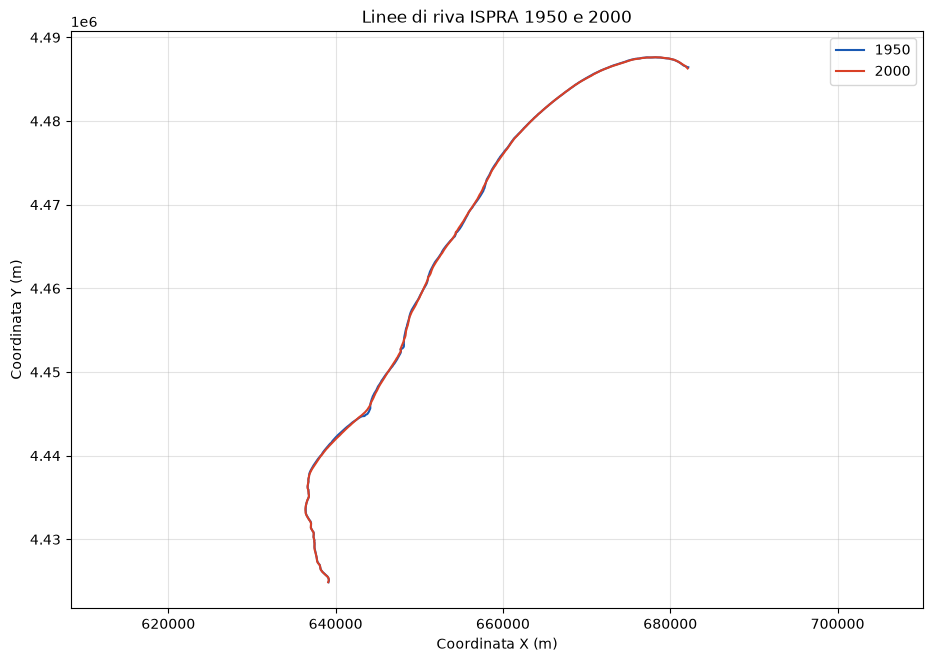

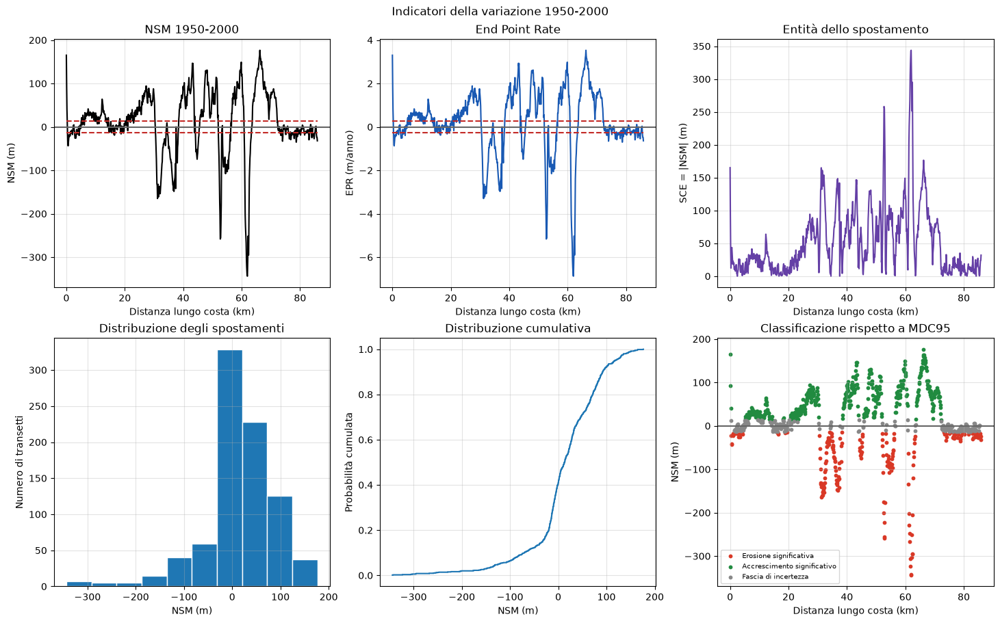

TRANS_17_intersect_1950_2000.xlsx: 850 transects; mean NSM=12.083 m; mean EPR=0.2417 m/year


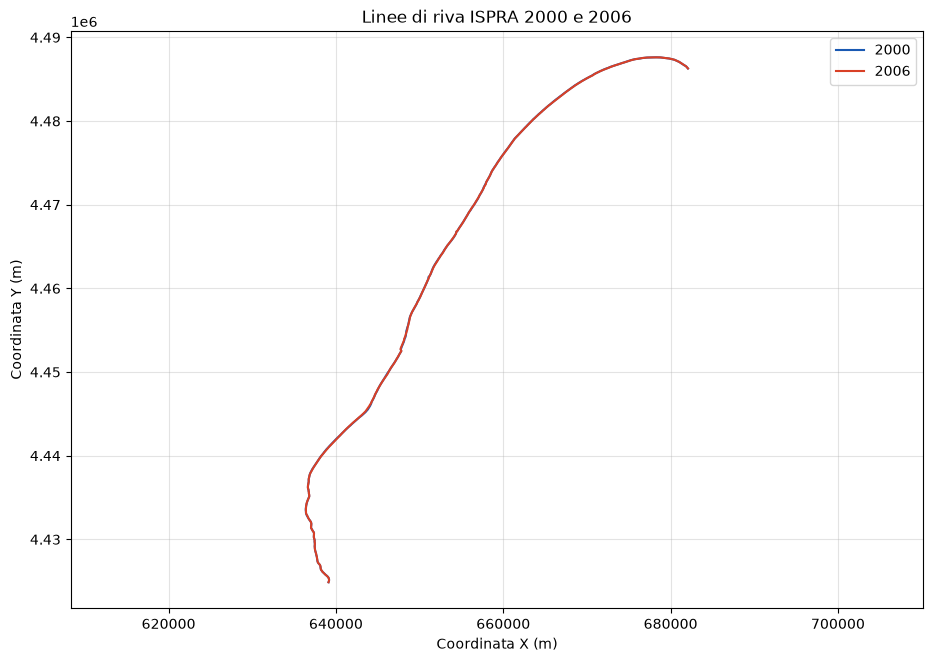

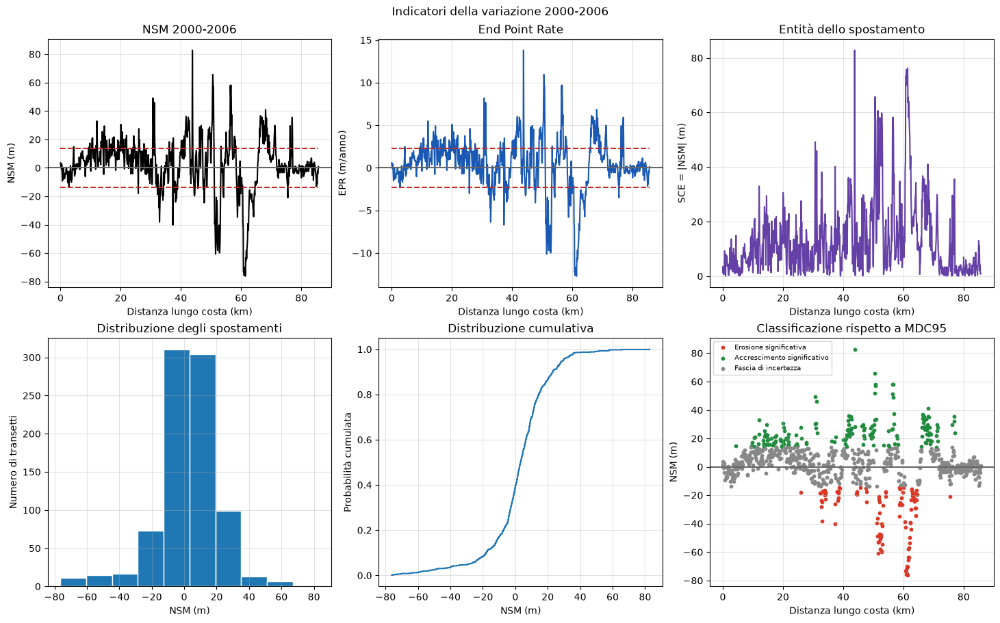

TRANS_17_intersect_2000_2006.xlsx: 850 transects; mean NSM=2.388 m; mean EPR=0.3980 m/year


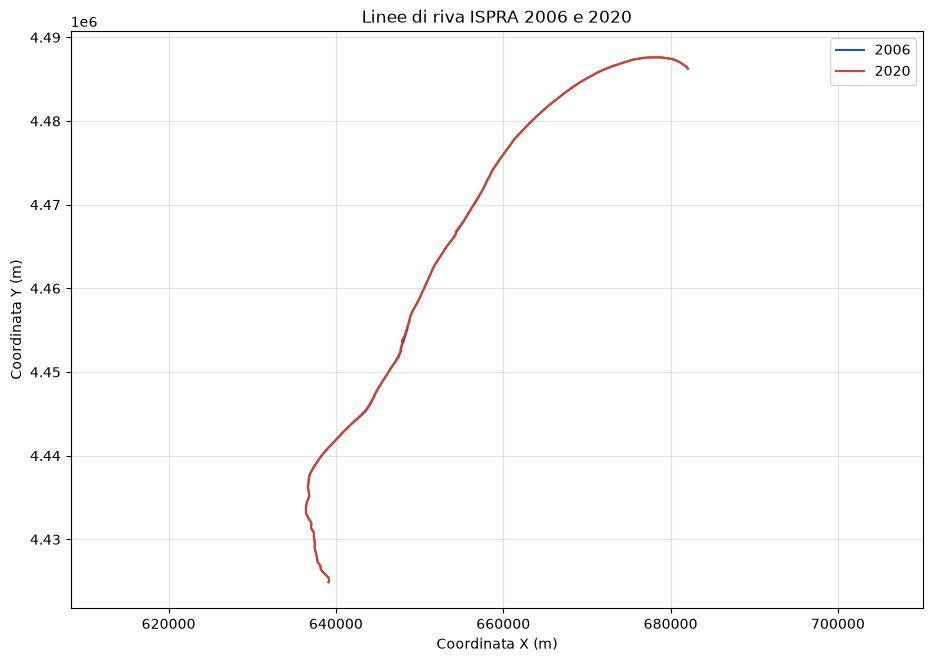

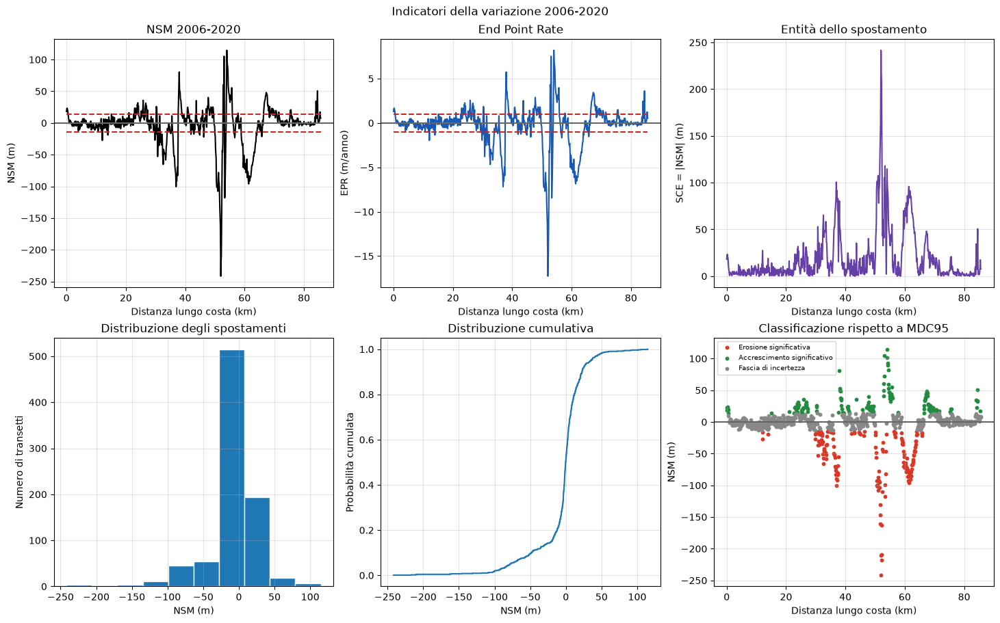

TRANS_17_intersect_2006_2020.xlsx: 850 transects; mean NSM=-5.360 m; mean EPR=-0.3829 m/year


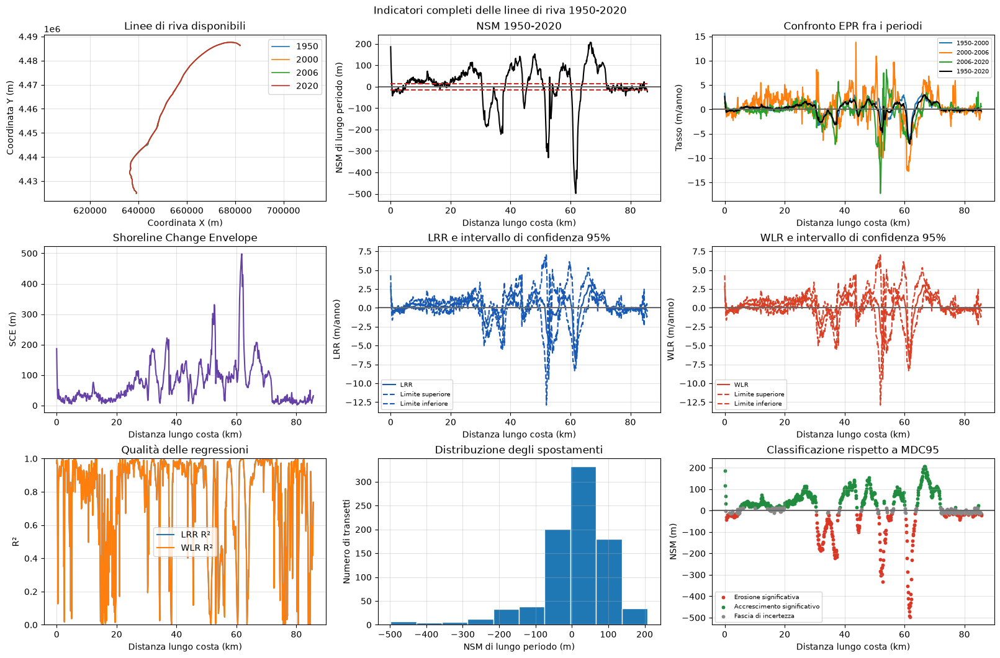

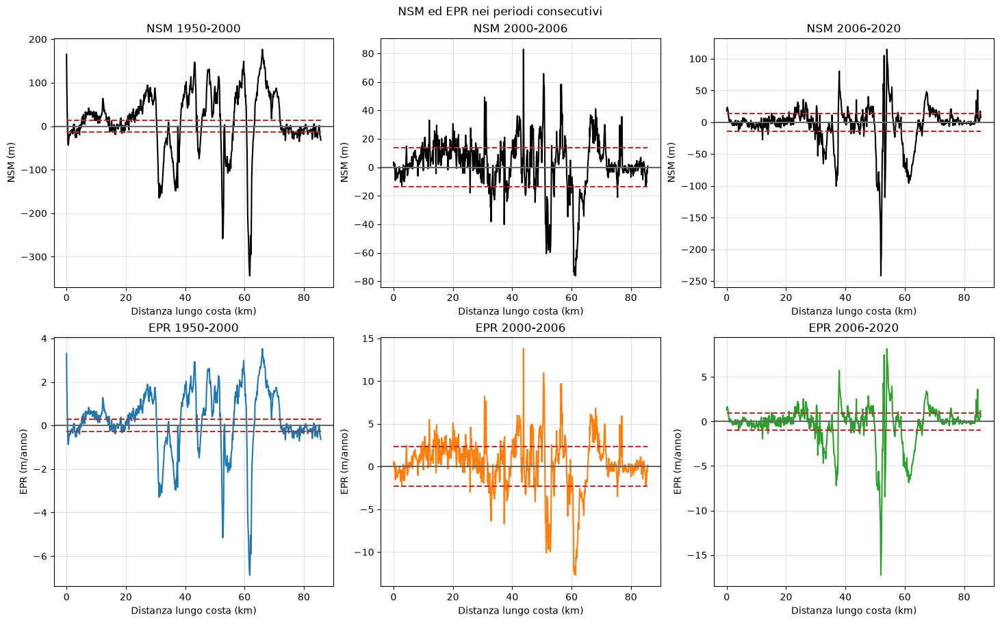

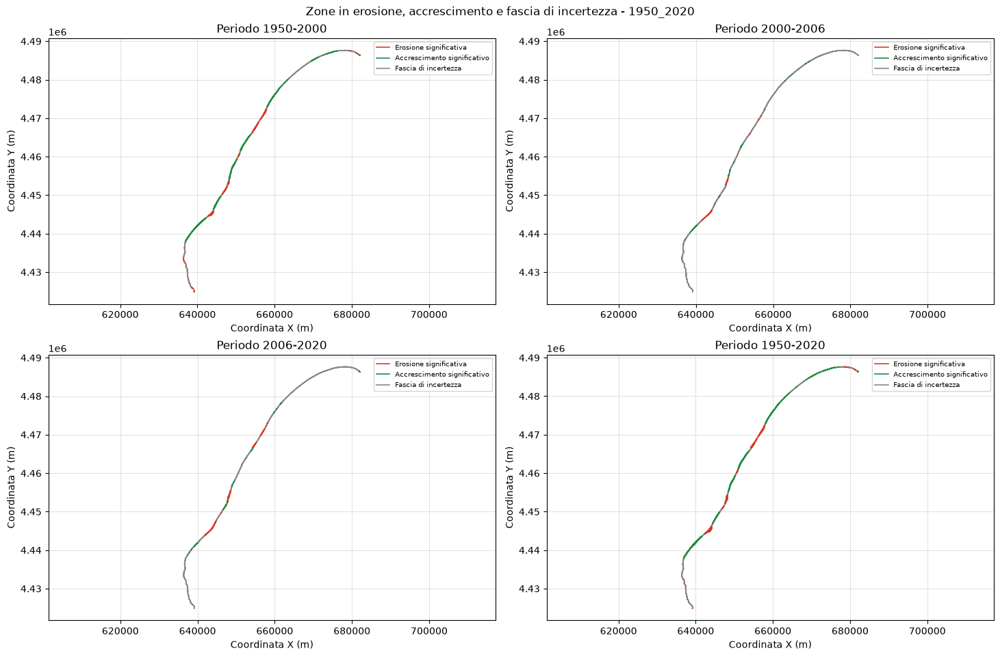

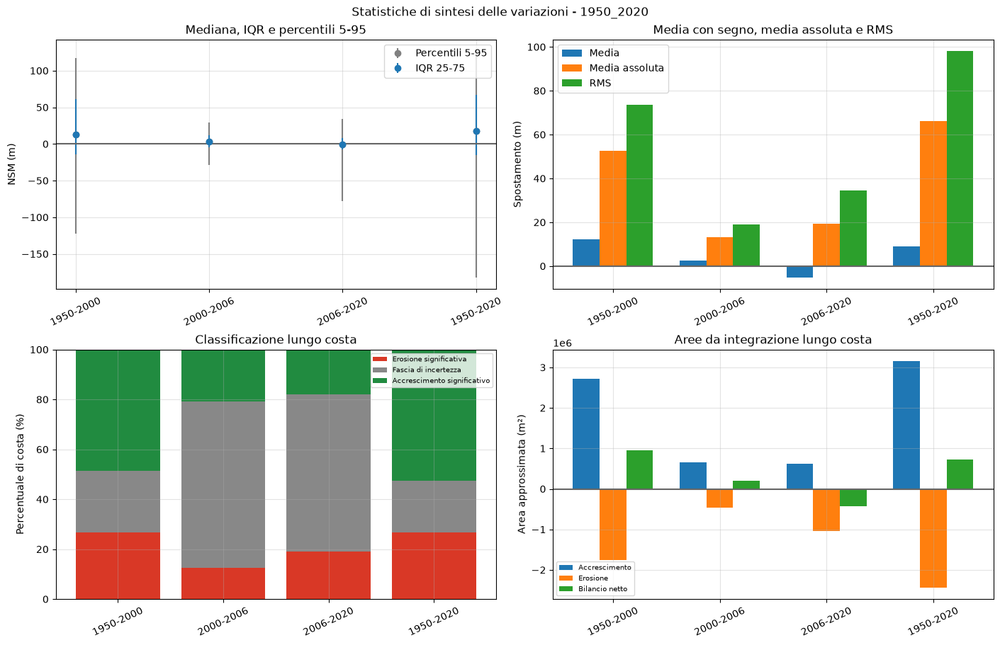

Combined analysis: years [1950, 2000, 2006, 2020], 850 common transects
Analysis completed. Results: C:\Users\faiza\Downloads\Risultati_linee_riva


In [2]:
"""Python conversion of analisi_linee_riva.m for Jupyter / Python 3.
Processes all TRANS_*_intersect_*.xls* files; creates Risultati_linee_riva/
with pair and combined Excel results and PNG figures.
"""

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t as student_t


# ============================================================
# CONFIGURATION
# ============================================================

INPUT_FOLDER = Path(r"C:\Users\faiza\Downloads")

FILE_PATTERN = 'TRANS_*_intersect_*.xls*'

SIGN_FACTOR = +1  # Verify baseline orientation before interpreting erosion/accretion

USE_EXACT_DATES = False

UNCERTAINTY_YEARS = [1950, 2000, 2006, 2020]

# Assumed positional uncertainty of +/- 5 m for each shoreline year,
# following the professor's suggestion (not an official ISPRA accuracy).

UNCERTAINTY_VALUES = [5.0, 5.0, 5.0, 5.0]

UNCERTAINTY_LEVEL = 'standard'   # 'standard' or '95'

COORDINATE_TOLERANCE_M = 0.05

SHOW_FIGURES = True

SAVE_FIGURES = True

ZERO_TOLERANCE_M = 1e-9

OUTPUT_FOLDER = INPUT_FOLDER / 'Risultati_linee_riva'

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']


# ============================================================
# UNCERTAINTY FUNCTIONS
# ============================================================

def lookup_uncertainty(years):

    mapping = dict(zip(UNCERTAINTY_YEARS, UNCERTAINTY_VALUES))

    return np.array(
        [mapping.get(int(y), np.nan) for y in np.atleast_1d(years)],
        float
    )


def combined_uncertainty95(u1, u2, delta_t):

    base = np.hypot(u1, u2)

    if UNCERTAINTY_LEVEL == 'standard':

        mdc = 1.96 * base

    elif UNCERTAINTY_LEVEL == '95':

        mdc = base

    else:

        raise ValueError("UNCERTAINTY_LEVEL must be 'standard' or '95'")

    return mdc, mdc / delta_t


# ============================================================
# DISTANCE AND STATISTICS
# ============================================================

def cumulative_distance(x, y):

    return np.r_[0., np.cumsum(np.hypot(np.diff(x), np.diff(y)))]


def representative_weights(s):

    if len(s) == 1:

        return np.array([np.nan])

    d = np.diff(s)

    weights = np.empty(len(s))

    weights[0], weights[-1] = d[0] / 2, d[-1] / 2

    if len(s) > 2:

        weights[1:-1] = (d[:-1] + d[1:]) / 2

    return weights


def summary_stats(values):

    x = np.asarray(values, float)

    x = x[np.isfinite(x)]

    names = [
        'Mean', 'Median', 'StandardDeviation',
        'Minimum', 'Maximum',
        'Percentile05', 'Percentile25',
        'Percentile75', 'Percentile95',
        'InterquartileRange',
        'MeanAbsoluteValue', 'RMS',
        'Skewness', 'ExcessKurtosis'
    ]

    if not len(x):

        return dict(zip(names, [np.nan] * len(names)))

    p = np.percentile(x, [5, 25, 75, 95], method='linear')

    mu = x.mean()

    sigma = np.sqrt(np.mean((x-x.mean())**2))

    skew = np.mean(((x-mu)/sigma)**3) if sigma else 0.

    kurt = np.mean(((x-mu)/sigma)**4)-3 if sigma else 0.

    results = [
        mu,
        np.median(x),
        np.std(x, ddof=1) if len(x)>1 else np.nan,
        x.min(),
        x.max(),
        *p,
        p[2]-p[1],
        np.mean(abs(x)),
        np.sqrt(np.mean(x*x)),
        skew,
        kurt
    ]

    return dict(zip(names, results))


def metric_row(values, indicator, period, unit):

    return {
        'Indicator': indicator,
        'Period': period,
        'Unit': unit,
        'NumberOfValues': int(np.isfinite(values).sum()),
        **summary_stats(values)
    }


# ============================================================
# CLASSIFICATION
# ============================================================

def classify(nsm, mdc):

    nsm, mdc = (
        np.asarray(nsm, float),
        np.broadcast_to(mdc, np.shape(nsm))
    )

    direct = np.full(nsm.shape, 'Nullo', dtype=object)

    direct[nsm > ZERO_TOLERANCE_M] = 'Accrescimento'

    direct[nsm < -ZERO_TOLERANCE_M] = 'Erosione'

    direct[~np.isfinite(nsm)] = 'Non disponibile'

    significance = np.full(
        nsm.shape,
        'Incertezza non disponibile',
        dtype=object
    )

    valid = np.isfinite(nsm) & np.isfinite(mdc)

    significance[valid] = "Non distinguibile dall'incertezza"

    significance[valid & (nsm > mdc)] = 'Accrescimento significativo'

    significance[valid & (nsm < -mdc)] = 'Erosione significativa'

    return direct, significance


def classification_summary(nsm, mdc, weights, period):

    total = len(nsm)

    valid = np.isfinite(nsm)

    x = np.asarray(nsm)[valid]

    u = np.asarray(mdc)[valid]

    w = np.asarray(weights)[valid]

    n = len(x)

    acc, ero, zero = x>0, x<0, x==0

    known = n > 0 and np.isfinite(u).all()

    sig_acc, sig_ero = x>u, x < -u

    uncertain = ~(sig_acc | sig_ero)

    good_w = n>0 and np.isfinite(w).all() and sum(w)>0

    r = dict(
        Period=period,
        NumberOfTransects=total,
        NumberOfValidValues=n,
        CountAccretion=sum(acc),
        CountErosion=sum(ero),
        CountZero=sum(zero),
        PctAccretion=100*sum(acc)/n if n else np.nan,
        PctErosion=100*sum(ero)/n if n else np.nan,
        PctZero=100*sum(zero)/n if n else np.nan
    )

    for name, mask in [
        ('Accretion', sig_acc),
        ('Erosion', sig_ero),
        ('Uncertain', uncertain)
    ]:

        r['Count'+('Significant' if name!='Uncertain' else '')+name] = (
            int(sum(mask)) if known else np.nan
        )

        r['Pct'+('Significant' if name!='Uncertain' else '')+name] = (
            100*sum(mask)/n if known else np.nan
        )

    for name, mask in [
        ('Accretion',acc),
        ('Erosion',ero),
        ('Zero',zero),
        ('SignificantAccretion',sig_acc),
        ('SignificantErosion',sig_ero),
        ('Uncertain',uncertain)
    ]:

        r['PctCoast'+name] = (
            100*w[mask].sum()/w.sum()
            if good_w and (
                known or
                'Significant' not in name and name!='Uncertain'
            )
            else np.nan
        )

    return r


def area_row(nsm, s, period):

    r = {'Period': period}

    for name, vals in [
        ('ApproxAccretionArea_m2', np.maximum(nsm,0)),
        ('ApproxErosionArea_m2', np.maximum(-nsm,0)),
        ('ApproxNetArea_m2', nsm)
    ]:

        r[name] = np.trapezoid(vals, s) if len(s)>1 else np.nan

    return r


# ============================================================
# PAIR SUMMARY
# ============================================================

def pair_summary(r, coast_weights, old_year, new_year):

    x = r.NSM_m.to_numpy()

    rate = r.EPR_m_per_year.to_numpy()

    q, qr = summary_stats(x), summary_stats(rate)

    known = r.MDC95_m.notna().all()

    n = len(r)

    u = r.MDC95_m.to_numpy()

    sa, se = (x>u).sum(), (x< -u).sum()

    w = coast_weights

    valid_w = n>1 and np.isfinite(w).all() and w.sum()>0

    ret = dict(
        OlderYear=old_year,
        RecentYear=new_year,

        Interval_years=np.median(r.DeltaT_years),

        NumberOfTransects=n,

        MeanNSM_m=q['Mean'],
        MedianNSM_m=q['Median'],
        StdNSM_m=q['StandardDeviation'],

        MinNSM_m=q['Minimum'],
        MaxNSM_m=q['Maximum'],

        P05_NSM_m=q['Percentile05'],
        P25_NSM_m=q['Percentile25'],
        P75_NSM_m=q['Percentile75'],
        P95_NSM_m=q['Percentile95'],

        IQR_NSM_m=q['InterquartileRange'],

        MeanAbsoluteNSM_m=q['MeanAbsoluteValue'],

        RMS_NSM_m=q['RMS'],

        Skewness_NSM=q['Skewness'],

        ExcessKurtosis_NSM=q['ExcessKurtosis'],

        MeanEPR_m_per_year=qr['Mean'],
        MedianEPR_m_per_year=qr['Median'],

        StdEPR_m_per_year=qr['StandardDeviation'],

        MinEPR_m_per_year=qr['Minimum'],
        MaxEPR_m_per_year=qr['Maximum'],

        P05_EPR_m_per_year=qr['Percentile05'],
        P25_EPR_m_per_year=qr['Percentile25'],

        P75_EPR_m_per_year=qr['Percentile75'],
        P95_EPR_m_per_year=qr['Percentile95'],

        IQR_EPR_m_per_year=qr['InterquartileRange'],

        MeanAbsoluteEPR_m_per_year=qr['MeanAbsoluteValue'],

        RMS_EPR_m_per_year=qr['RMS'],

        Skewness_EPR=qr['Skewness'],

        ExcessKurtosis_EPR=qr['ExcessKurtosis'],

        CountAccretion=int(sum(x>0)),
        CountErosion=int(sum(x<0)),

        CountZero=int(sum(x==0)),

        PctAccretion=100*sum(x>0)/n,
        PctErosion=100*sum(x<0)/n,

        PctZero=100*sum(x==0)/n,

        CountSignificantAccretion=int(sa) if known else np.nan,

        CountSignificantErosion=int(se) if known else np.nan,

        CountUncertainStable=int(n-sa-se) if known else np.nan,

        PctSignificantAccretion=100*sa/n if known else np.nan,

        PctSignificantErosion=100*se/n if known else np.nan,

        PctUncertainStable=100*(n-sa-se)/n if known else np.nan,

        ApproxCoastLength_m=r.Alongshore_m.max()-r.Alongshore_m.min()
    )

    for key, vals in [
        ('PctCoastAccretion', x>0),
        ('PctCoastErosion',x<0),
        ('PctCoastZero',x==0)
    ]:

        ret[key] = 100*w[vals].sum()/w.sum() if valid_w else np.nan

    ret.update({
        k:v for k,v in area_row(
            x,
            r.Alongshore_m.to_numpy(),
            'unused'
        ).items()
        if k!='Period'
    })

    return ret


# ============================================================
# FIGURE FUNCTIONS
# ============================================================

def save_fig(fig, name):

    if SAVE_FIGURES:

        fig.savefig(
            OUTPUT_FOLDER/name,
            dpi=300,
            bbox_inches='tight'
        )

    if SHOW_FIGURES:

        plt.show()

    else:

        plt.close(fig)


def setup(ax, xlabel=None, ylabel=None, title=None, equal=False):

    if xlabel:
        ax.set_xlabel(xlabel)

    if ylabel:
        ax.set_ylabel(ylabel)

    if title:
        ax.set_title(title)

    ax.grid(True, alpha=.35)

    if equal:
        ax.set_aspect('equal', adjustable='datalim')


def change_class_plot(ax, s, x, mdc):

    known=np.isfinite(mdc).all()

    threshold=mdc if known else np.zeros_like(x)

    masks=(
        x < -threshold,
        x>threshold,
        (x>=-threshold)&(x<=threshold)
    )

    labels=(
        [
            'Erosione significativa',
            'Accrescimento significativo',
            'Fascia di incertezza'
        ]
        if known
        else [
            'Erosione',
            'Accrescimento',
            'Nullo'
        ]
    )

    for mask,col,label in zip(
        masks,
        ['#d93826','#218b40','#888888'],
        labels
    ):

        ax.scatter(
            s[mask],
            x[mask],
            s=10,
            color=col,
            label=label
        )

    ax.axhline(0,color='0.4')

    ax.legend(fontsize=7)

    setup(
        ax,
        'Distanza lungo costa (km)',
        'NSM (m)',
        'Classificazione rispetto a MDC95'
        if known else 'Classificazione direzionale'
    )


# ============================================================
# PAIR FIGURES
# ============================================================

def pair_figures(r, y0, y1, tag):

    fig,ax=plt.subplots(figsize=(11,7.5))

    ax.plot(
        r.XOlder_m,
        r.YOlder_m,
        color='#1959b3',
        lw=1.5,
        label=str(y0)
    )

    ax.plot(
        r.XRecent_m,
        r.YRecent_m,
        color='#d94026',
        lw=1.5,
        label=str(y1)
    )

    setup(
        ax,
        'Coordinata X (m)',
        'Coordinata Y (m)',
        f'Linee di riva ISPRA {y0} e {y1}',
        True
    )

    ax.legend()

    save_fig(fig, f'linee_riva_{tag}.png')

    fig, axes=plt.subplots(
        2,3,
        figsize=(14.5,9),
        layout='constrained'
    )

    axs=axes.flat

    s=r.Alongshore_m.to_numpy()/1000

    x=r.NSM_m.to_numpy()

    rate=r.EPR_m_per_year.to_numpy()

    mdc=r.MDC95_m.to_numpy()

    rate_u=r.EPRunc95_m_per_year.to_numpy()

    for ax,v,unc,title,ylabel in [
        (axs[0],x,mdc,f'NSM {y0}-{y1}','NSM (m)'),
        (axs[1],rate,rate_u,'End Point Rate','EPR (m/anno)')
    ]:

        ax.plot(
            s,v,
            color='k' if ax==axs[0] else '#1959b3'
        )

        ax.axhline(0,color='.4')

        if np.isfinite(unc).all():

            ax.plot(s,unc,'--',color='#c32a26')

            ax.plot(s,-unc,'--',color='#c32a26')

        setup(
            ax,
            'Distanza lungo costa (km)',
            ylabel,
            title
        )

    axs[2].plot(s,r.SCE_m,color='#6540a6')

    setup(
        axs[2],
        'Distanza lungo costa (km)',
        'SCE = |NSM| (m)',
        'Entità dello spostamento'
    )

    axs[3].hist(x,edgecolor='white')

    setup(
        axs[3],
        'NSM (m)',
        'Numero di transetti',
        'Distribuzione degli spostamenti'
    )

    sx=np.sort(x[np.isfinite(x)])

    axs[4].step(
        sx,
        np.arange(1,len(sx)+1)/len(sx),
        where='post'
    )

    setup(
        axs[4],
        'NSM (m)',
        'Probabilità cumulata',
        'Distribuzione cumulativa'
    )

    change_class_plot(
        axs[5],
        s,
        x,
        mdc
    )

    fig.suptitle(
        f'Indicatori della variazione {y0}-{y1}'
    )

    save_fig(fig,f'indici_{tag}.png')


# ============================================================
# READ EXCEL FILES
# ============================================================

def read_pair(path):

    t=pd.read_excel(path)

    names={
        'TransectId':'TransectId',
        'ShorelineId':'Date',
        'Distance':'Distance_m',
        'IntersectX':'X_m',
        'IntersectY':'Y_m'
    }

    missing=set(names)-set(t.columns)

    if missing:

        raise ValueError(
            f'{path.name}: missing columns {missing}'
        )

    p=t[list(names)].rename(columns=names).copy()

    p['Date']=pd.to_datetime(
        p['Date'],
        dayfirst=True,
        errors='coerce'
    )

    for c in [
        'TransectId',
        'Distance_m',
        'X_m',
        'Y_m'
    ]:

        p[c]=pd.to_numeric(
            p[c],
            errors='coerce'
        )

    incomplete=p.isna().any(axis=1)

    if incomplete.any():

        warnings.warn(
            f'{incomplete.sum()} incomplete rows excluded from {path.name}'
        )

    p=p.loc[~incomplete].sort_values(
        ['TransectId','Date']
    ).reset_index(drop=True)

    counts=p.groupby('TransectId').size()

    if (counts!=2).any():

        raise ValueError(
            f'{path.name}: transect {counts[counts!=2].index[0]} does not contain exactly 2 points'
        )

    old=p.iloc[::2].reset_index(drop=True)

    new=p.iloc[1::2].reset_index(drop=True)

    if (old.Date==new.Date).any():

        raise ValueError(
            'Same date twice on a transect'
        )

    years0=old.Date.dt.year.unique()

    years1=new.Date.dt.year.unique()

    if len(years0)!=1 or len(years1)!=1:

        raise ValueError(
            'Dates not uniform across transects'
        )

    y0,y1=int(years0[0]),int(years1[0])

    ids=old.TransectId.to_numpy()

    dt=(
        (new.Date-old.Date).dt.total_seconds().to_numpy()/86400/365.2425
        if USE_EXACT_DATES
        else (new.Date.dt.year-old.Date.dt.year).to_numpy()
    )

    if np.any(dt<=0):

        raise ValueError(
            'Time interval must be positive'
        )

    d0=old.Distance_m.to_numpy()

    d1=new.Distance_m.to_numpy()

    x0=old.X_m.to_numpy()

    x1=new.X_m.to_numpy()

    z0=old.Y_m.to_numpy()

    z1=new.Y_m.to_numpy()

    delta=d1-d0

    nsm=SIGN_FACTOR*delta

    epr=nsm/dt

    sce=abs(delta)

    geometric=np.hypot(x1-x0,z1-z0)

    discrepancy=np.max(
        abs(geometric-abs(delta))
    )

    if discrepancy>0.01:

        warnings.warn(
            f'{path.name}: geometry vs baseline-distance discrepancy up to {discrepancy:.3f} m'
        )

    alongshore=cumulative_distance(
        (x0+x1)/2,
        (z0+z1)/2
    )

    mdc,unc=combined_uncertainty95(
        lookup_uncertainty([y0])[0],
        lookup_uncertainty([y1])[0],
        dt
    )

    direct,significance=classify(
        nsm,
        mdc
    )

    r=pd.DataFrame(
        dict(
            TransectId=ids,
            Alongshore_m=alongshore,
            DateOlder=old.Date,
            DateRecent=new.Date,
            XOlder_m=x0,
            YOlder_m=z0,
            XRecent_m=x1,
            YRecent_m=z1,
            DistanceOlder_m=d0,
            DistanceRecent_m=d1,
            DeltaT_years=dt,
            NSM_m=nsm,
            AbsNSM_m=abs(nsm),
            EPR_m_per_year=epr,
            SCE_m=sce,
            GeometricLength_m=geometric,
            MDC95_m=mdc,
            EPRunc95_m_per_year=unc,
            Direction=direct,
            SignificanceClass=significance
        )
    )

    obs=p.copy()

    obs['SourceFile']=str(path)

    return r,obs,y0,y1


# ============================================================
# WRITE EXCEL RESULTS
# ============================================================

def write_sheets(path, sheets):

    with pd.ExcelWriter(
        path,
        engine='openpyxl',
        datetime_format='yyyy-mm-dd'
    ) as writer:

        for name,frame in sheets.items():

            frame.to_excel(
                writer,
                sheet_name=name,
                index=False
            )


# ============================================================
# PAIR ANALYSIS
# ============================================================

def analyze_pair(path):

    r,obs,y0,y1=read_pair(path)

    tag=f'{y0:04d}_{y1:04d}'

    period=f'{y0}-{y1}'

    weights=representative_weights(
        r.Alongshore_m.to_numpy()
    )

    summary=pd.DataFrame([
        pair_summary(r,weights,y0,y1)
    ])

    stats=pd.DataFrame([
        metric_row(r.NSM_m,'NSM',period,'m'),
        metric_row(r.EPR_m_per_year,'EPR',period,'m/anno'),
        metric_row(r.SCE_m,'SCE',period,'m')
    ])

    classes=pd.DataFrame([
        classification_summary(
            r.NSM_m.to_numpy(),
            r.MDC95_m.to_numpy(),
            weights,
            period
        )
    ])

    areas=pd.DataFrame([
        area_row(
            r.NSM_m.to_numpy(),
            r.Alongshore_m.to_numpy(),
            period
        )
    ])

    write_sheets(
        OUTPUT_FOLDER/f'risultati_{tag}.xlsx',
        dict(
            Summary=summary,
            Transects=r,
            Statistics=stats,
            ClassSummary=classes,
            AreaSummary=areas
        )
    )

    pair_figures(r,y0,y1,tag)

    print(
        f'{path.name}: {len(r)} transects; '
        f'mean NSM={r.NSM_m.mean():.3f} m; '
        f'mean EPR={r.EPR_m_per_year.mean():.4f} m/year'
    )

    return obs


# ============================================================
# LINEAR REGRESSION
# ============================================================

def rates(t, D, sigma=None):

    t=np.asarray(t,float)

    D=np.asarray(D,float)

    if sigma is None:

        w=np.ones(len(t))

    else:

        w=1/np.asarray(sigma,float)**2

    mt=np.dot(w,t)/w.sum()

    xx=t-mt

    den=np.dot(w,xx**2)

    mu=D@w/w.sum()

    slope=D@(w*xx)/den

    residual=D-(mu[:,None]+slope[:,None]*xx[None,:])

    sse=(residual**2)@w

    sst=((D-mu[:,None])**2)@w

    df=len(t)-2

    se=(
        np.sqrt(np.maximum((sse/df)/den,0))
        if df>0
        else np.full(len(D),np.nan)
    )

    ci=(
        student_t.ppf(.975,df)*se
        if df>0
        else se.copy()
    )

    r2=np.divide(
        sse,
        sst,
        out=np.full(len(D),np.nan),
        where=sst>0
    )

    r2=np.where(
        sst>0,
        1-r2,
        np.nan
    )

    return slope,se,ci,r2


# ============================================================
# EROSION / ACCRETION MAP PANELS
# ============================================================

def map_panel(ax,x0,y0,x1,y1,nsm,mdc,label):

    ax.plot(x0,y0,color='.55',lw=.8)

    ax.plot(x1,y1,color='.1',lw=.8)

    known=np.isfinite(mdc).all()

    threshold=mdc if known else np.zeros_like(nsm)

    selection=[
        nsm < -threshold,
        nsm > threshold,
        abs(nsm)<=threshold
    ]

    labels=(
        [
            'Erosione significativa',
            'Accrescimento significativo',
            'Fascia di incertezza'
        ]
        if known
        else [
            'Erosione',
            'Accrescimento',
            'Nullo'
        ]
    )

    for mask,col,name in zip(
        selection,
        ['#d93826','#218b40','#888888'],
        labels
    ):

        sx=np.stack(
            [
                x0[mask],
                x1[mask],
                np.full(mask.sum(),np.nan)
            ],
            axis=1
        ).ravel()

        sy=np.stack(
            [
                y0[mask],
                y1[mask],
                np.full(mask.sum(),np.nan)
            ],
            axis=1
        ).ravel()

        ax.plot(
            sx,
            sy,
            color=col,
            lw=1.2,
            label=name
        )

    setup(
        ax,
        'Coordinata X (m)',
        'Coordinata Y (m)',
        f'Periodo {label}',
        True
    )

    ax.legend(fontsize=7)


# ============================================================
# COMBINED FIGURES
# ============================================================

def combined_figures(
    r,X,Y,years,nsm_int,epr_int,
    mdc_int,tag,stats,classes,areas
):

    ny=len(years)

    s=r.Alongshore_m.to_numpy()/1000

    fig,ax=plt.subplots(
        3,3,
        figsize=(16,10.5),
        layout='constrained'
    )

    a=ax.flat

    for j,yr in enumerate(years):

        a[0].plot(
            X[:,j],
            Y[:,j],
            lw=1.2,
            label=str(yr),
            color=COLORS[j%len(COLORS)]
        )

    setup(
        a[0],
        'Coordinata X (m)',
        'Coordinata Y (m)',
        'Linee di riva disponibili',
        True
    )

    a[0].legend()

    a[1].plot(
        s,
        r.NSM_long_m,
        color='k'
    )

    a[1].axhline(0,color='.4')

    if r.MDC95_long_m.notna().all():

        a[1].plot(
            s,
            r.MDC95_long_m,
            '--',
            color='#c32a26'
        )

        a[1].plot(
            s,
            -r.MDC95_long_m,
            '--',
            color='#c32a26'
        )

    setup(
        a[1],
        'Distanza lungo costa (km)',
        'NSM di lungo periodo (m)',
        f'NSM {years[0]}-{years[-1]}'
    )

    for j in range(ny-1):

        a[2].plot(
            s,
            epr_int[:,j],
            label=f'{years[j]}-{years[j+1]}'
        )

    a[2].plot(
        s,
        r.EPR_long_m_per_year,
        color='k',
        label=f'{years[0]}-{years[-1]}'
    )

    a[2].axhline(0,color='.4')

    a[2].legend(fontsize=7)

    setup(
        a[2],
        'Distanza lungo costa (km)',
        'Tasso (m/anno)',
        'Confronto EPR fra i periodi'
    )

    a[3].plot(
        s,
        r.SCE_m,
        color='#6540a6'
    )

    setup(
        a[3],
        'Distanza lungo costa (km)',
        'SCE (m)',
        'Shoreline Change Envelope'
    )

    for idx,name,col in [
        (4,'LRR','#1959b3'),
        (5,'WLR','#d94026')
    ]:

        val=r[f'{name}_m_per_year'].to_numpy()

        ci=r[f'{name}_CI95_m_per_year'].to_numpy()

        if np.isfinite(val).any():

            a[idx].plot(
                s,
                val,
                color=col,
                label=name
            )

            a[idx].plot(
                s,
                val+ci,
                '--',
                color=col,
                label='Limite superiore'
            )

            a[idx].plot(
                s,
                val-ci,
                '--',
                color=col,
                label='Limite inferiore'
            )

            a[idx].legend(fontsize=7)

        else:

            a[idx].text(
                .5,.5,
                'WLR non disponibile: inserire le incertezze',
                ha='center',
                transform=a[idx].transAxes
            )

        a[idx].axhline(0,color='.4')

        setup(
            a[idx],
            'Distanza lungo costa (km)',
            f'{name} (m/anno)',
            f'{name} e intervallo di confidenza 95%'
        )

    a[6].plot(
        s,
        r.LRR_R2,
        label='LRR R²'
    )

    if np.isfinite(r.WLR_R2).any():

        a[6].plot(
            s,
            r.WLR_R2,
            label='WLR R²'
        )

    a[6].set_ylim(0,1)

    a[6].legend()

    setup(
        a[6],
        'Distanza lungo costa (km)',
        'R²',
        'Qualità delle regressioni'
    )

    a[7].hist(
        r.NSM_long_m,
        edgecolor='white'
    )

    setup(
        a[7],
        'NSM di lungo periodo (m)',
        'Numero di transetti',
        'Distribuzione degli spostamenti'
    )

    change_class_plot(
        a[8],
        s,
        r.NSM_long_m.to_numpy(),
        r.MDC95_long_m.to_numpy()
    )

    fig.suptitle(
        f'Indicatori completi delle linee di riva {years[0]}-{years[-1]}'
    )

    save_fig(
        fig,
        f'serie_completa_{tag}.png'
    )

    fig,ax=plt.subplots(
        2,ny-1,
        figsize=(14.5,9),
        layout='constrained'
    )

    ax=np.asarray(ax).reshape(2,ny-1)

    for j in range(ny-1):

        for row,values,unc,ylabel,name in [
            (
                0,
                nsm_int[:,j],
                mdc_int[:,j],
                'NSM (m)',
                'NSM'
            ),
            (
                1,
                epr_int[:,j],
                mdc_int[:,j]/(years[j+1]-years[j]),
                'EPR (m/anno)',
                'EPR'
            )
        ]:

            q=ax[row,j]

            q.plot(
                s,
                values,
                color='k' if row==0 else COLORS[j]
            )

            q.axhline(0,color='.4')

            if np.isfinite(unc).all():

                q.plot(
                    s,
                    unc,
                    '--',
                    color='#c32a26'
                )

                q.plot(
                    s,
                    -unc,
                    '--',
                    color='#c32a26'
                )

            setup(
                q,
                'Distanza lungo costa (km)',
                ylabel,
                f'{name} {years[j]}-{years[j+1]}'
            )

    fig.suptitle(
        'NSM ed EPR nei periodi consecutivi'
    )

    save_fig(
        fig,
        f'confronto_periodi_{tag}.png'
    )

    fig,ax=plt.subplots(
        2,2,
        figsize=(14.5,9.5),
        layout='constrained'
    )

    panels=[
        (
            j,j+1,
            nsm_int[:,j],
            mdc_int[:,j],
            f'{years[j]}-{years[j+1]}'
        )
        for j in range(ny-1)
    ]

    panels.append(
        (
            0,-1,
            r.NSM_long_m.to_numpy(),
            r.MDC95_long_m.to_numpy(),
            f'{years[0]}-{years[-1]}'
        )
    )

    for q,(j,k,vals,unc,label) in zip(
        ax.flat,
        panels
    ):

        map_panel(
            q,
            X[:,j],
            Y[:,j],
            X[:,k],
            Y[:,k],
            vals,
            unc,
            label
        )

    fig.suptitle(
        f'Zone in erosione, accrescimento e fascia di incertezza - {tag}'
    )

    save_fig(
        fig,
        f'zone_erosione_accrescimento_{tag}.png'
    )

    nsm_stats=stats[
        stats.Indicator=='NSM'
    ]

    periods=nsm_stats.Period.tolist()

    pos=np.arange(len(periods))

    fig,ax=plt.subplots(
        2,2,
        figsize=(14,9),
        layout='constrained'
    )

    med=nsm_stats.Median.to_numpy()

    ax[0,0].errorbar(
        pos,
        med,
        yerr=[
            med-nsm_stats.Percentile05.to_numpy(),
            nsm_stats.Percentile95.to_numpy()-med
        ],
        fmt='o',
        label='Percentili 5-95',
        color='.5'
    )

    ax[0,0].errorbar(
        pos,
        med,
        yerr=[
            med-nsm_stats.Percentile25.to_numpy(),
            nsm_stats.Percentile75.to_numpy()-med
        ],
        fmt='o',
        label='IQR 25-75'
    )

    ax[0,0].legend()

    setup(
        ax[0,0],
        ylabel='NSM (m)',
        title='Mediana, IQR e percentili 5-95'
    )

    for j,key in enumerate([
        'Mean',
        'MeanAbsoluteValue',
        'RMS'
    ]):

        ax[0,1].bar(
            pos+(j-1)*.25,
            nsm_stats[key],
            width=.25,
            label=[
                'Media',
                'Media assoluta',
                'RMS'
            ][j]
        )

    ax[0,1].legend()

    setup(
        ax[0,1],
        ylabel='Spostamento (m)',
        title='Media con segno, media assoluta e RMS'
    )

    changes=classes[
        ~classes.Period.str.startswith(('LRR','WLR'))
    ].reset_index(drop=True)

    known=np.isfinite(
        changes.PctCoastSignificantAccretion
    ).all()

    fields=(
        [
            'PctCoastSignificantErosion',
            'PctCoastUncertain',
            'PctCoastSignificantAccretion'
        ]
        if known
        else [
            'PctCoastErosion',
            'PctCoastZero',
            'PctCoastAccretion'
        ]
    )

    labels=(
        [
            'Erosione significativa',
            'Fascia di incertezza',
            'Accrescimento significativo'
        ]
        if known
        else [
            'Erosione',
            'Nullo',
            'Accrescimento'
        ]
    )

    bottom=np.zeros(len(changes))

    for field,label,col in zip(
        fields,
        labels,
        ['#d93826','#888888','#218b40']
    ):

        vals=changes[field].fillna(0).to_numpy()

        ax[1,0].bar(
            np.arange(len(changes)),
            vals,
            bottom=bottom,
            label=label,
            color=col
        )

        bottom+=vals

    ax[1,0].set_ylim(0,100)

    ax[1,0].legend(fontsize=7)

    ax[1,0].set_xticks(
        np.arange(len(changes)),
        changes.Period,
        rotation=25
    )

    setup(
        ax[1,0],
        ylabel='Percentuale di costa (%)',
        title='Classificazione lungo costa'
    )

    for j,(key,label) in enumerate([
        ('ApproxAccretionArea_m2','Accrescimento'),
        ('ApproxErosionArea_m2','Erosione'),
        ('ApproxNetArea_m2','Bilancio netto')
    ]):

        vals=areas[key].to_numpy() * (
            -1 if j==1 else 1
        )

        ax[1,1].bar(
            np.arange(len(areas))+(j-1)*.25,
            vals,
            width=.25,
            label=label
        )

    ax[1,1].set_xticks(
        np.arange(len(areas)),
        areas.Period,
        rotation=25
    )

    ax[1,1].legend(fontsize=7)

    setup(
        ax[1,1],
        ylabel='Area approssimata (m²)',
        title='Aree da integrazione lungo costa'
    )

    for q in [ax[0,0],ax[0,1]]:

        q.set_xticks(
            pos,
            periods,
            rotation=25
        )

        q.axhline(0,color='.4')

    ax[1,1].axhline(0,color='.4')

    fig.suptitle(
        f'Statistiche di sintesi delle variazioni - {tag}'
    )

    save_fig(
        fig,
        f'statistiche_sintesi_{tag}.png'
    )


# ============================================================
# COMBINED FOUR-YEAR ANALYSIS
# ============================================================

def analyze_combined(obs):

    m=pd.concat(
        obs,
        ignore_index=True
    )

    m['Year']=m.Date.dt.year

    years=np.sort(m.Year.unique())

    ny=len(years)

    if ny<3:
        return

    keys=[
        'TransectId',
        'Year'
    ]

    group=m.groupby(
        keys,
        sort=True
    )

    a=group[
        ['Distance_m','X_m','Y_m']
    ].mean()

    spread=group.apply(
        lambda q: pd.Series({
            'CoordinateSpread_m':np.hypot(
                q.X_m-q.X_m.mean(),
                q.Y_m-q.Y_m.mean()
            ).max(),

            'DistanceSpread_m':abs(
                q.Distance_m-q.Distance_m.mean()
            ).max()
        }),
        include_groups=False
    )

    a=a.join(spread).reset_index()

    complete=a.groupby(
        'TransectId'
    ).Year.nunique()

    ids=np.sort(
        complete[complete==ny].index.to_numpy()
    )

    if len(ids)==0:

        raise ValueError(
            'No transect appears in all four epochs'
        )

    a=a[
        a.TransectId.isin(ids)
    ].sort_values(keys).reset_index(drop=True)

    discrepancy=a[
        (a.CoordinateSpread_m>COORDINATE_TOLERANCE_M) |
        (a.DistanceSpread_m>COORDINATE_TOLERANCE_M)
    ]

    if len(discrepancy):

        first=discrepancy.iloc[0]

        raise ValueError(
            f"Year {first.Year}, transect {first.TransectId}: "
            "repeated shoreline coordinates differ; common transect network needed"
        )

    if len(complete)!=len(ids):

        warnings.warn(
            f'{len(complete)-len(ids)} non-common transects excluded'
        )

    D=a.Distance_m.to_numpy().reshape(-1,ny)

    X=a.X_m.to_numpy().reshape(-1,ny)

    Y=a.Y_m.to_numpy().reshape(-1,ny)

    intervals=np.diff(years)

    nsm_int=SIGN_FACTOR*np.diff(D,axis=1)

    epr_int=nsm_int/intervals

    nsm_long=SIGN_FACTOR*(D[:,-1]-D[:,0])

    span=years[-1]-years[0]

    sce=D.max(axis=1)-D.min(axis=1)

    lrr,lrr_se,lrr_ci,lrr_r2=rates(
        years,D
    )

    lrr*=SIGN_FACTOR

    u=lookup_uncertainty(years)

    u_std=(
        u/1.96
        if UNCERTAINTY_LEVEL=='95'
        else u
    )

    if np.isfinite(u_std).all() and (u_std>0).all():

        wlr,wlr_se,wlr_ci,wlr_r2=rates(
            years,D,u_std
        )

        wlr*=SIGN_FACTOR

    else:

        wlr=wlr_se=wlr_ci=wlr_r2=np.full(
            len(ids),
            np.nan
        )

    s=cumulative_distance(
        X.mean(axis=1),
        Y.mean(axis=1)
    )

    weights=representative_weights(s)

    mdc_int=np.column_stack([
        combined_uncertainty95(
            u[j],
            u[j+1],
            intervals[j]
        )[0]*np.ones(len(ids))
        for j in range(ny-1)
    ])

    epr_u_int=mdc_int/intervals

    mdc_long,epr_u_long=combined_uncertainty95(
        u[0],
        u[-1],
        span
    )

    mdc_long=np.full(
        len(ids),
        mdc_long
    )

    epr_u_long=np.full(
        len(ids),
        epr_u_long
    )

    r=pd.DataFrame(
        dict(
            TransectId=ids,
            Alongshore_m=s
        )
    )

    for j,yr in enumerate(years):

        r[f'Distance_{yr}_m']=D[:,j]

    stats=[]
    classes=[]
    areas=[]

    for j in range(ny-1):

        p=f'{years[j]}-{years[j+1]}'

        suffix=f'{years[j]}_{years[j+1]}'

        r[f'NSM_{suffix}_m']=nsm_int[:,j]

        r[f'EPR_{suffix}_m_per_year']=epr_int[:,j]

        r[f'MDC95_{suffix}_m']=mdc_int[:,j]

        r[f'EPRunc95_{suffix}_m_per_year']=epr_u_int[:,j]

        r[f'Direction_{suffix}'],r[f'Class_{suffix}']=classify(
            nsm_int[:,j],
            mdc_int[:,j]
        )

        stats.extend([
            metric_row(nsm_int[:,j],'NSM',p,'m'),
            metric_row(epr_int[:,j],'EPR',p,'m/anno')
        ])

        classes.append(
            classification_summary(
                nsm_int[:,j],
                mdc_int[:,j],
                weights,
                p
            )
        )

        areas.append(
            area_row(
                nsm_int[:,j],
                s,
                p
            )
        )

    r['NSM_long_m']=nsm_long

    r['EPR_long_m_per_year']=nsm_long/span

    r['SCE_m']=sce

    for stem,val,ci,se,r2 in [
        ('LRR',lrr,lrr_ci,lrr_se,lrr_r2),
        ('WLR',wlr,wlr_ci,wlr_se,wlr_r2)
    ]:

        r[f'{stem}_m_per_year']=val

        r[f'{stem}_CI95_m_per_year']=ci

        r[f'{stem}_SE_m_per_year']=se

        r[f'{stem}_R2']=r2

        r[f'{stem}_Direction'],r[f'{stem}_SignificanceClass']=classify(
            val,ci
        )

    r['MDC95_long_m']=mdc_long

    r['EPRunc95_long_m_per_year']=epr_u_long

    r['Direction'],r['SignificanceClass']=classify(
        nsm_long,
        mdc_long
    )

    suffix=f'{years[0]}_{years[-1]}'

    for stem,v in [
        ('NSM',nsm_long),
        ('EPR',nsm_long/span),
        ('MDC95',mdc_long),
        ('EPRunc95',epr_u_long)
    ]:

        r[
            f'{stem}_{suffix}_' +
            ('m_per_year' if stem in ('EPR','EPRunc95') else 'm')
        ]=v

    r[f'Direction_{suffix}']=r.Direction

    r[f'Class_{suffix}']=r.SignificanceClass

    tmp=pd.DataFrame(
        dict(
            Alongshore_m=s,
            DeltaT_years=span,
            NSM_m=nsm_long,
            EPR_m_per_year=nsm_long/span,
            MDC95_m=mdc_long
        )
    )

    summary=pair_summary(
        tmp,
        weights,
        int(years[0]),
        int(years[-1])
    )

    summary.update(
        MeanSCE_m=np.mean(sce),

        MedianSCE_m=np.median(sce),

        MeanLRR_m_per_year=np.mean(lrr),

        MedianLRR_m_per_year=np.median(lrr),

        MeanLRR_R2=np.nanmean(lrr_r2),

        MeanWLR_m_per_year=(
            np.nan
            if not np.isfinite(wlr).any()
            else np.nanmean(wlr)
        ),

        MedianWLR_m_per_year=(
            np.nan
            if not np.isfinite(wlr).any()
            else np.nanmedian(wlr)
        ),

        MeanWLR_R2=(
            np.nan
            if not np.isfinite(wlr_r2).any()
            else np.nanmean(wlr_r2)
        ),

        NumberOfEpochs=ny
    )

    label=f'{years[0]}-{years[-1]}'

    stats += [
        metric_row(nsm_long,'NSM',label,'m'),

        metric_row(nsm_long/span,'EPR',label,'m/anno'),

        metric_row(sce,'SCE','Serie completa','m'),

        metric_row(lrr,'LRR','Serie completa','m/anno'),

        metric_row(wlr,'WLR','Serie completa','m/anno')
    ]

    classes += [
        classification_summary(
            nsm_long,
            mdc_long,
            weights,
            label
        ),

        classification_summary(
            lrr,
            lrr_ci,
            weights,
            'LRR serie completa'
        ),

        classification_summary(
            wlr,
            wlr_ci,
            weights,
            'WLR serie completa'
        )
    ]

    areas.append(
        area_row(
            nsm_long,
            s,
            label
        )
    )

    stats,classes,areas=map(
        pd.DataFrame,
        [stats,classes,areas]
    )

    position=pd.DataFrame({
        'TransectId':ids
    })

    for j,yr in enumerate(years):

        position[f'X_{yr}_m']=X[:,j]

    for j,yr in enumerate(years):

        position[f'Y_{yr}_m']=Y[:,j]

    tag=f'{years[0]:04d}_{years[-1]:04d}'

    write_sheets(
        OUTPUT_FOLDER/f'risultati_serie_completa_{tag}.xlsx',
        dict(
            Summary=pd.DataFrame([summary]),
            Transects=r,
            Statistics=stats,
            ClassSummary=classes,
            AreaSummary=areas,
            Coordinates=position
        )
    )

    combined_figures(
        r,
        X,
        Y,
        years,
        nsm_int,
        epr_int,
        mdc_int,
        tag,
        stats,
        classes,
        areas
    )

    print(
        f'Combined analysis: years {years.tolist()}, '
        f'{len(ids)} common transects'
    )

    if not np.isfinite(u_std).all():

        print(
            'WLR unavailable: enter documented uncertainties in UNCERTAINTY_VALUES'
        )


# ============================================================
# MAIN FUNCTION
# ============================================================

def main():

    OUTPUT_FOLDER.mkdir(
        parents=True,
        exist_ok=True
    )

    paths=sorted(
        p for p in INPUT_FOLDER.glob(FILE_PATTERN)
        if p.is_file()
    )

    if not paths:

        raise FileNotFoundError(
            f'No {FILE_PATTERN} files in {INPUT_FOLDER}; '
            'set INPUT_FOLDER to the folder containing the Excel files'
        )

    print(
        f'Found {len(paths)} files; '
        f'SIGN_FACTOR={SIGN_FACTOR:+d}; '
        'verify baseline orientation'
    )

    observations=[
        analyze_pair(p)
        for p in paths
    ]

    if len(
        pd.concat(observations).Date.dt.year.unique()
    )>=3:

        try:

            analyze_combined(observations)

        except Exception as error:

            warnings.warn(
                f'Pair analyses completed but combined analysis failed: {error}'
            )

    print(
        f'Analysis completed. Results: {OUTPUT_FOLDER}'
    )


# ============================================================
# RUN COMPLETE ANALYSIS
# ============================================================

main()

In [4]:
import sys
import importlib.metadata as metadata

print("Python:", sys.version)
print("Environment:", sys.executable)

for package in ["rasterio", "GDAL", "numpy"]:
    try:
        print(package, ":", metadata.version(package))
    except metadata.PackageNotFoundError:
        print(package, ": not installed")

Python: 3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:37:13) [MSC v.1942 64 bit (AMD64)]
Environment: c:\Users\faiza\anaconda3\envs\metaponto_hawk\python.exe
rasterio : 1.5.1
GDAL : not installed
numpy : 2.5.3


In [5]:
from pathlib import Path
import sys
import importlib.metadata as metadata

rasterio_info = metadata.distribution("rasterio")

print("Rasterio version:", rasterio_info.version)

print(
    "Installer:",
    (rasterio_info.read_text("INSTALLER") or "Unknown").strip()
)

conda_records = list(
    (Path(sys.prefix) / "conda-meta").glob("rasterio-*.json")
)

print("\nConda installation records:")

if conda_records:
    for record in conda_records:
        print(record.name)
else:
    print("No Rasterio conda installation record found.")

Rasterio version: 1.5.1
Installer: pip

Conda installation records:
No Rasterio conda installation record found.


In [6]:
from pathlib import Path

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

print("HAWK folder exists:", HAWK_DIR.exists())
print("Folder:", HAWK_DIR)

if not HAWK_DIR.exists():
    raise FileNotFoundError("HAWK folder not found.")

tif_files = sorted(HAWK_DIR.rglob("*.tif"))
xml_files = sorted(HAWK_DIR.rglob("*.xml"))

print("\n" + "=" * 60)
print("HAWK BANDS")
print("=" * 60)

for file in tif_files:
    print(f"{file.name}  |  {file.stat().st_size / 1e6:.1f} MB")

print("\n" + "=" * 60)
print("HAWK XML METADATA")
print("=" * 60)

for file in xml_files:
    print(file.name)

print("\nTOTAL TIFF FILES:", len(tif_files))
print("TOTAL XML FILES:", len(xml_files))

print("\nIMPORTANT RF BANDS:")

for band in ["B01", "B02", "B03", "B07"]:
    matches = [
        file for file in tif_files
        if file.stem.upper().endswith("." + band)
    ]
    print(f"{band}: {len(matches)} file(s)")

HAWK folder exists: True
Folder: C:\Users\faiza\Downloads\HAWK DATASET 27.7.26 METAPONTO

HAWK BANDS
IMH04_1CST__OPT8_20260727T122414_20260727T122416_20260727T171811_05949______O_A02.B00.tif  |  36.4 MB
IMH04_1CST__OPT8_20260727T122414_20260727T122416_20260727T171811_05949______O_A02.B01.tif  |  31.7 MB
IMH04_1CST__OPT8_20260727T122414_20260727T122416_20260727T171811_05949______O_A02.B02.tif  |  33.6 MB
IMH04_1CST__OPT8_20260727T122414_20260727T122416_20260727T171811_05949______O_A02.B03.tif  |  34.9 MB
IMH04_1CST__OPT8_20260727T122414_20260727T122416_20260727T171811_05949______O_A02.B04.tif  |  9.2 MB
IMH04_1CST__OPT8_20260727T122414_20260727T122416_20260727T171811_05949______O_A02.B05.tif  |  9.3 MB
IMH04_1CST__OPT8_20260727T122414_20260727T122416_20260727T171811_05949______O_A02.B06.tif  |  9.4 MB
IMH04_1CST__OPT8_20260727T122414_20260727T122416_20260727T171811_05949______O_A02.B07.tif  |  34.0 MB

HAWK XML METADATA
IMH04_1CST__OPT8_20260727T122414_20260727T122416_20260727T171811_05

In [9]:
import importlib.util
import importlib.metadata

packages = {
    "tifffile": "tifffile",
    "Pillow": "PIL",
    "scipy": "scipy",
    "scikit-learn": "sklearn"
}

print("AVAILABLE IMAGE AND MACHINE-LEARNING LIBRARIES")
print("=" * 55)

for package_name, import_name in packages.items():

    available = importlib.util.find_spec(import_name) is not None

    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = "Not installed"

    print(
        f"{package_name}: "
        f"Available = {available} | Version = {version}"
    )

AVAILABLE IMAGE AND MACHINE-LEARNING LIBRARIES
tifffile: Available = False | Version = Not installed
Pillow: Available = True | Version = 12.3.0
scipy: Available = True | Version = 1.18.1
scikit-learn: Available = True | Version = 1.9.1


In [10]:
# ============================================================
# STEP 1C — TEST HAWK GEOTIFF USING PILLOW
#
# Metaponto HAWK — 27 July 2026
# B02 = Green band
#
# This test does NOT modify the image.
# ============================================================

from pathlib import Path
from PIL import Image

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

matches = list(
    HAWK_DIR.glob("*.B02.tif")
)

if len(matches) != 1:
    raise RuntimeError(
        f"Expected one B02 image, found {len(matches)}"
    )

B02_PATH = matches[0]

print("HAWK IMAGE:")
print(B02_PATH)

print("\n" + "=" * 60)
print("PILLOW IMAGE TEST")
print("=" * 60)

with Image.open(B02_PATH) as img:

    print("\nImage opened successfully!")

    print("Image size:", img.size)

    print("Image mode:", img.mode)

    print("Image format:", img.format)

    print("\nGEOTIFF METADATA TAGS:")

    geo_tags = {
        33550: "ModelPixelScale",
        33922: "ModelTiepoint",
        34264: "ModelTransformation",
        34735: "GeoKeyDirectory",
        34736: "GeoDoubleParams",
        34737: "GeoAsciiParams"
    }

    for tag_id, tag_name in geo_tags.items():

        value = img.tag_v2.get(tag_id)

        print(f"\n{tag_name} ({tag_id}):")

        print(value if value is not None else "Not present")

print("\nTEST COMPLETE")

HAWK IMAGE:
C:\Users\faiza\Downloads\HAWK DATASET 27.7.26 METAPONTO\IMH04_1CST__OPT8_20260727T122414_20260727T122416_20260727T171811_05949______O_A02.B02.tif

PILLOW IMAGE TEST

Image opened successfully!
Image size: (5541, 5493)
Image mode: I;16
Image format: TIFF

GEOTIFF METADATA TAGS:

ModelPixelScale (33550):
(2.5, 2.5, 0.0)

ModelTiepoint (33922):
(0.0, 0.0, 0.0, 648023.75, 4472148.75, 0.0)

ModelTransformation (34264):
Not present

GeoKeyDirectory (34735):
(1, 1, 0, 7, 1024, 0, 1, 1, 1025, 0, 1, 1, 1026, 34737, 22, 0, 2049, 34737, 7, 22, 2054, 0, 1, 9102, 3072, 0, 1, 32633, 3076, 0, 1, 9001)

GeoDoubleParams (34736):
Not present

GeoAsciiParams (34737):
WGS 84 / UTM zone 33N|WGS 84|

TEST COMPLETE


In [11]:
from pathlib import Path
from PIL import Image

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

print("27 JULY 2026 METAPONTO — HAWK BAND GRID CHECK")
print("=" * 75)

for path in sorted(HAWK_DIR.glob("*.tif")):

    band = path.stem.split(".")[-1]

    with Image.open(path) as img:

        scale = img.tag_v2.get(33550)
        tiepoint = img.tag_v2.get(33922)
        nodata = img.tag_v2.get(42113)

        # Find the projected EPSG code in the GeoTIFF keys.
        keys = img.tag_v2.get(34735, ())
        epsg = "Not found"

        if len(keys) >= 4:
            number_of_keys = keys[3]

            for i in range(number_of_keys):
                start = 4 + 4 * i
                key = keys[start:start + 4]

                if len(key) == 4 and key[0] == 3072:
                    epsg = key[3]
                    break

        print(f"\n{band}")
        print("  Dimensions:", img.size)
        print("  Pixel size:", scale[:2] if scale else "Not found")
        print(
            "  Upper-left:",
            tiepoint[3:5] if tiepoint else "Not found"
        )
        print("  EPSG:", epsg)
        print("  NoData tag:", nodata if nodata is not None else "Not specified")

27 JULY 2026 METAPONTO — HAWK BAND GRID CHECK

B00
  Dimensions: (5541, 5493)
  Pixel size: (2.5, 2.5)
  Upper-left: (648023.75, 4472148.75)
  EPSG: 32633
  NoData tag: Not specified

B01
  Dimensions: (5541, 5493)
  Pixel size: (2.5, 2.5)
  Upper-left: (648023.75, 4472148.75)
  EPSG: 32633
  NoData tag: Not specified

B02
  Dimensions: (5541, 5493)
  Pixel size: (2.5, 2.5)
  Upper-left: (648023.75, 4472148.75)
  EPSG: 32633
  NoData tag: Not specified

B03
  Dimensions: (5541, 5493)
  Pixel size: (2.5, 2.5)
  Upper-left: (648023.75, 4472148.75)
  EPSG: 32633
  NoData tag: Not specified

B04
  Dimensions: (2770, 2746)
  Pixel size: (5.0, 5.0)
  Upper-left: (648022.5, 4472150.0)
  EPSG: 32633
  NoData tag: Not specified

B05
  Dimensions: (2770, 2746)
  Pixel size: (5.0, 5.0)
  Upper-left: (648022.5, 4472150.0)
  EPSG: 32633
  NoData tag: Not specified

B06
  Dimensions: (2770, 2746)
  Pixel size: (5.0, 5.0)
  Upper-left: (648022.5, 4472150.0)
  EPSG: 32633
  NoData tag: Not specified



In [13]:
from pathlib import Path
from PIL import Image

HAWK_DIR = Path.home() / "Downloads" / "HAWK DATASET 27.7.26 METAPONTO"

grids = {}

for path in sorted(HAWK_DIR.glob("*.tif")):
    band = path.stem.split(".")[-1]

    with Image.open(path) as img:
        grids[band] = (
            img.size,
            tuple(img.tag_v2.get(33550, ())),
            tuple(img.tag_v2.get(33922, ())),
            tuple(img.tag_v2.get(34735, ())),
        )

print("Bands found:", ", ".join(grids))
print("Number of bands:", len(grids))
print("All bands have identical grids:", len(set(grids.values())) == 1)

if len(set(grids.values())) != 1:
    print("\nBands with different grids:")
    for band, grid in grids.items():
        print(band, grid[:3])

Bands found: B00, B01, B02, B03, B04, B05, B06, B07
Number of bands: 8
All bands have identical grids: False

Bands with different grids:
B00 ((5541, 5493), (2.5, 2.5, 0.0), (0.0, 0.0, 0.0, 648023.75, 4472148.75, 0.0))
B01 ((5541, 5493), (2.5, 2.5, 0.0), (0.0, 0.0, 0.0, 648023.75, 4472148.75, 0.0))
B02 ((5541, 5493), (2.5, 2.5, 0.0), (0.0, 0.0, 0.0, 648023.75, 4472148.75, 0.0))
B03 ((5541, 5493), (2.5, 2.5, 0.0), (0.0, 0.0, 0.0, 648023.75, 4472148.75, 0.0))
B04 ((2770, 2746), (5.0, 5.0, 0.0), (0.0, 0.0, 0.0, 648022.5, 4472150.0, 0.0))
B05 ((2770, 2746), (5.0, 5.0, 0.0), (0.0, 0.0, 0.0, 648022.5, 4472150.0, 0.0))
B06 ((2770, 2746), (5.0, 5.0, 0.0), (0.0, 0.0, 0.0, 648022.5, 4472150.0, 0.0))
B07 ((5541, 5493), (2.5, 2.5, 0.0), (0.0, 0.0, 0.0, 648023.75, 4472148.75, 0.0))


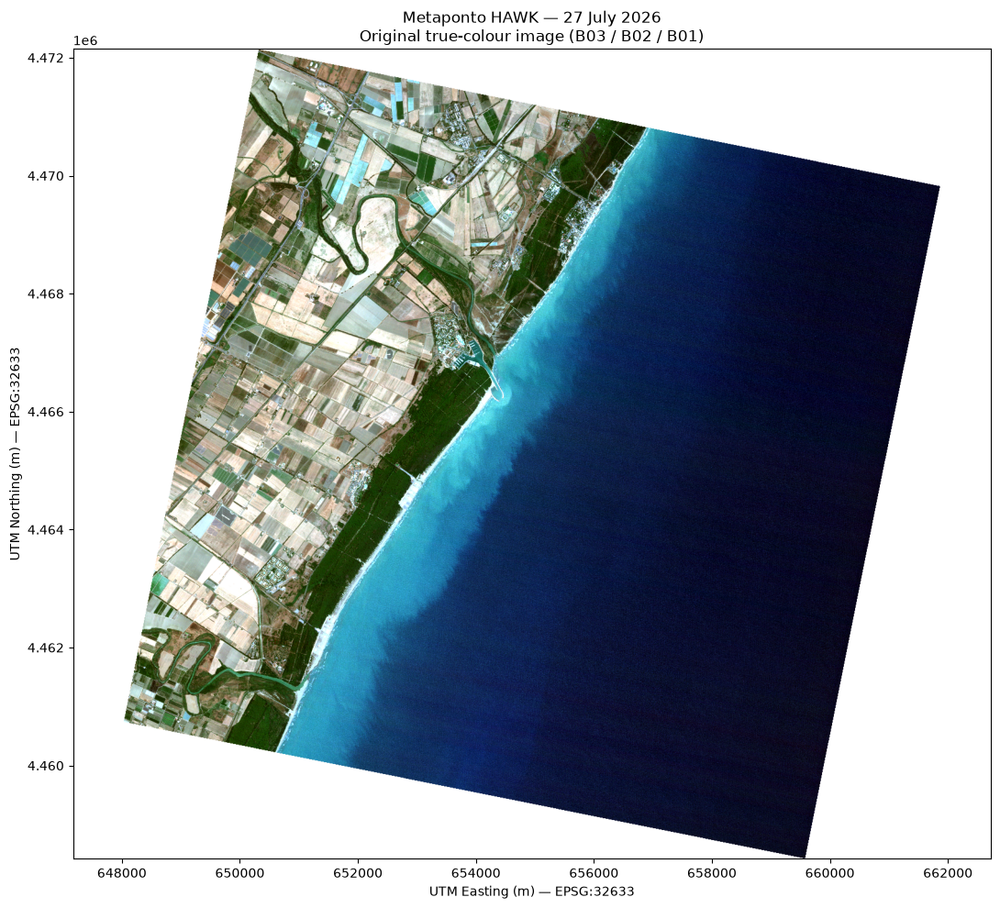

Original resolution: 2.5 m
Image CRS: EPSG:32633
Geographic extent: (648023.75, 4458416.25, 661876.25, 4472148.75)
True-colour image displayed successfully.


In [14]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# STEP 2: ORIGINAL TRUE-COLOUR IMAGE
#
# B03 = Red, B02 = Green, B01 = Blue
# All three bands use the same 2.5 m grid.
# ============================================================

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

# Read every fourth pixel for a fast display.
# Original TIFF files are not changed.
bands = {}

for band in ["B01", "B02", "B03"]:

    matches = list(HAWK_DIR.glob(f"*.{band}.tif"))

    if len(matches) != 1:
        raise RuntimeError(
            f"Expected one {band} image; found {len(matches)}"
        )

    with Image.open(matches[0]) as img:

        if band == "B02":
            original_width, original_height = img.size

            scale = img.tag_v2[33550]
            tiepoint = img.tag_v2[33922]

        bands[band] = np.asarray(img)[::4, ::4].copy()

# Create a display image using the original RGB bands.
rgb = np.stack(
    [
        bands["B03"],  # Red
        bands["B02"],  # Green
        bands["B01"],  # Blue
    ],
    axis=-1
).astype(np.float32)

# Stretch brightness separately for each colour channel.
rgb_display = np.zeros_like(rgb, dtype=np.float32)

for channel in range(3):

    data = rgb[:, :, channel]
    positive = data[data > 0]

    if positive.size == 0:
        raise RuntimeError("An RGB band contains no positive pixels.")

    low, high = np.percentile(positive, [2, 98])

    rgb_display[:, :, channel] = np.clip(
        (data - low) / max(high - low, 1),
        0,
        1
    )

# Display pixels that are zero in all three bands in white.
all_zero = np.all(rgb == 0, axis=2)
rgb_display[all_zero] = 1.0

# Geographic extent from the original GeoTIFF tags.
left = tiepoint[3]
top = tiepoint[4]

right = left + original_width * scale[0]
bottom = top - original_height * scale[1]

plt.figure(figsize=(11, 10))

plt.imshow(
    rgb_display,
    extent=[left, right, bottom, top],
    origin="upper"
)

plt.title(
    "Metaponto HAWK — 27 July 2026\n"
    "Original true-colour image (B03 / B02 / B01)"
)

plt.xlabel("UTM Easting (m) — EPSG:32633")
plt.ylabel("UTM Northing (m) — EPSG:32633")

plt.axis("equal")
plt.tight_layout()
plt.show()

print("Original resolution: 2.5 m")
print("Image CRS: EPSG:32633")
print("Geographic extent:", (left, bottom, right, top))
print("True-colour image displayed successfully.")

Original LAND pixels: 8,072,265
Original SEA pixels:  13,861,053

Erosion distance: 300 m
Erosion radius: 120 pixels

ERODED TRAINING MASKS
Reliable LAND pixels: 6,548,831
Reliable SEA pixels:  12,065,897
LAND/SEA overlap: 0 pixels

CHECK PASSED: eroded LAND and SEA masks do not overlap.


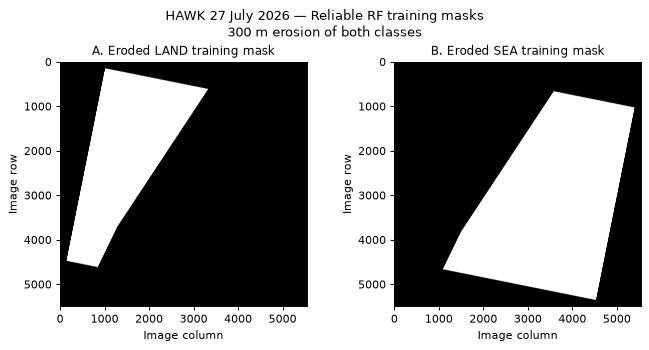


Saved:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\Figure_Eroded_Land_Sea_Training_Masks.png


In [15]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# CODE 2: LOCATE NATURAL EARTH LAND DATASET
#
# Purpose:
# Find the existing ne_10m_land shapefile or ZIP file.
#
# Does NOT change any files.
# Does NOT import Rasterio.
# ============================================================

from pathlib import Path
import importlib.util

print("CODE 2 — NATURAL EARTH DATASET CHECK")
print("=" * 65)

# Search likely locations on your laptop.
search_folders = [
    Path.home() / "Downloads",
    Path.home() / "Desktop",
    Path.home() / "Documents",
]

found_files = []

for folder in search_folders:

    if not folder.exists():
        continue

    print(f"\nSearching: {folder}")

    for pattern in [
        "ne_10m_land.shp",
        "*ne_10m_land*.zip",
    ]:

        for path in folder.rglob(pattern):

            if path.is_file() and path not in found_files:
                found_files.append(path)

print("\n" + "=" * 65)
print("NATURAL EARTH FILES FOUND")
print("=" * 65)

if found_files:

    for number, path in enumerate(found_files, start=1):
        print(f"\n{number}. {path}")
        print(f"   Size: {path.stat().st_size / 1e6:.2f} MB")

else:

    print("No ne_10m_land shapefile or ZIP found in the searched folders.")

print("\n" + "=" * 65)
print("GEOSPATIAL LIBRARY AVAILABILITY")
print("=" * 65)

for name in ["geopandas", "shapely", "pyproj", "shapefile"]:

    available = importlib.util.find_spec(name) is not None

    print(f"{name}: {'Available' if available else 'Not installed'}")

print("\nCODE 2 COMPLETE")

CODE 2 — NATURAL EARTH DATASET CHECK

Searching: C:\Users\faiza\Downloads

Searching: C:\Users\faiza\Desktop

Searching: C:\Users\faiza\Documents

NATURAL EARTH FILES FOUND

1. C:\Users\faiza\Downloads\ne_10m_land\ne_10m_land.shp
   Size: 7.17 MB

2. C:\Users\faiza\Downloads\Bari_Coastline_Research\NEW DATA\ne_10m_land.shp
   Size: 7.17 MB

3. C:\Users\faiza\Downloads\ne_10m_land (1).zip
   Size: 3.27 MB

4. C:\Users\faiza\Downloads\ne_10m_land (2).zip
   Size: 3.27 MB

5. C:\Users\faiza\Downloads\ne_10m_land.zip
   Size: 3.27 MB

GEOSPATIAL LIBRARY AVAILABILITY
geopandas: Not installed
shapely: Not installed
pyproj: Not installed
shapefile: Available

CODE 2 COMPLETE


In [16]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# CODE 3: VERIFY NATURAL EARTH SHAPEFILE
#
# This code reads metadata only.
# It does NOT change or reproject any files.
# ============================================================

from pathlib import Path
import shapefile

NE_SHP = (
    Path.home()
    / "Downloads"
    / "ne_10m_land"
    / "ne_10m_land.shp"
)

print("CODE 3 — NATURAL EARTH VERIFICATION")
print("=" * 60)

print("\nSelected shapefile:")
print(NE_SHP)

print("\nRequired shapefile components:")

for extension in [".shp", ".shx", ".dbf", ".prj"]:
    component = NE_SHP.with_suffix(extension)
    print(
        f"{extension}: "
        f"{'FOUND' if component.exists() else 'MISSING'}"
    )

print("\nCoordinate system information:")

prj_path = NE_SHP.with_suffix(".prj")

if prj_path.exists():
    prj_text = prj_path.read_text(
        encoding="utf-8",
        errors="replace"
    )

    print("PRJ file contents:")
    print(prj_text[:700])

else:
    print("No .prj file found — CRS needs further verification.")

print("\nShapefile geometry information:")

reader = shapefile.Reader(str(NE_SHP))

try:
    print("Number of land features:", len(reader))
    print("Geometry type:", reader.shapeTypeName)
    print("Dataset bounds:", reader.bbox)

finally:
    reader.close()

print("\nCODE 3 COMPLETE")

CODE 3 — NATURAL EARTH VERIFICATION

Selected shapefile:
C:\Users\faiza\Downloads\ne_10m_land\ne_10m_land.shp

Required shapefile components:
.shp: FOUND
.shx: FOUND
.dbf: FOUND
.prj: FOUND

Coordinate system information:
PRJ file contents:
GEOGCS["GCS_WGS_1984",DATUM["D_WGS_1984",SPHEROID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]]

Shapefile geometry information:
Number of land features: 11
Geometry type: POLYGON
Dataset bounds: BBox(xmin=-179.99999999999991, ymin=-89.99999999999994, xmax=180.0, ymax=83.63410065300008)

CODE 3 COMPLETE


In [17]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# CODE 4: INSTALL PYPROJ FOR COORDINATE TRANSFORMATION
# ============================================================

%pip install --only-binary=:all: pyproj

   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/6.7 MB ? eta -:--:--
   - -----------------------------

In [18]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# CODE 5: VERIFY COORDINATE TRANSFORMATION
#
# Natural Earth: EPSG:4326 (longitude / latitude)
# HAWK image:    EPSG:32633 (UTM metres)
#
# This code does NOT modify any files.
# ============================================================

from pyproj import Transformer

print("CODE 5 — COORDINATE TRANSFORMATION CHECK")
print("=" * 60)

# HAWK grid information verified in CODE 1
left = 648023.75
top = 4472148.75

width = 5541
height = 5493
pixel_size = 2.5

right = left + width * pixel_size
bottom = top - height * pixel_size

# Convert HAWK UTM coordinates to WGS 84 longitude/latitude.
# always_xy=True means input and output order is X,Y / longitude,latitude.
utm_to_wgs84 = Transformer.from_crs(
    "EPSG:32633",
    "EPSG:4326",
    always_xy=True
)

locations = {
    "Upper-left": (left, top),
    "Upper-right": (right, top),
    "Lower-left": (left, bottom),
    "Lower-right": (right, bottom),
    "Centre": (
        (left + right) / 2,
        (top + bottom) / 2
    )
}

for name, (x, y) in locations.items():

    longitude, latitude = utm_to_wgs84.transform(x, y)

    print(f"\n{name}")
    print(f"  UTM:       X = {x:.2f}, Y = {y:.2f}")
    print(f"  Longitude: {longitude:.6f}°")
    print(f"  Latitude:  {latitude:.6f}°")

print("\nHAWK image extent in metres:")
print(f"Left:   {left:.2f}")
print(f"Right:  {right:.2f}")
print(f"Bottom: {bottom:.2f}")
print(f"Top:    {top:.2f}")

print("\nCODE 5 COMPLETE")

CODE 5 — COORDINATE TRANSFORMATION CHECK

Upper-left
  UTM:       X = 648023.75, Y = 4472148.75
  Longitude: 16.743954°
  Latitude:  40.386793°

Upper-right
  UTM:       X = 661876.25, Y = 4472148.75
  Longitude: 16.907076°
  Latitude:  40.384217°

Lower-left
  UTM:       X = 648023.75, Y = 4458416.25
  Longitude: 16.740773°
  Latitude:  40.263130°

Lower-right
  UTM:       X = 661876.25, Y = 4458416.25
  Longitude: 16.903598°
  Latitude:  40.260565°

Centre
  UTM:       X = 654950.00, Y = 4465282.50
  Longitude: 16.823850°
  Latitude:  40.323705°

HAWK image extent in metres:
Left:   648023.75
Right:  661876.25
Bottom: 4458416.25
Top:    4472148.75

CODE 5 COMPLETE


CODE 6 — NATURAL EARTH → HAWK MASK

HAWK grid:
  Width: 5541
  Height: 5493
  Pixel size: 2.5 m

HAWK bounds:
  Left:   648023.75
  Right:  661876.25
  Bottom: 4458416.25
  Top:    4472148.75

HAWK geographic search area:
  Longitude: 16.690773 to 16.957076
  Latitude:  40.210565 to 40.436793

Natural Earth rings near HAWK scene: 1
Exterior rings: 1
Interior rings: 0

INITIAL NATURAL EARTH MASK
LAND pixels: 11,590,340
SEA pixels:  18,846,373
Total:       30,436,713
LAND percentage: 38.08%
SEA percentage: 61.92%

Saved preliminary mask:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\natural_earth_initial_land_mask_20260727.npy


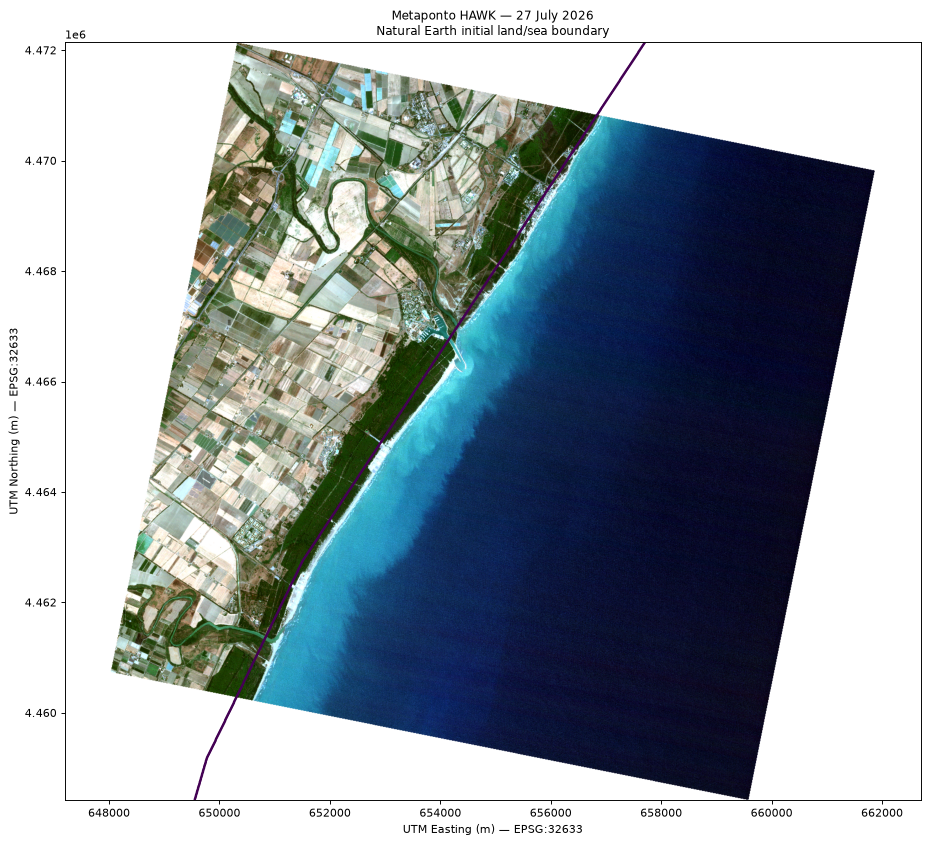


CODE 6 COMPLETE
IMPORTANT: Natural Earth is still only an initial training reference.
No erosion and no Random Forest have been performed yet.


In [23]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# CODE 6: NATURAL EARTH LAND/SEA MASK ON THE HAWK GRID
#
# Natural Earth:
#   ne_10m_land
#   WGS84 geographic coordinates
#
# HAWK:
#   EPSG:32633
#   2.5 m pixel grid
#   5541 x 5493 pixels
#
# IMPORTANT:
#   This is only the INITIAL land/sea reference.
#   It is NOT treated as exact 2026 shoreline ground truth.
#
#   LAND = 1
#   SEA  = 0
#
# No erosion is performed yet.
# No Random Forest is trained yet.
# ============================================================

from pathlib import Path

import numpy as np
import shapefile

from PIL import Image, ImageDraw

from pyproj import Transformer

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. INPUT PATHS
# ------------------------------------------------------------

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

NE_SHP = (
    Path.home()
    / "Downloads"
    / "ne_10m_land"
    / "ne_10m_land.shp"
)

OUTPUT_DIR = (
    Path.home()
    / "Downloads"
    / "Metaponto_Coastline_Project"
    / "HAWK_2026_RF"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 2. HAWK GRID
# ------------------------------------------------------------

width = 5541
height = 5493

pixel_size = 2.5

left = 648023.75
top = 4472148.75

right = left + width * pixel_size
bottom = top - height * pixel_size


print("CODE 6 — NATURAL EARTH → HAWK MASK")
print("=" * 70)

print("\nHAWK grid:")
print("  Width:", width)
print("  Height:", height)
print("  Pixel size:", pixel_size, "m")

print("\nHAWK bounds:")
print("  Left:  ", left)
print("  Right: ", right)
print("  Bottom:", bottom)
print("  Top:   ", top)


# ------------------------------------------------------------
# 3. COORDINATE TRANSFORMERS
# ------------------------------------------------------------

wgs84_to_utm = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32633",
    always_xy=True
)

utm_to_wgs84 = Transformer.from_crs(
    "EPSG:32633",
    "EPSG:4326",
    always_xy=True
)


# ------------------------------------------------------------
# 4. FIND THE HAWK AREA IN LONGITUDE/LATITUDE
# ------------------------------------------------------------

corner_xy = [
    (left, top),
    (right, top),
    (left, bottom),
    (right, bottom)
]

corner_lonlat = [
    utm_to_wgs84.transform(x, y)
    for x, y in corner_xy
]

longitudes = [
    p[0]
    for p in corner_lonlat
]

latitudes = [
    p[1]
    for p in corner_lonlat
]

lon_min = min(longitudes)
lon_max = max(longitudes)

lat_min = min(latitudes)
lat_max = max(latitudes)


# Small geographic margin used ONLY when selecting
# nearby Natural Earth rings.
margin_deg = 0.05

selection_bbox = (
    lon_min - margin_deg,
    lat_min - margin_deg,
    lon_max + margin_deg,
    lat_max + margin_deg
)

print("\nHAWK geographic search area:")
print(
    f"  Longitude: "
    f"{selection_bbox[0]:.6f} to "
    f"{selection_bbox[2]:.6f}"
)

print(
    f"  Latitude:  "
    f"{selection_bbox[1]:.6f} to "
    f"{selection_bbox[3]:.6f}"
)


# ------------------------------------------------------------
# 5. CREATE EMPTY LAND MASK
# ------------------------------------------------------------

# Pillow image is memory-efficient for polygon rasterization.
mask_image = Image.new(
    mode="L",
    size=(width, height),
    color=0
)

draw = ImageDraw.Draw(mask_image)


# ------------------------------------------------------------
# 6. HELPER FUNCTIONS
# ------------------------------------------------------------

def bbox_intersects(
    xmin1,
    ymin1,
    xmax1,
    ymax1,
    xmin2,
    ymin2,
    xmax2,
    ymax2
):
    """
    Return True when two bounding boxes overlap.
    """

    return not (
        xmax1 < xmin2
        or xmin1 > xmax2
        or ymax1 < ymin2
        or ymin1 > ymax2
    )


def signed_area(points):
    """
    Signed polygon-ring area.

    Negative/positive orientation is used to distinguish
    Shapefile exterior and interior rings.
    """

    x = np.asarray(
        [p[0] for p in points],
        dtype=np.float64
    )

    y = np.asarray(
        [p[1] for p in points],
        dtype=np.float64
    )

    return 0.5 * np.sum(
        x[:-1] * y[1:]
        -
        x[1:] * y[:-1]
    )


def ring_to_pixels(points):
    """
    Transform a WGS84 polygon ring to HAWK pixel coordinates.
    """

    lon = np.asarray(
        [p[0] for p in points],
        dtype=np.float64
    )

    lat = np.asarray(
        [p[1] for p in points],
        dtype=np.float64
    )

    x_utm, y_utm = wgs84_to_utm.transform(
        lon,
        lat
    )

    col = (
        np.asarray(x_utm) - left
    ) / pixel_size

    row = (
        top - np.asarray(y_utm)
    ) / pixel_size

    return list(
        zip(
            col.tolist(),
            row.tolist()
        )
    )


# ------------------------------------------------------------
# 7. READ NATURAL EARTH POLYGONS
# ------------------------------------------------------------

reader = shapefile.Reader(
    str(NE_SHP)
)

selected_rings = []

try:

    for shp in reader.shapes():

        points = shp.points

        part_starts = list(
            shp.parts
        )

        part_starts.append(
            len(points)
        )

        for i in range(
            len(part_starts) - 1
        ):

            ring = points[
                part_starts[i]:
                part_starts[i + 1]
            ]

            if len(ring) < 4:
                continue

            # Ensure ring is closed.
            if ring[0] != ring[-1]:
                ring = ring + [ring[0]]

            xs = [
                p[0]
                for p in ring
            ]

            ys = [
                p[1]
                for p in ring
            ]

            ring_bbox = (
                min(xs),
                min(ys),
                max(xs),
                max(ys)
            )

            if not bbox_intersects(
                *ring_bbox,
                *selection_bbox
            ):
                continue

            selected_rings.append(
                (
                    ring,
                    signed_area(ring)
                )
            )

finally:

    reader.close()


print(
    "\nNatural Earth rings near HAWK scene:",
    len(selected_rings)
)

if len(selected_rings) == 0:

    raise RuntimeError(
        "No Natural Earth polygon rings "
        "intersect the HAWK area."
    )


# ------------------------------------------------------------
# 8. RASTERIZE OUTER LAND RINGS
# ------------------------------------------------------------

# According to the ESRI Shapefile polygon convention,
# exterior rings are normally clockwise.
#
# With this signed-area formula:
# clockwise rings have negative area.

outer_rings = [
    ring
    for ring, area
    in selected_rings
    if area < 0
]

hole_rings = [
    ring
    for ring, area
    in selected_rings
    if area > 0
]


print(
    "Exterior rings:",
    len(outer_rings)
)

print(
    "Interior rings:",
    len(hole_rings)
)


for ring in outer_rings:

    pixel_ring = ring_to_pixels(
        ring
    )

    draw.polygon(
        pixel_ring,
        fill=1
    )


# Draw polygon holes as non-land.
for ring in hole_rings:

    pixel_ring = ring_to_pixels(
        ring
    )

    draw.polygon(
        pixel_ring,
        fill=0
    )


# ------------------------------------------------------------
# 9. CONVERT PIL MASK TO NUMPY
# ------------------------------------------------------------

land_mask = np.asarray(
    mask_image,
    dtype=np.uint8
).copy()


land_pixels = int(
    np.count_nonzero(
        land_mask == 1
    )
)

sea_pixels = int(
    np.count_nonzero(
        land_mask == 0
    )
)

total_pixels = (
    width * height
)


print("\nINITIAL NATURAL EARTH MASK")
print("=" * 70)

print(
    f"LAND pixels: "
    f"{land_pixels:,}"
)

print(
    f"SEA pixels:  "
    f"{sea_pixels:,}"
)

print(
    f"Total:       "
    f"{total_pixels:,}"
)

print(
    f"LAND percentage: "
    f"{100 * land_pixels / total_pixels:.2f}%"
)

print(
    f"SEA percentage: "
    f"{100 * sea_pixels / total_pixels:.2f}%"
)


# ------------------------------------------------------------
# 10. SAVE PRELIMINARY MASK
# ------------------------------------------------------------

mask_path = (
    OUTPUT_DIR
    / "natural_earth_initial_land_mask_20260727.npy"
)

np.save(
    mask_path,
    land_mask
)

print(
    "\nSaved preliminary mask:"
)

print(
    mask_path
)


# ------------------------------------------------------------
# 11. LOAD ORIGINAL HAWK RGB FOR VISUAL CHECK
# ------------------------------------------------------------

rgb_arrays = {}

for band in [
    "B01",
    "B02",
    "B03"
]:

    matches = list(
        HAWK_DIR.glob(
            f"*.{band}.tif"
        )
    )

    if len(matches) != 1:

        raise RuntimeError(
            f"Expected one {band} image, "
            f"found {len(matches)}"
        )

    with Image.open(
        matches[0]
    ) as img:

        rgb_arrays[band] = np.asarray(
            img
        )[::4, ::4].copy()


rgb = np.stack(
    [
        rgb_arrays["B03"],
        rgb_arrays["B02"],
        rgb_arrays["B01"]
    ],
    axis=-1
).astype(
    np.float32
)


# ------------------------------------------------------------
# 12. DISPLAY STRETCH
# ------------------------------------------------------------

rgb_display = np.zeros_like(
    rgb,
    dtype=np.float32
)

for channel in range(3):

    data = rgb[
        :,
        :,
        channel
    ]

    positive = data[
        data > 0
    ]

    low, high = np.percentile(
        positive,
        [2, 98]
    )

    rgb_display[
        :,
        :,
        channel
    ] = np.clip(
        (
            data - low
        )
        /
        max(
            high - low,
            1
        ),
        0,
        1
    )


# Outside HAWK footprint = white.
all_zero = np.all(
    rgb == 0,
    axis=2
)

rgb_display[
    all_zero
] = 1.0


# ------------------------------------------------------------
# 13. DISPLAY NATURAL EARTH BOUNDARY OVER HAWK
# ------------------------------------------------------------

mask_preview = land_mask[
    ::4,
    ::4
]

preview_height = min(
    rgb_display.shape[0],
    mask_preview.shape[0]
)

preview_width = min(
    rgb_display.shape[1],
    mask_preview.shape[1]
)

rgb_display = rgb_display[
    :preview_height,
    :preview_width
]

mask_preview = mask_preview[
    :preview_height,
    :preview_width
]


plt.figure(
    figsize=(11, 10)
)

plt.imshow(
    rgb_display,
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper"
)


# Draw ONLY the Natural Earth land/sea boundary.
plt.contour(
    mask_preview,
    levels=[0.5],
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper",
    linewidths=2
)


plt.title(
    "Metaponto HAWK — 27 July 2026\n"
    "Natural Earth initial land/sea boundary"
)

plt.xlabel(
    "UTM Easting (m) — EPSG:32633"
)

plt.ylabel(
    "UTM Northing (m) — EPSG:32633"
)

plt.axis(
    "equal"
)

plt.tight_layout()

plt.show()


print(
    "\nCODE 6 COMPLETE"
)

print(
    "IMPORTANT: "
    "Natural Earth is still only an initial "
    "training reference."
)

print(
    "No erosion and no Random Forest "
    "have been performed yet."
)

CODE 6B — RAW NATURAL EARTH REFERENCE WITH NODATA
HAWK arrays loaded.

RAW NATURAL EARTH REFERENCE
LAND   (1):   8,072,265
SEA    (0):   13,861,053
NODATA (255): 8,503,395
TOTAL:        30,436,713

Percentages:
LAND:   26.52%
SEA:    45.54%
NODATA: 27.94%

Count check: PASSED

Saved:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\GT_raw_NaturalEarth_HAWK_20260727.npy


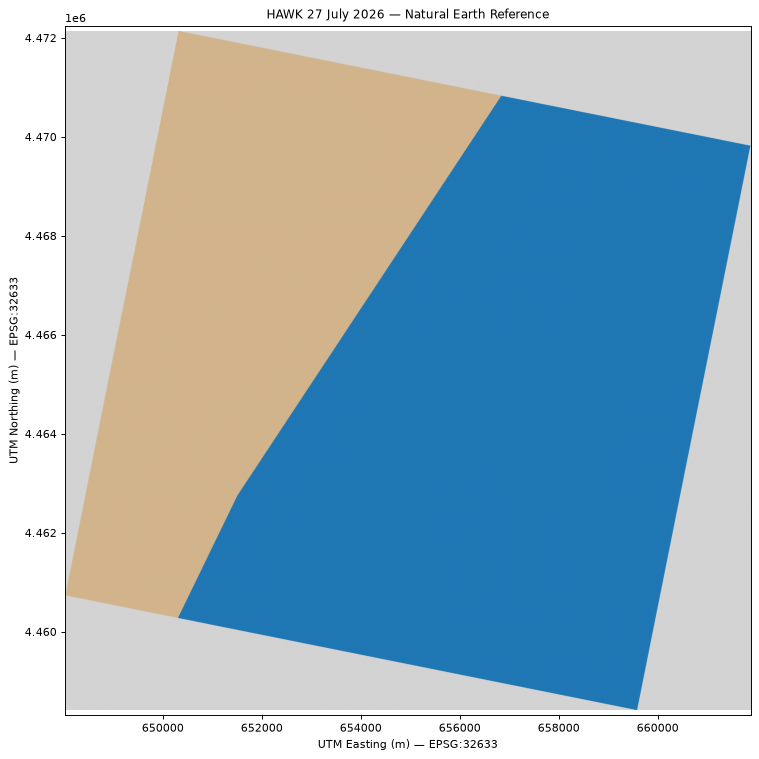


CODE 6B COMPLETE
This is the RAW reference only.
Erosion will be introduced later only for reliable Random Forest training pixels.


In [22]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# CODE 6B: CORRECT RAW NATURAL EARTH REFERENCE
#
# Required workflow classes:
#   0   = SEA
#   1   = LAND
#   255 = NODATA
#
# Natural Earth boundary itself is NOT modified.
# No erosion yet.
# No Random Forest yet.
# ============================================================

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

OUTPUT_DIR = (
    Path.home()
    / "Downloads"
    / "Metaponto_Coastline_Project"
    / "HAWK_2026_RF"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("CODE 6B — RAW NATURAL EARTH REFERENCE WITH NODATA")
print("=" * 70)


# ------------------------------------------------------------
# 1. LOAD THE FOUR 2.5 m HAWK BANDS
# ------------------------------------------------------------

hawk = {}

for band in ["B01", "B02", "B03", "B07"]:

    files = list(
        HAWK_DIR.glob(f"*.{band}.tif")
    )

    if len(files) != 1:
        raise RuntimeError(
            f"Expected exactly one {band} file; found {len(files)}"
        )

    with Image.open(files[0]) as img:
        hawk[band] = np.asarray(img).copy()


print("HAWK arrays loaded.")


# ------------------------------------------------------------
# 2. DEFINE VALID HAWK FOOTPRINT
#
# We require a positive value in ALL four RF bands.
# Pixels outside the satellite footprint are zero.
# ------------------------------------------------------------

valid_hawk = (
    (hawk["B01"] > 0)
    &
    (hawk["B02"] > 0)
    &
    (hawk["B03"] > 0)
    &
    (hawk["B07"] > 0)
)


# ------------------------------------------------------------
# 3. BUILD THREE-CLASS RAW GT
#
# Start everything as NODATA = 255.
# Within valid HAWK pixels:
#    Natural Earth sea  -> 0
#    Natural Earth land -> 1
#
# land_mask was created in CODE 6.
# ------------------------------------------------------------

GT_raw = np.full(
    land_mask.shape,
    255,
    dtype=np.uint8
)

GT_raw[
    valid_hawk & (land_mask == 0)
] = 0

GT_raw[
    valid_hawk & (land_mask == 1)
] = 1


# ------------------------------------------------------------
# 4. COUNT CLASSES
# ------------------------------------------------------------

n_land = int(
    np.count_nonzero(GT_raw == 1)
)

n_sea = int(
    np.count_nonzero(GT_raw == 0)
)

n_nodata = int(
    np.count_nonzero(GT_raw == 255)
)

n_total = GT_raw.size


print("\nRAW NATURAL EARTH REFERENCE")
print("=" * 70)

print(f"LAND   (1):   {n_land:,}")
print(f"SEA    (0):   {n_sea:,}")
print(f"NODATA (255): {n_nodata:,}")
print(f"TOTAL:        {n_total:,}")

print("\nPercentages:")
print(f"LAND:   {100*n_land/n_total:.2f}%")
print(f"SEA:    {100*n_sea/n_total:.2f}%")
print(f"NODATA: {100*n_nodata/n_total:.2f}%")


# ------------------------------------------------------------
# 5. INTERNAL CONSISTENCY CHECK
# ------------------------------------------------------------

assert (
    n_land + n_sea + n_nodata
    ==
    n_total
), "Class counts do not sum to total pixels."

print("\nCount check: PASSED")


# ------------------------------------------------------------
# 6. SAVE RAW REFERENCE
# ------------------------------------------------------------

save_path = (
    OUTPUT_DIR
    / "GT_raw_NaturalEarth_HAWK_20260727.npy"
)

np.save(
    save_path,
    GT_raw
)

print("\nSaved:")
print(save_path)


# ------------------------------------------------------------
# 7. PLOT RAW REFERENCE
#
# Same scientific meaning as the earlier workflow:
# sea, land, and NoData are shown separately.
# ------------------------------------------------------------

cmap = ListedColormap([
    "tab:blue",     # sea
    "tan",          # land
    "lightgray"     # nodata
])

norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 255.5],
    cmap.N
)

# Convert values only for plotting:
# 0 -> 0
# 1 -> 1
# 255 -> 2
plot_gt = np.full(
    GT_raw.shape,
    2,
    dtype=np.uint8
)

plot_gt[GT_raw == 0] = 0
plot_gt[GT_raw == 1] = 1


plt.figure(figsize=(9, 9))

plt.imshow(
    plot_gt,
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper",
    cmap=cmap,
    vmin=0,
    vmax=2
)

plt.title(
    "HAWK 27 July 2026 — Natural Earth Reference"
)

plt.xlabel(
    "UTM Easting (m) — EPSG:32633"
)

plt.ylabel(
    "UTM Northing (m) — EPSG:32633"
)

plt.axis("equal")
plt.tight_layout()
plt.show()


print("\nCODE 6B COMPLETE")
print(
    "This is the RAW reference only."
)
print(
    "Erosion will be introduced later only for reliable "
    "Random Forest training pixels."
)

In [4]:
# ============================================================
# PLOT DISPLAY SIZE — RUN ONCE
# Small notebook figures, high-quality saved figures
# ============================================================

import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (6.2, 4.6),
    "figure.dpi": 85,          # smaller inside VS Code
    "savefig.dpi": 300,        # high quality for paper
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
})

print("Plot display size set successfully.")

Plot display size set successfully.


CODE 7 — RF TRAINING AND VALIDATION

Raw GT loaded:
Shape: (5493, 5541)
LAND: 8,072,265
SEA: 13,861,053
NODATA: 8,503,395
B01 loaded: (5493, 5541)
B02 loaded: (5493, 5541)
B03 loaded: (5493, 5541)
B07 loaded: (5493, 5541)

Valid in all four RF bands: 21,933,318

Training-label erosion:
Distance: 300.0 m
Pixels: 120

ERODED RELIABLE TRAINING AREAS
Reliable LAND: 6,548,831
Reliable SEA: 12,065,897


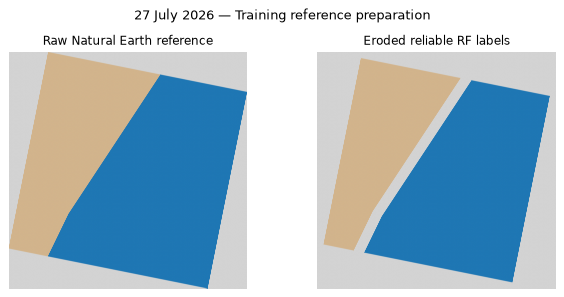


SPATIAL REGIONS
Train LAND available: 5,377,583
Train SEA available: 6,232,016
Test LAND available: 591,929
Test SEA available: 4,059,559

RF DATASET
Training pixels: 200,000
Testing pixels: 100,000
Features: ['B01', 'B02', 'B03', 'B07']

Training Random Forest...
Random Forest training complete.

SPATIAL HOLDOUT RESULTS

Confusion matrix:
[[49992     8]
 [   75 49925]]

Overall agreement: 99.917%
Balanced agreement: 99.917%
Sea recall: 99.984%
Land recall: 99.850%
Land precision: 99.984%
Land F1: 99.917%


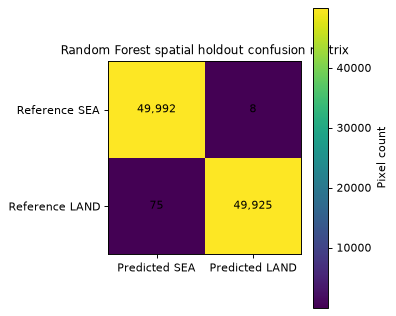

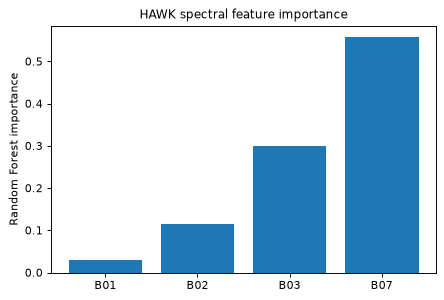

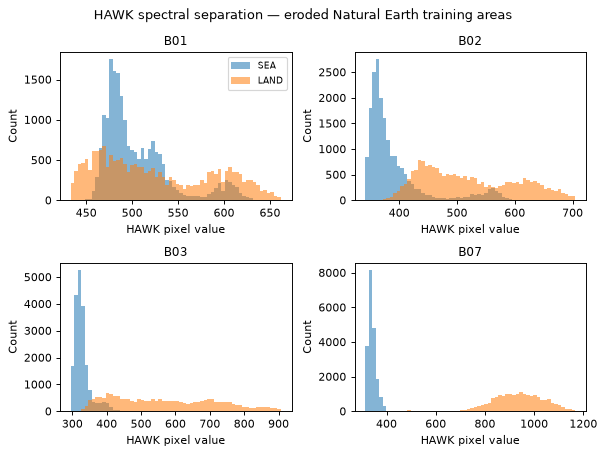


FILES SAVED
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\RF_HAWK_20260727.joblib
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\RF_validation_metrics.json
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\FIG_RF_training_reference_erosion.png
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\FIG_RF_confusion_matrix.png
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\FIG_RF_feature_importance.png
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\FIG_RF_spectral_distributions.png

CODE 7 COMPLETE


In [24]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# CODE 7
#
# ERODED TRAINING LABELS
# + RANDOM FOREST
# + SPATIAL HOLDOUT VALIDATION
# + PAPER DIAGNOSTIC FIGURES
#
# Natural Earth raw reference:
#     SEA    = 0
#     LAND   = 1
#     NODATA = 255
#
# IMPORTANT:
# Natural Earth is used to obtain RELIABLE INTERIOR training
# pixels only. The uncertain coastal zone is excluded.
# ============================================================

from pathlib import Path
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from scipy.ndimage import distance_transform_edt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import joblib
import json


# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

OUTPUT_DIR = (
    Path.home()
    / "Downloads"
    / "Metaponto_Coastline_Project"
    / "HAWK_2026_RF"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

GT_PATH = (
    OUTPUT_DIR
    / "GT_raw_NaturalEarth_HAWK_20260727.npy"
)

print("CODE 7 — RF TRAINING AND VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# 2. LOAD RAW NATURAL EARTH GT
# ------------------------------------------------------------

GT = np.load(GT_PATH)

height, width = GT.shape

print("\nRaw GT loaded:")
print("Shape:", GT.shape)

print(
    "LAND:",
    f"{np.count_nonzero(GT == 1):,}"
)

print(
    "SEA:",
    f"{np.count_nonzero(GT == 0):,}"
)

print(
    "NODATA:",
    f"{np.count_nonzero(GT == 255):,}"
)


# ------------------------------------------------------------
# 3. LOAD THE FOUR 2.5 m HAWK BANDS
# ------------------------------------------------------------

RF_BANDS = [
    "B01",
    "B02",
    "B03",
    "B07"
]

bands = {}

for band in RF_BANDS:

    files = list(
        HAWK_DIR.glob(
            f"*.{band}.tif"
        )
    )

    if len(files) != 1:

        raise RuntimeError(
            f"Expected one {band} file; "
            f"found {len(files)}"
        )

    with Image.open(files[0]) as img:

        bands[band] = np.asarray(
            img
        ).copy()

    print(
        f"{band} loaded:",
        bands[band].shape
    )


# ------------------------------------------------------------
# 4. VALID HAWK PIXELS
#
# 0    = outside/invalid
# 4095 = saturation value
# ------------------------------------------------------------

valid_hawk = np.ones(
    GT.shape,
    dtype=bool
)

for band in RF_BANDS:

    valid_hawk &= (
        (bands[band] > 0)
        &
        (bands[band] < 4095)
    )


print(
    "\nValid in all four RF bands:",
    f"{np.count_nonzero(valid_hawk):,}"
)


# ------------------------------------------------------------
# 5. ERODE BOTH REFERENCE CLASSES
#
# Conservative exclusion distance from the Natural Earth
# boundary.
#
# HAWK pixel = 2.5 m
# 300 m / 2.5 = 120 pixels
# ------------------------------------------------------------

PIXEL_SIZE = 2.5

EROSION_DISTANCE_M = 300.0

EROSION_PIXELS = int(
    np.ceil(
        EROSION_DISTANCE_M
        / PIXEL_SIZE
    )
)

print("\nTraining-label erosion:")
print(
    "Distance:",
    EROSION_DISTANCE_M,
    "m"
)

print(
    "Pixels:",
    EROSION_PIXELS
)


raw_land = (
    GT == 1
)

raw_sea = (
    GT == 0
)


# Distance from every class pixel to its class boundary.
land_distance = distance_transform_edt(
    raw_land
)

sea_distance = distance_transform_edt(
    raw_sea
)


safe_land = (
    raw_land
    &
    valid_hawk
    &
    (
        land_distance
        >= EROSION_PIXELS
    )
)

safe_sea = (
    raw_sea
    &
    valid_hawk
    &
    (
        sea_distance
        >= EROSION_PIXELS
    )
)


n_safe_land = int(
    np.count_nonzero(
        safe_land
    )
)

n_safe_sea = int(
    np.count_nonzero(
        safe_sea
    )
)


print("\nERODED RELIABLE TRAINING AREAS")
print("=" * 70)

print(
    "Reliable LAND:",
    f"{n_safe_land:,}"
)

print(
    "Reliable SEA:",
    f"{n_safe_sea:,}"
)

if (
    n_safe_land < 10000
    or
    n_safe_sea < 10000
):

    raise RuntimeError(
        "Too few reliable pixels remain. "
        "Do not continue automatically."
    )


# ------------------------------------------------------------
# 6. SAVE ERODED TRAINING REFERENCE
# ------------------------------------------------------------

training_reference = np.full(
    GT.shape,
    255,
    dtype=np.uint8
)

training_reference[
    safe_sea
] = 0

training_reference[
    safe_land
] = 1


ERODED_PATH = (
    OUTPUT_DIR
    / "GT_eroded_training_HAWK_20260727.npy"
)

np.save(
    ERODED_PATH,
    training_reference
)


# ------------------------------------------------------------
# 7. FIGURE — RAW VS ERODED REFERENCE
# ------------------------------------------------------------

display_cmap = ListedColormap(
    [
        "tab:blue",
        "tan",
        "lightgray"
    ]
)

def reference_for_display(arr):

    d = np.full(
        arr.shape,
        2,
        dtype=np.uint8
    )

    d[arr == 0] = 0
    d[arr == 1] = 1

    return d


fig, axes = plt.subplots(
    1,
    2,
    figsize=(7.4, 3.5)
)

axes[0].imshow(
    reference_for_display(GT),
    cmap=display_cmap,
    vmin=0,
    vmax=2
)

axes[0].set_title(
    "Raw Natural Earth reference"
)

axes[1].imshow(
    reference_for_display(
        training_reference
    ),
    cmap=display_cmap,
    vmin=0,
    vmax=2
)

axes[1].set_title(
    "Eroded reliable RF labels"
)

for ax in axes:
    ax.axis("off")

fig.suptitle(
    "27 July 2026 — Training reference preparation"
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "FIG_RF_training_reference_erosion.png",
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 8. SPATIAL HOLDOUT
#
# TRAIN = northern 60%
# BUFFER = middle 10%
# TEST = southern 30%
#
# The unused buffer reduces spatial leakage.
# ------------------------------------------------------------

train_end = int(
    height * 0.60
)

test_start = int(
    height * 0.70
)


train_land_idx = np.flatnonzero(
    safe_land[
        :train_end,
        :
    ]
)

train_sea_idx = np.flatnonzero(
    safe_sea[
        :train_end,
        :
    ]
)


# Convert local flattened index to full-image index.
test_land_local = np.flatnonzero(
    safe_land[
        test_start:,
        :
    ]
)

test_sea_local = np.flatnonzero(
    safe_sea[
        test_start:,
        :
    ]
)

test_land_idx = (
    test_land_local
    +
    test_start * width
)

test_sea_idx = (
    test_sea_local
    +
    test_start * width
)


print("\nSPATIAL REGIONS")
print("=" * 70)

print(
    "Train LAND available:",
    f"{len(train_land_idx):,}"
)

print(
    "Train SEA available:",
    f"{len(train_sea_idx):,}"
)

print(
    "Test LAND available:",
    f"{len(test_land_idx):,}"
)

print(
    "Test SEA available:",
    f"{len(test_sea_idx):,}"
)


# ------------------------------------------------------------
# 9. BALANCED SAMPLING
# ------------------------------------------------------------

rng = np.random.default_rng(
    42
)

N_TRAIN_PER_CLASS = min(
    100000,
    len(train_land_idx),
    len(train_sea_idx)
)

N_TEST_PER_CLASS = min(
    50000,
    len(test_land_idx),
    len(test_sea_idx)
)


if (
    N_TRAIN_PER_CLASS < 10000
    or
    N_TEST_PER_CLASS < 5000
):

    raise RuntimeError(
        "Spatial holdout does not contain enough "
        "land and sea samples."
    )


train_land_sample = rng.choice(
    train_land_idx,
    size=N_TRAIN_PER_CLASS,
    replace=False
)

train_sea_sample = rng.choice(
    train_sea_idx,
    size=N_TRAIN_PER_CLASS,
    replace=False
)

test_land_sample = rng.choice(
    test_land_idx,
    size=N_TEST_PER_CLASS,
    replace=False
)

test_sea_sample = rng.choice(
    test_sea_idx,
    size=N_TEST_PER_CLASS,
    replace=False
)


train_idx = np.concatenate(
    [
        train_sea_sample,
        train_land_sample
    ]
)

y_train = np.concatenate(
    [
        np.zeros(
            N_TRAIN_PER_CLASS,
            dtype=np.uint8
        ),
        np.ones(
            N_TRAIN_PER_CLASS,
            dtype=np.uint8
        )
    ]
)


test_idx = np.concatenate(
    [
        test_sea_sample,
        test_land_sample
    ]
)

y_test = np.concatenate(
    [
        np.zeros(
            N_TEST_PER_CLASS,
            dtype=np.uint8
        ),
        np.ones(
            N_TEST_PER_CLASS,
            dtype=np.uint8
        )
    ]
)


# ------------------------------------------------------------
# 10. BUILD RF FEATURE MATRICES
# ------------------------------------------------------------

def extract_features(indices):

    return np.column_stack(
        [
            bands[b].ravel()[
                indices
            ]
            for b in RF_BANDS
        ]
    )


X_train = extract_features(
    train_idx
)

X_test = extract_features(
    test_idx
)


print("\nRF DATASET")
print("=" * 70)

print(
    "Training pixels:",
    f"{len(y_train):,}"
)

print(
    "Testing pixels:",
    f"{len(y_test):,}"
)

print(
    "Features:",
    RF_BANDS
)


# ------------------------------------------------------------
# 11. RANDOM FOREST
# ------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=250,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

print("\nTraining Random Forest...")

rf.fit(
    X_train,
    y_train
)

print(
    "Random Forest training complete."
)


# ------------------------------------------------------------
# 12. SPATIAL TEST PREDICTION
# ------------------------------------------------------------

y_pred = rf.predict(
    X_test
)


cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

balanced = balanced_accuracy_score(
    y_test,
    y_pred
)

precision_land = precision_score(
    y_test,
    y_pred,
    pos_label=1
)

recall_land = recall_score(
    y_test,
    y_pred,
    pos_label=1
)

f1_land = f1_score(
    y_test,
    y_pred,
    pos_label=1
)

recall_sea = recall_score(
    y_test,
    y_pred,
    pos_label=0
)


print("\nSPATIAL HOLDOUT RESULTS")
print("=" * 70)

print("\nConfusion matrix:")
print(cm)

print(
    f"\nOverall agreement: "
    f"{accuracy * 100:.3f}%"
)

print(
    f"Balanced agreement: "
    f"{balanced * 100:.3f}%"
)

print(
    f"Sea recall: "
    f"{recall_sea * 100:.3f}%"
)

print(
    f"Land recall: "
    f"{recall_land * 100:.3f}%"
)

print(
    f"Land precision: "
    f"{precision_land * 100:.3f}%"
)

print(
    f"Land F1: "
    f"{f1_land * 100:.3f}%"
)


# ------------------------------------------------------------
# 13. CONFUSION MATRIX FIGURE
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(4.6, 4.0)
)

im = ax.imshow(
    cm
)

ax.set_xticks(
    [0, 1],
    [
        "Predicted SEA",
        "Predicted LAND"
    ]
)

ax.set_yticks(
    [0, 1],
    [
        "Reference SEA",
        "Reference LAND"
    ]
)

for i in range(2):
    for j in range(2):

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center"
        )

ax.set_title(
    "Random Forest spatial holdout confusion matrix"
)

fig.colorbar(
    im,
    ax=ax,
    label="Pixel count"
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "FIG_RF_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 14. FEATURE IMPORTANCE
# ------------------------------------------------------------

importance = rf.feature_importances_

fig, ax = plt.subplots(
    figsize=(5.3, 3.6)
)

ax.bar(
    RF_BANDS,
    importance
)

ax.set_ylabel(
    "Random Forest importance"
)

ax.set_title(
    "HAWK spectral feature importance"
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "FIG_RF_feature_importance.png",
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 15. SPECTRAL HISTOGRAMS
#
# Equal number of land and sea samples.
# ------------------------------------------------------------

N_HIST = min(
    20000,
    N_TEST_PER_CLASS
)

hist_sea = test_sea_sample[
    :N_HIST
]

hist_land = test_land_sample[
    :N_HIST
]


fig, axes = plt.subplots(
    2,
    2,
    figsize=(7.2, 5.4)
)

axes = axes.ravel()

for ax, band in zip(
    axes,
    RF_BANDS
):

    sea_values = (
        bands[band]
        .ravel()[
            hist_sea
        ]
    )

    land_values = (
        bands[band]
        .ravel()[
            hist_land
        ]
    )

    low = min(
        np.percentile(
            sea_values,
            1
        ),
        np.percentile(
            land_values,
            1
        )
    )

    high = max(
        np.percentile(
            sea_values,
            99
        ),
        np.percentile(
            land_values,
            99
        )
    )

    ax.hist(
        sea_values,
        bins=60,
        range=(low, high),
        alpha=0.55,
        label="SEA"
    )

    ax.hist(
        land_values,
        bins=60,
        range=(low, high),
        alpha=0.55,
        label="LAND"
    )

    ax.set_title(
        band
    )

    ax.set_xlabel(
        "HAWK pixel value"
    )

    ax.set_ylabel(
        "Count"
    )


axes[0].legend()

fig.suptitle(
    "HAWK spectral separation — eroded Natural Earth training areas"
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "FIG_RF_spectral_distributions.png",
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 16. SAVE MODEL + RESULTS
# ------------------------------------------------------------

MODEL_PATH = (
    OUTPUT_DIR
    / "RF_HAWK_20260727.joblib"
)

joblib.dump(
    {
        "model": rf,
        "bands": RF_BANDS,
        "pixel_size_m": PIXEL_SIZE,
        "erosion_distance_m":
            EROSION_DISTANCE_M,
        "train_end_row":
            train_end,
        "test_start_row":
            test_start
    },
    MODEL_PATH
)


metrics = {
    "overall_agreement":
        float(accuracy),
    "balanced_agreement":
        float(balanced),
    "sea_recall":
        float(recall_sea),
    "land_recall":
        float(recall_land),
    "land_precision":
        float(precision_land),
    "land_f1":
        float(f1_land),

    "confusion_matrix":
        cm.tolist(),

    "n_train_per_class":
        int(N_TRAIN_PER_CLASS),

    "n_test_per_class":
        int(N_TEST_PER_CLASS),

    "erosion_distance_m":
        float(EROSION_DISTANCE_M),

    "feature_importance":
        {
            band: float(value)
            for band, value
            in zip(
                RF_BANDS,
                importance
            )
        }
}


with open(
    OUTPUT_DIR
    / "RF_validation_metrics.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


print("\nFILES SAVED")
print("=" * 70)

print(MODEL_PATH)

print(
    OUTPUT_DIR
    / "RF_validation_metrics.json"
)

print(
    OUTPUT_DIR
    / "FIG_RF_training_reference_erosion.png"
)

print(
    OUTPUT_DIR
    / "FIG_RF_confusion_matrix.png"
)

print(
    OUTPUT_DIR
    / "FIG_RF_feature_importance.png"
)

print(
    OUTPUT_DIR
    / "FIG_RF_spectral_distributions.png"
)

print("\nCODE 7 COMPLETE")

CODE 8 — FULL-SCENE RF + PRINCIPAL COASTLINE
Random Forest found in memory as: rf
RF model saved:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\RF_model_HAWK_20260727.joblib
B01 loaded: (5493, 5541)
B02 loaded: (5493, 5541)
B03 loaded: (5493, 5541)
B07 loaded: (5493, 5541)

Valid HAWK pixels:
21,933,318

Applying Random Forest to full HAWK scene...
Prediction chunks: 44
  Chunk 1/44 complete
  Chunk 5/44 complete
  Chunk 10/44 complete
  Chunk 15/44 complete
  Chunk 20/44 complete
  Chunk 25/44 complete
  Chunk 30/44 complete
  Chunk 35/44 complete
  Chunk 40/44 complete
  Chunk 44/44 complete

FULL-SCENE RF CLASSIFICATION
Predicted LAND:   8,464,997
Predicted SEA:    13,468,321
NODATA:           8,503,395

Saved RF prediction:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\RF_fullscene_prediction_20260727.npy

CONNECTED LAND COMPONENTS
Number of land components: 795
Mainland pixels: 8,460,259

CONNECTED SEA COMPONENTS
Number of sea components: 16

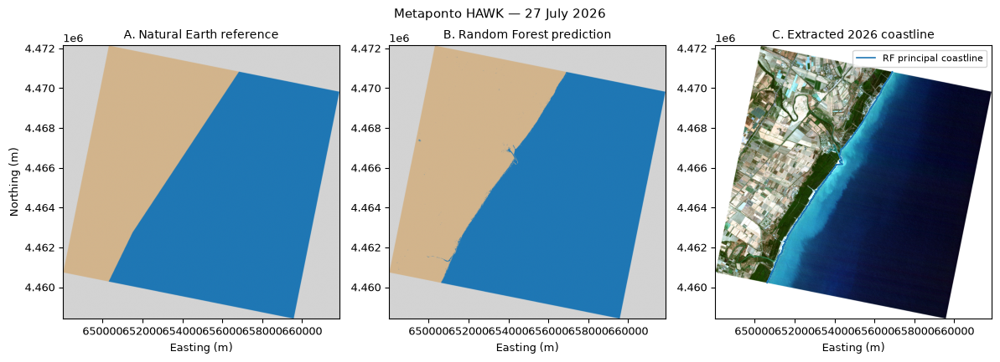

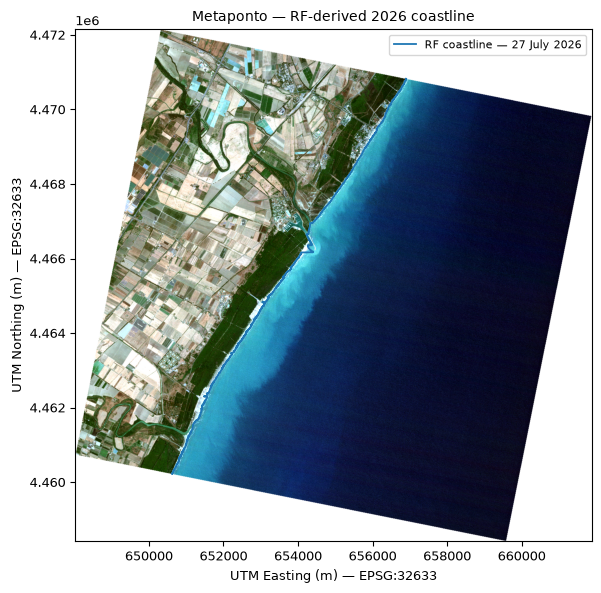

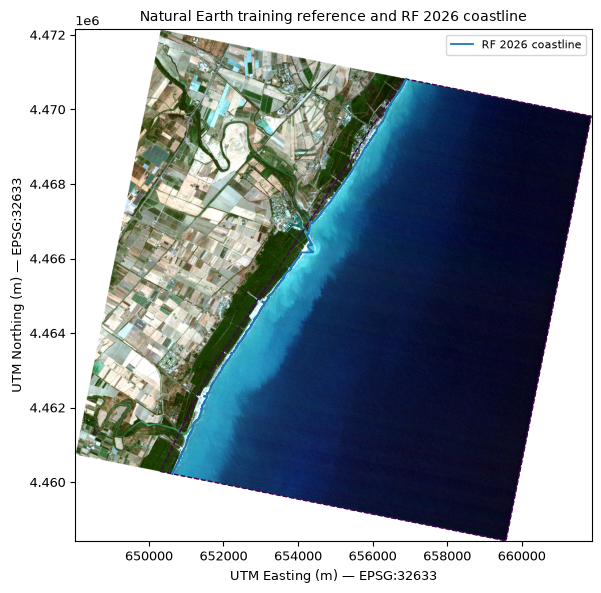


CODE 8 COMPLETE

Files saved in:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF

Main outputs:
1. RF_fullscene_prediction_20260727.npy
2. RF_principal_coastline_20260727_EPSG32633.csv
3. Figure_RF_reference_prediction_coastline_20260727.png
4. Figure_RF_coastline_over_HAWK_20260727.png
5. Figure_NaturalEarth_vs_RF_coastline_20260727.png
6. CODE8_RF_fullscene_summary.txt

IMPORTANT:
Do not interpret the Natural Earth line as the true 2026 coastline.
The RF coastline must next be checked against an independently interpreted HAWK shoreline.


In [25]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# CODE 8
#
# FULL-SCENE RANDOM FOREST CLASSIFICATION
# + PRINCIPAL COASTLINE EXTRACTION
# + PAPER FIGURES
#
# Uses:
#   B01, B02, B03, B07
#   Random Forest trained in CODE 7
#
# Outputs:
#   1. Full RF land/sea classification
#   2. Main connected mainland
#   3. Main connected open sea
#   4. Principal sea-facing coastline
#   5. Coastline coordinates in metres
#   6. Publication-style figures
#
# IMPORTANT:
# Natural Earth is NOT used as final 2026 shoreline truth.
# It is shown only as the original training reference.
# ============================================================

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from scipy import ndimage
import csv
import joblib
import gc


# ============================================================
# 0. NORMAL FIGURE SIZE FOR VS CODE
# ============================================================

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8
})


# ============================================================
# 1. PATHS
# ============================================================

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

OUTPUT_DIR = (
    Path.home()
    / "Downloads"
    / "Metaponto_Coastline_Project"
    / "HAWK_2026_RF"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

GT_PATH = (
    OUTPUT_DIR
    / "GT_raw_NaturalEarth_HAWK_20260727.npy"
)


print("CODE 8 — FULL-SCENE RF + PRINCIPAL COASTLINE")
print("=" * 72)


# ============================================================
# 2. FIND RANDOM FOREST FROM CODE 7
# ============================================================

if "rf" in globals():

    RF_MODEL = rf
    print("Random Forest found in memory as: rf")

elif "rf_model" in globals():

    RF_MODEL = rf_model
    print("Random Forest found in memory as: rf_model")

else:

    model_files = sorted(
        list(OUTPUT_DIR.glob("*.joblib"))
        +
        list(OUTPUT_DIR.glob("*.pkl"))
    )

    if len(model_files) == 1:

        RF_MODEL = joblib.load(
            model_files[0]
        )

        print(
            "Random Forest loaded from:",
            model_files[0]
        )

    else:

        raise RuntimeError(
            "Random Forest from CODE 7 was not found. "
            "Do NOT restart the kernel before CODE 8."
        )


# Save a permanent copy of the trained model.
MODEL_PATH = (
    OUTPUT_DIR
    / "RF_model_HAWK_20260727.joblib"
)

joblib.dump(
    RF_MODEL,
    MODEL_PATH
)

print("RF model saved:")
print(MODEL_PATH)


# ============================================================
# 3. LOAD FOUR HAWK BANDS
# ============================================================

bands = {}

for band in [
    "B01",
    "B02",
    "B03",
    "B07"
]:

    files = list(
        HAWK_DIR.glob(
            f"*.{band}.tif"
        )
    )

    if len(files) != 1:
        raise RuntimeError(
            f"Expected one {band} file; "
            f"found {len(files)}"
        )

    with Image.open(
        files[0]
    ) as img:

        bands[band] = np.asarray(
            img
        ).copy()

    print(
        f"{band} loaded:",
        bands[band].shape
    )


height, width = bands["B01"].shape


# ============================================================
# 4. GEOGRAPHIC GRID
# ============================================================

pixel_size = 2.5

left = 648023.75
top = 4472148.75

right = left + width * pixel_size
bottom = top - height * pixel_size


# ============================================================
# 5. VALID HAWK PIXELS
# ============================================================

valid_hawk = (
    (bands["B01"] > 0)
    &
    (bands["B02"] > 0)
    &
    (bands["B03"] > 0)
    &
    (bands["B07"] > 0)
    &
    (bands["B01"] < 4095)
    &
    (bands["B02"] < 4095)
    &
    (bands["B03"] < 4095)
    &
    (bands["B07"] < 4095)
)


valid_count = int(
    valid_hawk.sum()
)

print("\nValid HAWK pixels:")
print(f"{valid_count:,}")


# ============================================================
# 6. FULL-SCENE RANDOM FOREST PREDICTION
#
# Output classes:
#   0   = SEA
#   1   = LAND
#   255 = NODATA
#
# Prediction is done in chunks to protect memory.
# ============================================================

prediction = np.full(
    (height, width),
    255,
    dtype=np.uint8
)

prediction_flat = prediction.ravel()

valid_indices = np.flatnonzero(
    valid_hawk.ravel()
)

band_flat = {
    name: array.ravel()
    for name, array in bands.items()
}


CHUNK_SIZE = 500_000

n_chunks = int(
    np.ceil(
        len(valid_indices)
        /
        CHUNK_SIZE
    )
)


print("\nApplying Random Forest to full HAWK scene...")
print("Prediction chunks:", n_chunks)


for chunk_number, start in enumerate(
    range(
        0,
        len(valid_indices),
        CHUNK_SIZE
    ),
    start=1
):

    stop = min(
        start + CHUNK_SIZE,
        len(valid_indices)
    )

    idx = valid_indices[
        start:stop
    ]

    X_chunk = np.column_stack([
        band_flat["B01"][idx],
        band_flat["B02"][idx],
        band_flat["B03"][idx],
        band_flat["B07"][idx]
    ])

    prediction_flat[idx] = (
        RF_MODEL.predict(
            X_chunk
        ).astype(
            np.uint8
        )
    )

    if (
        chunk_number == 1
        or
        chunk_number % 5 == 0
        or
        chunk_number == n_chunks
    ):

        print(
            f"  Chunk "
            f"{chunk_number}/{n_chunks} complete"
        )


prediction = prediction_flat.reshape(
    height,
    width
)


# ============================================================
# 7. FULL-SCENE CLASS COUNTS
# ============================================================

n_pred_land = int(
    np.count_nonzero(
        prediction == 1
    )
)

n_pred_sea = int(
    np.count_nonzero(
        prediction == 0
    )
)

n_pred_nodata = int(
    np.count_nonzero(
        prediction == 255
    )
)


print("\nFULL-SCENE RF CLASSIFICATION")
print("=" * 72)

print(
    f"Predicted LAND:   "
    f"{n_pred_land:,}"
)

print(
    f"Predicted SEA:    "
    f"{n_pred_sea:,}"
)

print(
    f"NODATA:           "
    f"{n_pred_nodata:,}"
)


# Save full classification.
PREDICTION_PATH = (
    OUTPUT_DIR
    / "RF_fullscene_prediction_20260727.npy"
)

np.save(
    PREDICTION_PATH,
    prediction
)

print("\nSaved RF prediction:")
print(PREDICTION_PATH)


# ============================================================
# 8. IDENTIFY MAINLAND
#
# We keep only the largest connected predicted LAND region.
# This suppresses small offshore/inland classification objects.
# ============================================================

structure = np.ones(
    (3, 3),
    dtype=np.uint8
)


land_binary = (
    prediction == 1
)

land_labels, n_land_components = (
    ndimage.label(
        land_binary,
        structure=structure
    )
)


land_component_sizes = np.bincount(
    land_labels.ravel()
)

land_component_sizes[0] = 0

mainland_id = int(
    np.argmax(
        land_component_sizes
    )
)

mainland = (
    land_labels
    ==
    mainland_id
)

mainland_pixels = int(
    mainland.sum()
)


print("\nCONNECTED LAND COMPONENTS")
print("=" * 72)

print(
    "Number of land components:",
    n_land_components
)

print(
    "Mainland pixels:",
    f"{mainland_pixels:,}"
)


del land_labels
del land_binary
gc.collect()


# ============================================================
# 9. IDENTIFY OPEN SEA
#
# Keep the largest connected predicted SEA region.
# This removes isolated inland water bodies from the
# principal coastline extraction.
# ============================================================

sea_binary = (
    prediction == 0
)

sea_labels, n_sea_components = (
    ndimage.label(
        sea_binary,
        structure=structure
    )
)


sea_component_sizes = np.bincount(
    sea_labels.ravel()
)

sea_component_sizes[0] = 0

open_sea_id = int(
    np.argmax(
        sea_component_sizes
    )
)

open_sea = (
    sea_labels
    ==
    open_sea_id
)

open_sea_pixels = int(
    open_sea.sum()
)


print("\nCONNECTED SEA COMPONENTS")
print("=" * 72)

print(
    "Number of sea components:",
    n_sea_components
)

print(
    "Open-sea pixels:",
    f"{open_sea_pixels:,}"
)


del sea_labels
del sea_binary
gc.collect()


# ============================================================
# 10. MAINLAND / OPEN-SEA CONTACT
#
# This is much more restrictive than detecting ALL
# predicted class boundaries.
#
# Only predicted MAINLAND pixels touching the connected
# OPEN SEA are candidates.
# ============================================================

sea_neighbourhood = ndimage.binary_dilation(
    open_sea,
    structure=structure
)

coast_contact = (
    mainland
    &
    sea_neighbourhood
)


contact_pixels = int(
    coast_contact.sum()
)


print("\nMAINLAND–OPEN SEA CONTACT")
print("=" * 72)

print(
    "Coastal contact pixels:",
    f"{contact_pixels:,}"
)


# ============================================================
# 11. EXTRACT PRINCIPAL SEA-FACING SHORELINE
#
# Metaponto coastline crosses the HAWK scene approximately
# once for each image row.
#
# For each row, choose the easternmost mainland pixel
# touching open sea.
#
# This avoids inland river-bank branches because those
# generally occur farther west than the sea-facing coast.
# ============================================================

coast_rows = []
coast_cols = []


for row in range(height):

    candidates = np.flatnonzero(
        coast_contact[row]
    )

    if candidates.size == 0:
        continue

    coast_rows.append(
        row
    )

    coast_cols.append(
        int(
            candidates.max()
        )
    )


coast_rows = np.asarray(
    coast_rows,
    dtype=np.int32
)

coast_cols = np.asarray(
    coast_cols,
    dtype=np.int32
)


print("\nPRINCIPAL RF COASTLINE")
print("=" * 72)

print(
    "Rows containing coastline:",
    f"{len(coast_rows):,}"
)


if len(coast_rows) < 100:

    raise RuntimeError(
        "Too few coastline rows were extracted. "
        "Do not continue to CODE 9."
    )


# ============================================================
# 12. CONVERT COASTLINE PIXELS TO UTM METRES
#
# Pixel centre coordinates.
# ============================================================

coast_x = (
    left
    +
    (
        coast_cols
        +
        0.5
    )
    *
    pixel_size
)

coast_y = (
    top
    -
    (
        coast_rows
        +
        0.5
    )
    *
    pixel_size
)


# ============================================================
# 13. BASIC CONTINUITY CHECK
# ============================================================

dx = np.diff(
    coast_x
)

dy = np.diff(
    coast_y
)

segment_distances = np.sqrt(
    dx**2
    +
    dy**2
)

median_step = float(
    np.median(
        segment_distances
    )
)

max_step = float(
    np.max(
        segment_distances
    )
)


print(
    f"Median point-to-point spacing: "
    f"{median_step:.2f} m"
)

print(
    f"Maximum point-to-point spacing: "
    f"{max_step:.2f} m"
)


# ============================================================
# 14. SAVE COASTLINE COORDINATES
# ============================================================

COAST_CSV = (
    OUTPUT_DIR
    / "RF_principal_coastline_20260727_EPSG32633.csv"
)


with open(
    COAST_CSV,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(
        f
    )

    writer.writerow([
        "row",
        "column",
        "easting_m",
        "northing_m"
    ])

    for r, c, x, y in zip(
        coast_rows,
        coast_cols,
        coast_x,
        coast_y
    ):

        writer.writerow([
            int(r),
            int(c),
            f"{x:.3f}",
            f"{y:.3f}"
        ])


print("\nSaved coastline coordinates:")
print(COAST_CSV)


# ============================================================
# 15. LOAD RAW NATURAL EARTH REFERENCE
# ============================================================

if not GT_PATH.exists():

    raise FileNotFoundError(
        "CODE 6B GT file was not found."
    )


GT_raw = np.load(
    GT_PATH
)


# ============================================================
# 16. PREPARE TRUE-COLOUR HAWK DISPLAY
#
# Display is downsampled only for plotting.
# Analysis remains at full 2.5 m resolution.
# ============================================================

DISPLAY_STEP = 4


rgb = np.stack(
    [
        bands["B03"][::DISPLAY_STEP, ::DISPLAY_STEP],
        bands["B02"][::DISPLAY_STEP, ::DISPLAY_STEP],
        bands["B01"][::DISPLAY_STEP, ::DISPLAY_STEP]
    ],
    axis=-1
).astype(
    np.float32
)


rgb_display = np.zeros_like(
    rgb,
    dtype=np.float32
)


for channel in range(3):

    data = rgb[
        :,
        :,
        channel
    ]

    positive = data[
        data > 0
    ]

    low, high = np.percentile(
        positive,
        [2, 98]
    )

    rgb_display[
        :,
        :,
        channel
    ] = np.clip(
        (
            data - low
        )
        /
        max(
            high - low,
            1
        ),
        0,
        1
    )


rgb_zero = np.all(
    rgb == 0,
    axis=2
)

rgb_display[
    rgb_zero
] = 1.0


# ============================================================
# 17. DISPLAY ARRAYS
# ============================================================

# 0 = sea
# 1 = land
# 2 = nodata

GT_display = np.full(
    GT_raw.shape,
    2,
    dtype=np.uint8
)

GT_display[
    GT_raw == 0
] = 0

GT_display[
    GT_raw == 1
] = 1


RF_display = np.full(
    prediction.shape,
    2,
    dtype=np.uint8
)

RF_display[
    prediction == 0
] = 0

RF_display[
    prediction == 1
] = 1


class_cmap = ListedColormap([
    "tab:blue",
    "tan",
    "lightgray"
])


# ============================================================
# 18. FIGURE 1
# NATURAL EARTH / RF / EXTRACTED COASTLINE
#
# This intentionally resembles the structure of your
# previous workflow result figure.
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4.2)
)


# Panel A
axes[0].imshow(
    GT_display[::DISPLAY_STEP, ::DISPLAY_STEP],
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper",
    cmap=class_cmap,
    vmin=0,
    vmax=2
)

axes[0].set_title(
    "A. Natural Earth reference"
)

axes[0].set_xlabel(
    "Easting (m)"
)

axes[0].set_ylabel(
    "Northing (m)"
)


# Panel B
axes[1].imshow(
    RF_display[::DISPLAY_STEP, ::DISPLAY_STEP],
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper",
    cmap=class_cmap,
    vmin=0,
    vmax=2
)

axes[1].set_title(
    "B. Random Forest prediction"
)

axes[1].set_xlabel(
    "Easting (m)"
)


# Panel C
axes[2].imshow(
    rgb_display,
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper"
)

axes[2].plot(
    coast_x,
    coast_y,
    linewidth=1.2,
    label="RF principal coastline"
)

axes[2].set_title(
    "C. Extracted 2026 coastline"
)

axes[2].set_xlabel(
    "Easting (m)"
)

axes[2].legend(
    loc="best"
)


for ax in axes:
    ax.set_aspect(
        "equal"
    )


fig.suptitle(
    "Metaponto HAWK — 27 July 2026",
    fontsize=11
)

fig.tight_layout()


FIG1_PATH = (
    OUTPUT_DIR
    / "Figure_RF_reference_prediction_coastline_20260727.png"
)

fig.savefig(
    FIG1_PATH,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. FIGURE 2
# PRINCIPAL RF SHORELINE OVER ORIGINAL HAWK IMAGE
# ============================================================

fig, ax = plt.subplots(
    figsize=(6.5, 6)
)

ax.imshow(
    rgb_display,
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper"
)

ax.plot(
    coast_x,
    coast_y,
    linewidth=1.3,
    label="RF coastline — 27 July 2026"
)

ax.set_title(
    "Metaponto — RF-derived 2026 coastline"
)

ax.set_xlabel(
    "UTM Easting (m) — EPSG:32633"
)

ax.set_ylabel(
    "UTM Northing (m) — EPSG:32633"
)

ax.set_aspect(
    "equal"
)

ax.legend(
    loc="best"
)

fig.tight_layout()


FIG2_PATH = (
    OUTPUT_DIR
    / "Figure_RF_coastline_over_HAWK_20260727.png"
)

fig.savefig(
    FIG2_PATH,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. FIGURE 3
# NATURAL EARTH REFERENCE BOUNDARY VS RF 2026 COASTLINE
#
# Natural Earth is shown only as the INITIAL reference,
# not as positional ground truth.
# ============================================================

fig, ax = plt.subplots(
    figsize=(6.5, 6)
)

ax.imshow(
    rgb_display,
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper"
)


GT_preview = GT_raw[
    ::DISPLAY_STEP,
    ::DISPLAY_STEP
]


ax.contour(
    GT_preview,
    levels=[0.5],
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper",
    linewidths=1.0,
    linestyles="--"
)


ax.plot(
    coast_x,
    coast_y,
    linewidth=1.3,
    label="RF 2026 coastline"
)


ax.set_title(
    "Natural Earth training reference and RF 2026 coastline"
)

ax.set_xlabel(
    "UTM Easting (m) — EPSG:32633"
)

ax.set_ylabel(
    "UTM Northing (m) — EPSG:32633"
)

ax.set_aspect(
    "equal"
)

ax.legend(
    loc="best"
)

fig.tight_layout()


FIG3_PATH = (
    OUTPUT_DIR
    / "Figure_NaturalEarth_vs_RF_coastline_20260727.png"
)

fig.savefig(
    FIG3_PATH,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. SAVE SUMMARY TEXT
# ============================================================

SUMMARY_PATH = (
    OUTPUT_DIR
    / "CODE8_RF_fullscene_summary.txt"
)


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "Metaponto HAWK — 27 July 2026\n"
    )

    f.write(
        "CODE 8 — Full-scene RF and principal coastline\n\n"
    )

    f.write(
        f"Valid HAWK pixels: {valid_count:,}\n"
    )

    f.write(
        f"Predicted LAND: {n_pred_land:,}\n"
    )

    f.write(
        f"Predicted SEA: {n_pred_sea:,}\n"
    )

    f.write(
        f"NoData: {n_pred_nodata:,}\n"
    )

    f.write(
        f"Mainland pixels: {mainland_pixels:,}\n"
    )

    f.write(
        f"Open-sea pixels: {open_sea_pixels:,}\n"
    )

    f.write(
        f"Mainland-open sea contact pixels: "
        f"{contact_pixels:,}\n"
    )

    f.write(
        f"Principal coastline points: "
        f"{len(coast_rows):,}\n"
    )

    f.write(
        f"Median coastline point spacing: "
        f"{median_step:.3f} m\n"
    )

    f.write(
        f"Maximum coastline point spacing: "
        f"{max_step:.3f} m\n"
    )


print("\n" + "=" * 72)
print("CODE 8 COMPLETE")
print("=" * 72)

print("\nFiles saved in:")
print(OUTPUT_DIR)

print("\nMain outputs:")
print("1.", PREDICTION_PATH.name)
print("2.", COAST_CSV.name)
print("3.", FIG1_PATH.name)
print("4.", FIG2_PATH.name)
print("5.", FIG3_PATH.name)
print("6.", SUMMARY_PATH.name)

print(
    "\nIMPORTANT:"
)

print(
    "Do not interpret the Natural Earth line as "
    "the true 2026 coastline."
)

print(
    "The RF coastline must next be checked against "
    "an independently interpreted HAWK shoreline."
)

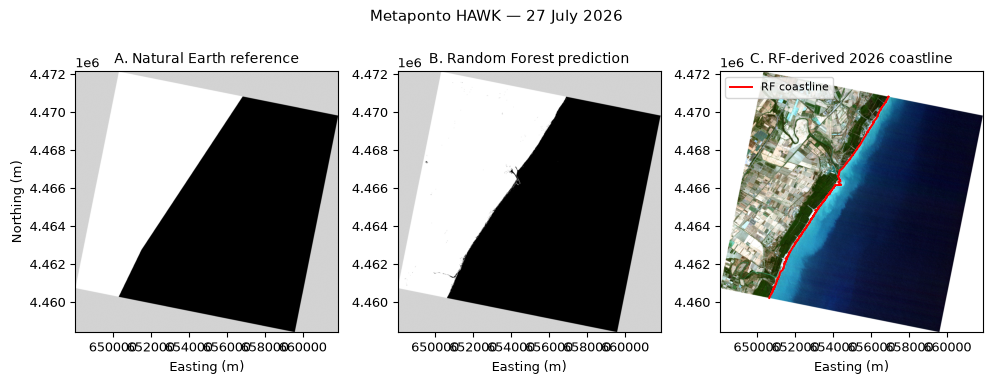

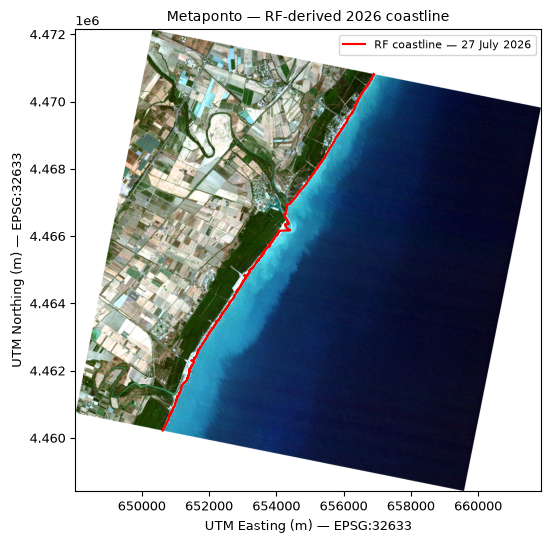

Saved:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\Figure_FINAL_RF_blackwhite_redcoastline.png
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\Figure_FINAL_RF_red_coastline_over_HAWK.png


In [26]:
# ============================================================
# CODE 8B — FINAL PLOT STYLE
#
# SEA  = BLACK
# LAND = WHITE
# NODATA = LIGHT GREY
# RF COASTLINE = RED
#
# This does NOT retrain Random Forest.
# ============================================================

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import csv


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

OUTPUT_DIR = (
    Path.home()
    / "Downloads"
    / "Metaponto_Coastline_Project"
    / "HAWK_2026_RF"
)

GT_PATH = (
    OUTPUT_DIR
    / "GT_raw_NaturalEarth_HAWK_20260727.npy"
)

PRED_PATH = (
    OUTPUT_DIR
    / "RF_fullscene_prediction_20260727.npy"
)

COAST_PATH = (
    OUTPUT_DIR
    / "RF_principal_coastline_20260727_EPSG32633.csv"
)


# ------------------------------------------------------------
# LOAD RESULTS
# ------------------------------------------------------------

GT_raw = np.load(GT_PATH)
prediction = np.load(PRED_PATH)


coast_x = []
coast_y = []

with open(
    COAST_PATH,
    "r",
    encoding="utf-8"
) as f:

    reader = csv.DictReader(f)

    for row in reader:
        coast_x.append(float(row["easting_m"]))
        coast_y.append(float(row["northing_m"]))


coast_x = np.asarray(coast_x)
coast_y = np.asarray(coast_y)


# ------------------------------------------------------------
# GEOGRAPHIC EXTENT
# ------------------------------------------------------------

height, width = prediction.shape

pixel_size = 2.5

left = 648023.75
top = 4472148.75

right = left + width * pixel_size
bottom = top - height * pixel_size


# ------------------------------------------------------------
# TRUE-COLOUR HAWK IMAGE
# ------------------------------------------------------------

rgb_bands = {}

for band in ["B01", "B02", "B03"]:

    path = next(
        HAWK_DIR.glob(f"*.{band}.tif")
    )

    with Image.open(path) as img:
        rgb_bands[band] = np.asarray(img)[::4, ::4].copy()


rgb = np.stack(
    [
        rgb_bands["B03"],
        rgb_bands["B02"],
        rgb_bands["B01"]
    ],
    axis=-1
).astype(np.float32)


rgb_display = np.zeros_like(
    rgb,
    dtype=np.float32
)


for channel in range(3):

    data = rgb[:, :, channel]

    positive = data[data > 0]

    low, high = np.percentile(
        positive,
        [2, 98]
    )

    rgb_display[:, :, channel] = np.clip(
        (data - low)
        /
        max(high - low, 1),
        0,
        1
    )


rgb_display[
    np.all(rgb == 0, axis=2)
] = 1.0


# ------------------------------------------------------------
# PREPARE BLACK / WHITE CLASSIFICATION
# ------------------------------------------------------------

def make_display(array):

    display = np.full(
        array.shape,
        2,
        dtype=np.uint8
    )

    display[array == 0] = 0   # SEA
    display[array == 1] = 1   # LAND

    return display


GT_display = make_display(GT_raw)
RF_display = make_display(prediction)


bw_cmap = ListedColormap([
    "black",       # sea
    "white",       # land
    "lightgray"    # nodata
])


DISPLAY_STEP = 4


# ------------------------------------------------------------
# FIGURE 1 — THREE PANELS
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(10, 3.8)
)


axes[0].imshow(
    GT_display[::DISPLAY_STEP, ::DISPLAY_STEP],
    extent=[left, right, bottom, top],
    origin="upper",
    cmap=bw_cmap,
    vmin=0,
    vmax=2
)

axes[0].set_title(
    "A. Natural Earth reference"
)


axes[1].imshow(
    RF_display[::DISPLAY_STEP, ::DISPLAY_STEP],
    extent=[left, right, bottom, top],
    origin="upper",
    cmap=bw_cmap,
    vmin=0,
    vmax=2
)

axes[1].set_title(
    "B. Random Forest prediction"
)


axes[2].imshow(
    rgb_display,
    extent=[left, right, bottom, top],
    origin="upper"
)

axes[2].plot(
    coast_x,
    coast_y,
    color="red",
    linewidth=1.4,
    label="RF coastline"
)

axes[2].set_title(
    "C. RF-derived 2026 coastline"
)

axes[2].legend(
    loc="best"
)


for ax in axes:

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_aspect(
        "equal"
    )


axes[0].set_ylabel(
    "Northing (m)"
)


fig.suptitle(
    "Metaponto HAWK — 27 July 2026"
)

fig.tight_layout()


save1 = (
    OUTPUT_DIR
    / "Figure_FINAL_RF_blackwhite_redcoastline.png"
)

fig.savefig(
    save1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# FIGURE 2 — RED RF COASTLINE OVER HAWK
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6, 5.5)
)

ax.imshow(
    rgb_display,
    extent=[left, right, bottom, top],
    origin="upper"
)

ax.plot(
    coast_x,
    coast_y,
    color="red",
    linewidth=1.5,
    label="RF coastline — 27 July 2026"
)

ax.set_title(
    "Metaponto — RF-derived 2026 coastline"
)

ax.set_xlabel(
    "UTM Easting (m) — EPSG:32633"
)

ax.set_ylabel(
    "UTM Northing (m) — EPSG:32633"
)

ax.set_aspect(
    "equal"
)

ax.legend(
    loc="best"
)

fig.tight_layout()


save2 = (
    OUTPUT_DIR
    / "Figure_FINAL_RF_red_coastline_over_HAWK.png"
)

fig.savefig(
    save2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Saved:")
print(save1)
print(save2)

CODE 8R — REFINED RF COASTLINE
RF model loaded:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\RF_model_HAWK_20260727.joblib
RF classes: [0 1]
B01 (5493, 5541)
B02 (5493, 5541)
B03 (5493, 5541)
B07 (5493, 5541)

Valid HAWK pixels: 21,933,318

Predicting RF land probabilities...
  chunk 1/55
  chunk 10/55
  chunk 20/55
  chunk 30/55
  chunk 40/55
  chunk 50/55
  chunk 55/55

Probability smoothing: 1.0 pixel = 2.5 m
0.50 probability contours found: 416

REFINED COASTLINE
Points: 11,056
Length: 21.12 km
Median point spacing: 2.25 m
Maximum point spacing: 3.52 m
Median distance to old CODE-8 coast: 2.76 m

Saved refined coastline:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\RF_REFINED_probability_coastline_20260727_EPSG32633.csv


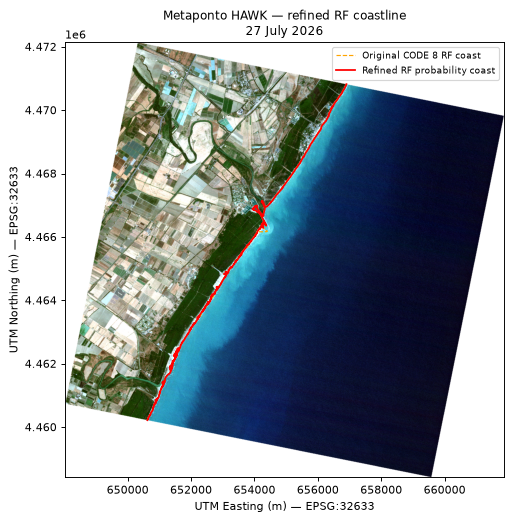


Saved figure:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\Figure_RF_REFINED_probability_coastline_20260727.png

CODE 8R COMPLETE

Do NOT delete the original CODE 8 coastline.
Next: redo manual photo interpretation with more vertices, then compare both RF versions.


In [9]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# CODE 8R
#
# REFINED RANDOM-FOREST COASTLINE EXTRACTION
#
# Replaces ONLY the coastline-extraction part of CODE 8.
#
# Method:
#   RF probabilities
#       ↓
#   very light Gaussian smoothing (1 pixel = 2.5 m)
#       ↓
#   P(LAND) = 0.50 decision boundary
#       ↓
#   select principal Metaponto coastal contour
#
# IMPORTANT:
# - RF is NOT retrained.
# - Manual shoreline is NOT used to tune the result.
# - Original CODE 8 result is preserved.
# ============================================================

from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.spatial import cKDTree
import pandas as pd
import joblib
import gc


# ============================================================
# 1. PATHS
# ============================================================

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

OUTPUT_DIR = (
    Path.home()
    / "Downloads"
    / "Metaponto_Coastline_Project"
    / "HAWK_2026_RF"
)

MODEL_PATH = (
    OUTPUT_DIR
    / "RF_model_HAWK_20260727.joblib"
)

OLD_COAST_PATH = (
    OUTPUT_DIR
    / "RF_principal_coastline_20260727_EPSG32633.csv"
)

NEW_COAST_PATH = (
    OUTPUT_DIR
    / "RF_REFINED_probability_coastline_20260727_EPSG32633.csv"
)

PROBABILITY_PATH = (
    OUTPUT_DIR
    / "RF_land_probability_20260727.npy"
)

FIGURE_PATH = (
    OUTPUT_DIR
    / "Figure_RF_REFINED_probability_coastline_20260727.png"
)


print("CODE 8R — REFINED RF COASTLINE")
print("=" * 70)


# ============================================================
# 2. LOAD TRAINED RANDOM FOREST
# ============================================================

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"RF model not found:\n{MODEL_PATH}"
    )

rf_model = joblib.load(
    MODEL_PATH
)

print("RF model loaded:")
print(MODEL_PATH)

print(
    "RF classes:",
    rf_model.classes_
)


# Find class index corresponding to LAND = 1.

land_matches = np.where(
    rf_model.classes_ == 1
)[0]

if len(land_matches) != 1:
    raise RuntimeError(
        "Could not identify LAND class = 1."
    )

LAND_CLASS_INDEX = int(
    land_matches[0]
)


# ============================================================
# 3. LOAD HAWK BANDS
# ============================================================

bands = {}

for band in [
    "B01",
    "B02",
    "B03",
    "B07"
]:

    files = list(
        HAWK_DIR.glob(
            f"*.{band}.tif"
        )
    )

    if len(files) != 1:
        raise RuntimeError(
            f"Expected one {band} file; "
            f"found {len(files)}"
        )

    with Image.open(
        files[0]
    ) as img:

        bands[band] = np.asarray(
            img
        ).copy()

    print(
        band,
        bands[band].shape
    )


height, width = bands["B01"].shape


# ============================================================
# 4. GEOGRAPHIC GRID
# ============================================================

pixel_size = 2.5

left = 648023.75
top = 4472148.75

right = (
    left
    +
    width
    *
    pixel_size
)

bottom = (
    top
    -
    height
    *
    pixel_size
)


# ============================================================
# 5. VALID HAWK FOOTPRINT
# ============================================================

valid = (
    (bands["B01"] > 0)
    &
    (bands["B02"] > 0)
    &
    (bands["B03"] > 0)
    &
    (bands["B07"] > 0)
    &
    (bands["B01"] < 4095)
    &
    (bands["B02"] < 4095)
    &
    (bands["B03"] < 4095)
    &
    (bands["B07"] < 4095)
)

valid_indices = np.flatnonzero(
    valid.ravel()
)

print(
    "\nValid HAWK pixels:",
    f"{len(valid_indices):,}"
)


# ============================================================
# 6. PREDICT LAND PROBABILITY
# ============================================================

probability = np.full(
    height * width,
    np.nan,
    dtype=np.float32
)

band_flat = {
    name: arr.ravel()
    for name, arr in bands.items()
}

CHUNK_SIZE = 400_000

n_chunks = int(
    np.ceil(
        len(valid_indices)
        /
        CHUNK_SIZE
    )
)


print(
    "\nPredicting RF land probabilities..."
)


for chunk_number, start in enumerate(
    range(
        0,
        len(valid_indices),
        CHUNK_SIZE
    ),
    start=1
):

    stop = min(
        start + CHUNK_SIZE,
        len(valid_indices)
    )

    idx = valid_indices[
        start:stop
    ]

    X = np.column_stack([
        band_flat["B01"][idx],
        band_flat["B02"][idx],
        band_flat["B03"][idx],
        band_flat["B07"][idx]
    ])

    p = rf_model.predict_proba(
        X
    )[
        :,
        LAND_CLASS_INDEX
    ]

    probability[idx] = p.astype(
        np.float32
    )

    if (
        chunk_number == 1
        or
        chunk_number % 10 == 0
        or
        chunk_number == n_chunks
    ):

        print(
            f"  chunk "
            f"{chunk_number}/{n_chunks}"
        )


probability = probability.reshape(
    height,
    width
)


np.save(
    PROBABILITY_PATH,
    probability
)


# ============================================================
# 7. VERY LIGHT SPATIAL REGULARIZATION
#
# sigma = 1 pixel = 2.5 m
#
# This is intentionally small.
# We are NOT using a large smoothing kernel.
# ============================================================

SIGMA_PIXELS = 1.0


weighted_probability = np.nan_to_num(
    probability,
    nan=0.0
)

valid_float = valid.astype(
    np.float32
)


numerator = ndimage.gaussian_filter(
    weighted_probability
    *
    valid_float,
    sigma=SIGMA_PIXELS,
    mode="nearest"
)

denominator = ndimage.gaussian_filter(
    valid_float,
    sigma=SIGMA_PIXELS,
    mode="nearest"
)


smoothed_probability = np.full(
    probability.shape,
    np.nan,
    dtype=np.float32
)


usable = (
    denominator > 1e-6
)

smoothed_probability[
    usable
] = (
    numerator[usable]
    /
    denominator[usable]
)

smoothed_probability[
    ~valid
] = np.nan


print(
    "\nProbability smoothing:",
    f"{SIGMA_PIXELS:.1f} pixel = "
    f"{SIGMA_PIXELS*pixel_size:.1f} m"
)


# ============================================================
# 8. EXTRACT P(LAND)=0.50 CONTOURS
# ============================================================

temporary_fig, temporary_ax = (
    plt.subplots()
)

contour_set = temporary_ax.contour(
    smoothed_probability,
    levels=[0.50]
)

segments = contour_set.allsegs[
    0
]

plt.close(
    temporary_fig
)


print(
    "0.50 probability contours found:",
    len(segments)
)


if len(segments) == 0:

    raise RuntimeError(
        "No RF probability contour was found."
    )


# ============================================================
# 9. LOAD OLD CODE-8 COASTLINE
#
# Used ONLY to identify which contour belongs to the
# Metaponto sea-facing coast.
#
# It is NOT used to move or tune the new contour.
# ============================================================

old_coast = pd.read_csv(
    OLD_COAST_PATH
)

old_xy = np.column_stack([
    old_coast["easting_m"].to_numpy(),
    old_coast["northing_m"].to_numpy()
])

old_tree = cKDTree(
    old_xy
)


# ============================================================
# 10. SCORE CONTOURS
#
# Require:
# - sufficient geographic length
# - large north-south coverage
# - reasonable proximity to original sea-facing coast
# ============================================================

candidate_records = []


for number, segment in enumerate(
    segments
):

    if len(segment) < 20:
        continue


    # Matplotlib contour coordinates:
    # segment[:,0] = image column
    # segment[:,1] = image row

    cols = segment[:, 0]
    rows = segment[:, 1]


    x = (
        left
        +
        (
            cols
            +
            0.5
        )
        *
        pixel_size
    )

    y = (
        top
        -
        (
            rows
            +
            0.5
        )
        *
        pixel_size
    )


    steps = np.hypot(
        np.diff(x),
        np.diff(y)
    )

    length_m = float(
        np.sum(
            steps
        )
    )

    y_span_m = float(
        np.ptp(
            y
        )
    )


    sample_step = max(
        1,
        len(x) // 500
    )

    sample_points = np.column_stack([
        x[::sample_step],
        y[::sample_step]
    ])


    distances, _ = old_tree.query(
        sample_points
    )

    median_old_distance = float(
        np.median(
            distances
        )
    )


    candidate_records.append({
        "segment_number": number,
        "length_m": length_m,
        "y_span_m": y_span_m,
        "median_distance_to_old_m":
            median_old_distance,
        "x": x,
        "y": y
    })


candidate_table = pd.DataFrame([
    {
        "segment_number":
            c["segment_number"],

        "length_m":
            c["length_m"],

        "y_span_m":
            c["y_span_m"],

        "median_distance_to_old_m":
            c[
                "median_distance_to_old_m"
            ],
    }

    for c in candidate_records
])


# Coastal candidate must cover much of the scene
# and stay geographically near the old principal coast.

eligible = [
    c
    for c in candidate_records
    if (
        c["length_m"] > 5000
        and
        c["y_span_m"] > 7000
        and
        c["median_distance_to_old_m"] < 300
    )
]


if len(eligible) == 0:

    print(
        "\nNo contour passed all strict filters."
    )

    print(
        "Using the longest contour within "
        "500 m of the old coastline."
    )

    eligible = [
        c
        for c in candidate_records
        if (
            c["median_distance_to_old_m"]
            <
            500
        )
    ]


if len(eligible) == 0:

    raise RuntimeError(
        "Could not identify principal coastal contour."
    )


# Select the geographically longest candidate.

best = max(
    eligible,
    key=lambda c: c["length_m"]
)


new_x = np.asarray(
    best["x"]
)

new_y = np.asarray(
    best["y"]
)


# ============================================================
# 11. ORDER COASTLINE SOUTH -> NORTH
# ============================================================

if new_y[0] > new_y[-1]:

    new_x = new_x[::-1]
    new_y = new_y[::-1]


# ============================================================
# 12. COASTLINE QUALITY CHECK
# ============================================================

new_steps = np.hypot(
    np.diff(new_x),
    np.diff(new_y)
)


print("\nREFINED COASTLINE")
print("=" * 70)

print(
    "Points:",
    f"{len(new_x):,}"
)

print(
    "Length:",
    f"{new_steps.sum()/1000:.2f} km"
)

print(
    "Median point spacing:",
    f"{np.median(new_steps):.2f} m"
)

print(
    "Maximum point spacing:",
    f"{np.max(new_steps):.2f} m"
)

print(
    "Median distance to old CODE-8 coast:",
    f"{best['median_distance_to_old_m']:.2f} m"
)


# ============================================================
# 13. SAVE REFINED COASTLINE
# ============================================================

refined = pd.DataFrame({
    "point_id":
        np.arange(
            1,
            len(new_x) + 1
        ),

    "easting_m":
        new_x,

    "northing_m":
        new_y
})


refined.to_csv(
    NEW_COAST_PATH,
    index=False
)


print(
    "\nSaved refined coastline:"
)

print(
    NEW_COAST_PATH
)


# ============================================================
# 14. TRUE-COLOUR DISPLAY
# ============================================================

DISPLAY_STEP = 4


rgb = np.stack(
    [
        bands["B03"][
            ::DISPLAY_STEP,
            ::DISPLAY_STEP
        ],

        bands["B02"][
            ::DISPLAY_STEP,
            ::DISPLAY_STEP
        ],

        bands["B01"][
            ::DISPLAY_STEP,
            ::DISPLAY_STEP
        ],
    ],
    axis=-1
).astype(
    np.float32
)


rgb_display = np.zeros_like(
    rgb,
    dtype=np.float32
)


for channel in range(3):

    data = rgb[
        :,
        :,
        channel
    ]

    positive = data[
        data > 0
    ]

    low, high = np.percentile(
        positive,
        [2, 98]
    )

    rgb_display[
        :,
        :,
        channel
    ] = np.clip(
        (
            data
            -
            low
        )
        /
        max(
            high
            -
            low,
            1
        ),
        0,
        1
    )


rgb_display[
    np.all(
        rgb == 0,
        axis=2
    )
] = 1


# ============================================================
# 15. FIGURE — OLD VS REFINED RF COASTLINE
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6.2)
)


ax.imshow(
    rgb_display,
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper"
)


ax.plot(
    old_xy[:, 0],
    old_xy[:, 1],
    color="orange",
    linewidth=1.0,
    linestyle="--",
    label="Original CODE 8 RF coast"
)


ax.plot(
    new_x,
    new_y,
    color="red",
    linewidth=1.5,
    label="Refined RF probability coast"
)


ax.set_title(
    "Metaponto HAWK — refined RF coastline\n"
    "27 July 2026"
)

ax.set_xlabel(
    "UTM Easting (m) — EPSG:32633"
)

ax.set_ylabel(
    "UTM Northing (m) — EPSG:32633"
)

ax.set_aspect(
    "equal"
)

ax.legend(
    fontsize=8
)

fig.tight_layout()


fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\nSaved figure:")
print(FIGURE_PATH)


# ============================================================
# 16. FINISH
# ============================================================

print("\n" + "=" * 70)
print("CODE 8R COMPLETE")
print("=" * 70)

print(
    "\nDo NOT delete the original CODE 8 coastline."
)

print(
    "Next: redo manual photo interpretation with "
    "more vertices, then compare both RF versions."
)

Loading original HAWK image...

MANUAL PHOTO-INTERPRETATION
A separate window will open.
Trace the visible shoreline on the ORIGINAL HAWK image.
The RF coastline is intentionally hidden.

Manual shoreline completed.
Number of manually clicked points: 15

Manual shoreline saved:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\PhotoInterpreted_shoreline_20260727_EPSG32633.csv

PHOTO-INTERPRETATION VS RF
Manual clicked points: 15
Manual interpreted shoreline length: 12135.3 m
Mean distance:   30.70 m
Median distance: 27.29 m
RMSE:            37.48 m
90th percentile: 56.46 m
95th percentile: 65.23 m
Maximum distance: 137.44 m
RF gaps > 25 m: 17
Largest RF point gap: 310.01 m


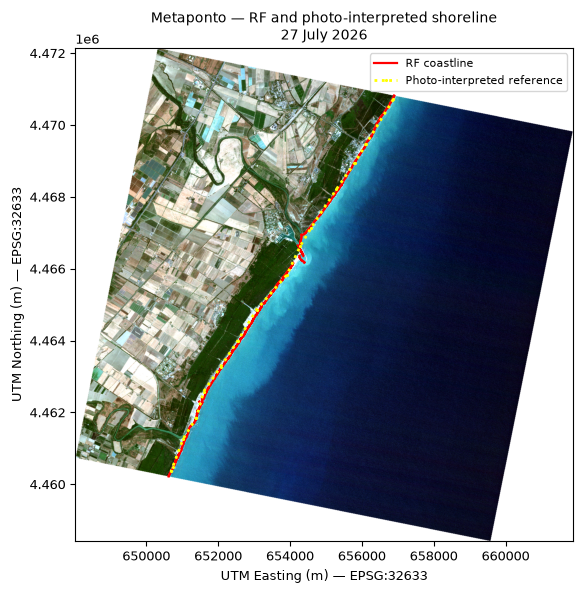

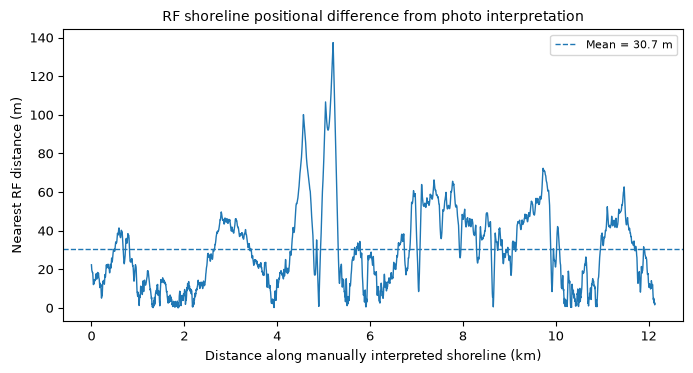


CODE 9 COMPLETE

Saved manual reference:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\PhotoInterpreted_shoreline_20260727_EPSG32633.csv

Saved point-to-line distances:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\PhotoInterpretation_vs_RF_distances_20260727.csv

Saved comparison summary:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\PhotoInterpretation_vs_RF_summary.txt

Saved overlay figure:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\Figure_RF_vs_PhotoInterpretation_20260727.png

Saved distance profile:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\Figure_RF_PhotoInterpretation_distance_profile.png

The RF line was NOT displayed during manual digitization.


In [30]:
# ============================================================
# METAPONTO HAWK — 27 JULY 2026
# CODE 9
#
# INDEPENDENT MANUAL PHOTO-INTERPRETATION
# + RF SHORELINE POSITIONAL COMPARISON
#
# IMPORTANT:
# During manual digitization the RF coastline is HIDDEN.
#
# After ENTER:
#   - manual points are saved
#   - manual polyline is created
#   - RF coastline is loaded
#   - both are overlaid
#   - positional differences are calculated in metres
# ============================================================

from pathlib import Path
from PIL import Image, ImageTk
import tkinter as tk
import numpy as np
import matplotlib.pyplot as plt
import csv
from scipy.spatial import cKDTree


# ============================================================
# 1. PATHS
# ============================================================

HAWK_DIR = (
    Path.home()
    / "Downloads"
    / "HAWK DATASET 27.7.26 METAPONTO"
)

OUTPUT_DIR = (
    Path.home()
    / "Downloads"
    / "Metaponto_Coastline_Project"
    / "HAWK_2026_RF"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RF_CSV = (
    OUTPUT_DIR
    / "RF_principal_coastline_20260727_EPSG32633.csv"
)

if not RF_CSV.exists():
    raise FileNotFoundError(
        "RF coastline from CODE 8 was not found."
    )


# ============================================================
# 2. HAWK GEOGRAPHIC GRID
# ============================================================

pixel_size = 2.5

left = 648023.75
top = 4472148.75

width = 5541
height = 5493

right = left + width * pixel_size
bottom = top - height * pixel_size


# ============================================================
# 3. LOAD ORIGINAL HAWK RGB
#
# RF RESULT IS NOT LOADED INTO THE DIGITIZING WINDOW.
# ============================================================

print("Loading original HAWK image...")

raw_rgb = {}

for band in ["B01", "B02", "B03"]:

    path = next(
        HAWK_DIR.glob(
            f"*.{band}.tif"
        )
    )

    with Image.open(path) as img:
        raw_rgb[band] = np.asarray(
            img
        ).copy()


# Original true colour:
# B03 = red
# B02 = green
# B01 = blue

rgb16 = np.stack(
    [
        raw_rgb["B03"],
        raw_rgb["B02"],
        raw_rgb["B01"]
    ],
    axis=-1
).astype(
    np.float32
)


# ============================================================
# 4. DISPLAY STRETCH
# ============================================================

rgb8 = np.zeros(
    rgb16.shape,
    dtype=np.uint8
)

for channel in range(3):

    data = rgb16[
        :,
        :,
        channel
    ]

    positive = data[
        data > 0
    ]

    low, high = np.percentile(
        positive[::20],
        [2, 98]
    )

    stretched = np.clip(
        (data - low)
        /
        max(
            high - low,
            1
        ),
        0,
        1
    )

    rgb8[
        :,
        :,
        channel
    ] = (
        stretched * 255
    ).astype(
        np.uint8
    )


valid_image = np.any(
    rgb16 > 0,
    axis=2
)

rgb8[
    ~valid_image
] = 255


source_image = Image.fromarray(
    rgb8,
    mode="RGB"
)


# Free large temporary array.
del rgb16


# ============================================================
# 5. MANUAL DIGITIZER
# ============================================================

print("\n" + "=" * 72)
print("MANUAL PHOTO-INTERPRETATION")
print("=" * 72)

print(
    "A separate window will open."
)

print(
    "Trace the visible shoreline on the ORIGINAL HAWK image."
)

print(
    "The RF coastline is intentionally hidden."
)


# Native image dimensions.
IMG_W = source_image.width
IMG_H = source_image.height


# Window display dimensions.
CANVAS_W = 900
CANVAS_H = 890


# Manual clicked points are stored as:
# (column, row)
manual_pixels = []


# Current viewport in source-image pixel coordinates.
view = {
    "left": 0.0,
    "top": 0.0,
    "width": float(IMG_W),
    "height": float(IMG_H)
}


root = tk.Tk()

root.title(
    "Metaponto 27 July 2026 — Manual Shoreline Photo-Interpretation"
)

root.geometry(
    f"{CANVAS_W + 20}x{CANVAS_H + 110}"
)


instruction = tk.Label(
    root,
    text=(
        "TRACE SOUTH → NORTH | "
        "Left click = add point | "
        "Mouse wheel = zoom | "
        "Right-drag = pan | "
        "Backspace/U = undo | "
        "ENTER = finish"
    ),
    font=("Arial", 10, "bold")
)

instruction.pack(
    pady=4
)


canvas = tk.Canvas(
    root,
    width=CANVAS_W,
    height=CANVAS_H,
    background="black",
    cursor="crosshair"
)

canvas.pack()


status_var = tk.StringVar()

status_var.set(
    "RF coastline is hidden. Zoom in and begin at the southern end."
)


status_label = tk.Label(
    root,
    textvariable=status_var,
    anchor="w",
    font=("Consolas", 9)
)

status_label.pack(
    fill="x",
    padx=5,
    pady=4
)


tk_image = None

pan_start = None


# ------------------------------------------------------------
# Coordinate helpers
# ------------------------------------------------------------

def clamp_view():
    """
    Keep viewport inside original image.
    """

    if view["width"] > IMG_W:
        view["width"] = float(IMG_W)

    if view["height"] > IMG_H:
        view["height"] = float(IMG_H)

    view["left"] = max(
        0.0,
        min(
            view["left"],
            IMG_W - view["width"]
        )
    )

    view["top"] = max(
        0.0,
        min(
            view["top"],
            IMG_H - view["height"]
        )
    )


def screen_to_source(
    sx,
    sy
):
    """
    Screen pixel -> original HAWK image pixel.
    """

    col = (
        view["left"]
        +
        sx / CANVAS_W
        *
        view["width"]
    )

    row = (
        view["top"]
        +
        sy / CANVAS_H
        *
        view["height"]
    )

    return col, row


def source_to_screen(
    col,
    row
):
    """
    Original HAWK pixel -> screen location.
    """

    sx = (
        col - view["left"]
    ) / view["width"] * CANVAS_W

    sy = (
        row - view["top"]
    ) / view["height"] * CANVAS_H

    return sx, sy


def pixel_to_utm(
    col,
    row
):
    """
    Pixel centre -> UTM coordinate.
    """

    x = (
        left
        +
        (
            col + 0.5
        )
        *
        pixel_size
    )

    y = (
        top
        -
        (
            row + 0.5
        )
        *
        pixel_size
    )

    return x, y


# ------------------------------------------------------------
# Render image + clicked points
# ------------------------------------------------------------

def render():

    global tk_image

    clamp_view()

    x0 = int(
        round(view["left"])
    )

    y0 = int(
        round(view["top"])
    )

    x1 = int(
        round(
            view["left"]
            +
            view["width"]
        )
    )

    y1 = int(
        round(
            view["top"]
            +
            view["height"]
        )
    )

    x0 = max(
        0,
        min(
            IMG_W - 1,
            x0
        )
    )

    y0 = max(
        0,
        min(
            IMG_H - 1,
            y0
        )
    )

    x1 = max(
        x0 + 1,
        min(
            IMG_W,
            x1
        )
    )

    y1 = max(
        y0 + 1,
        min(
            IMG_H,
            y1
        )
    )

    crop = source_image.crop(
        (
            x0,
            y0,
            x1,
            y1
        )
    )

    crop = crop.resize(
        (
            CANVAS_W,
            CANVAS_H
        ),
        Image.Resampling.LANCZOS
    )

    tk_image = ImageTk.PhotoImage(
        crop
    )

    canvas.delete(
        "all"
    )

    canvas.create_image(
        0,
        0,
        anchor="nw",
        image=tk_image
    )


    # Draw manual line.
    if len(manual_pixels) >= 2:

        line_coordinates = []

        for col, row in manual_pixels:

            sx, sy = source_to_screen(
                col,
                row
            )

            line_coordinates.extend(
                [
                    sx,
                    sy
                ]
            )

        canvas.create_line(
            *line_coordinates,
            fill="yellow",
            width=2
        )


    # Draw clicked points.
    for number, (
        col,
        row
    ) in enumerate(
        manual_pixels,
        start=1
    ):

        sx, sy = source_to_screen(
            col,
            row
        )

        radius = 3

        canvas.create_oval(
            sx - radius,
            sy - radius,
            sx + radius,
            sy + radius,
            fill="yellow",
            outline="black"
        )


# ------------------------------------------------------------
# Add manual point
# ------------------------------------------------------------

def add_point(
    event
):

    col_float, row_float = screen_to_source(
        event.x,
        event.y
    )

    col = int(
        round(
            col_float
        )
    )

    row = int(
        round(
            row_float
        )
    )

    col = max(
        0,
        min(
            IMG_W - 1,
            col
        )
    )

    row = max(
        0,
        min(
            IMG_H - 1,
            row
        )
    )


    # Reject clicks outside real HAWK footprint.
    if not valid_image[
        row,
        col
    ]:

        status_var.set(
            "Outside valid HAWK footprint — point NOT added."
        )

        return


    manual_pixels.append(
        (
            col,
            row
        )
    )


    x, y = pixel_to_utm(
        col,
        row
    )


    status_var.set(
        f"Point {len(manual_pixels)} | "
        f"row={row}, col={col} | "
        f"E={x:.2f} m | "
        f"N={y:.2f} m"
    )

    render()


# ------------------------------------------------------------
# Cursor coordinate information
# ------------------------------------------------------------

def cursor_info(
    event
):

    col_float, row_float = screen_to_source(
        event.x,
        event.y
    )

    col = int(
        np.clip(
            round(col_float),
            0,
            IMG_W - 1
        )
    )

    row = int(
        np.clip(
            round(row_float),
            0,
            IMG_H - 1
        )
    )

    x, y = pixel_to_utm(
        col,
        row
    )

    status_var.set(
        f"Cursor | "
        f"row={row}, col={col} | "
        f"E={x:.2f} m | "
        f"N={y:.2f} m | "
        f"points={len(manual_pixels)}"
    )


# ------------------------------------------------------------
# Zoom
# ------------------------------------------------------------

def zoom(
    event
):

    old_col, old_row = screen_to_source(
        event.x,
        event.y
    )


    if event.delta > 0:
        factor = 1.5
    else:
        factor = 1 / 1.5


    new_width = (
        view["width"]
        /
        factor
    )

    new_height = (
        view["height"]
        /
        factor
    )


    # Maximum zoom.
    minimum_width = IMG_W / 30
    minimum_height = IMG_H / 30


    new_width = max(
        minimum_width,
        min(
            float(IMG_W),
            new_width
        )
    )

    new_height = max(
        minimum_height,
        min(
            float(IMG_H),
            new_height
        )
    )


    rel_x = (
        event.x
        /
        CANVAS_W
    )

    rel_y = (
        event.y
        /
        CANVAS_H
    )


    view["left"] = (
        old_col
        -
        rel_x
        *
        new_width
    )

    view["top"] = (
        old_row
        -
        rel_y
        *
        new_height
    )

    view["width"] = new_width
    view["height"] = new_height


    render()


# ------------------------------------------------------------
# Right-drag pan
# ------------------------------------------------------------

def start_pan(
    event
):

    global pan_start

    pan_start = (
        event.x,
        event.y,
        view["left"],
        view["top"]
    )


def finish_pan(
    event
):

    global pan_start

    if pan_start is None:
        return


    start_x, start_y, old_left, old_top = (
        pan_start
    )


    dx = (
        event.x
        -
        start_x
    )

    dy = (
        event.y
        -
        start_y
    )


    view["left"] = (
        old_left
        -
        dx / CANVAS_W
        *
        view["width"]
    )

    view["top"] = (
        old_top
        -
        dy / CANVAS_H
        *
        view["height"]
    )


    pan_start = None

    render()


# ------------------------------------------------------------
# Undo
# ------------------------------------------------------------

def undo(
    event=None
):

    if len(
        manual_pixels
    ) > 0:

        manual_pixels.pop()

        status_var.set(
            f"Last point removed. "
            f"Points remaining: "
            f"{len(manual_pixels)}"
        )

        render()


# ------------------------------------------------------------
# Finish
# ------------------------------------------------------------

def finish(
    event=None
):

    if len(
        manual_pixels
    ) < 10:

        status_var.set(
            "Please digitize at least 10 shoreline points before finishing."
        )

        return

    root.destroy()


# Bind controls.
canvas.bind(
    "<Button-1>",
    add_point
)

canvas.bind(
    "<Motion>",
    cursor_info
)

canvas.bind(
    "<MouseWheel>",
    zoom
)

canvas.bind(
    "<ButtonPress-3>",
    start_pan
)

canvas.bind(
    "<ButtonRelease-3>",
    finish_pan
)

root.bind(
    "<BackSpace>",
    undo
)

root.bind(
    "u",
    undo
)

root.bind(
    "U",
    undo
)

root.bind(
    "<Return>",
    finish
)


render()


# Bring window to front.
root.after(
    200,
    lambda: root.lift()
)

root.after(
    300,
    lambda: root.focus_force()
)


# Cell pauses here until ENTER is pressed.
root.mainloop()


# ============================================================
# 6. CONVERT MANUAL POINTS TO UTM
# ============================================================

if len(
    manual_pixels
) < 10:

    raise RuntimeError(
        "Manual shoreline was not completed."
    )


manual_cols = np.asarray(
    [
        point[0]
        for point in manual_pixels
    ],
    dtype=np.int32
)

manual_rows = np.asarray(
    [
        point[1]
        for point in manual_pixels
    ],
    dtype=np.int32
)


manual_x = (
    left
    +
    (
        manual_cols
        +
        0.5
    )
    *
    pixel_size
)

manual_y = (
    top
    -
    (
        manual_rows
        +
        0.5
    )
    *
    pixel_size
)


print("\nManual shoreline completed.")

print(
    "Number of manually clicked points:",
    len(manual_x)
)


# ============================================================
# 7. SAVE MANUAL PHOTO-INTERPRETATION POINTS
# ============================================================

MANUAL_CSV = (
    OUTPUT_DIR
    /
    "PhotoInterpreted_shoreline_20260727_EPSG32633.csv"
)


with open(
    MANUAL_CSV,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(
        f
    )

    writer.writerow([
        "point_id",
        "row",
        "column",
        "easting_m",
        "northing_m"
    ])

    for i, (
        row,
        col,
        x,
        y
    ) in enumerate(
        zip(
            manual_rows,
            manual_cols,
            manual_x,
            manual_y
        ),
        start=1
    ):

        writer.writerow([
            i,
            int(row),
            int(col),
            f"{x:.3f}",
            f"{y:.3f}"
        ])


print("\nManual shoreline saved:")
print(MANUAL_CSV)


# ============================================================
# 8. LOAD RF COASTLINE
# ============================================================

rf_x = []
rf_y = []


with open(
    RF_CSV,
    "r",
    encoding="utf-8"
) as f:

    reader = csv.DictReader(
        f
    )

    for row in reader:

        rf_x.append(
            float(
                row["easting_m"]
            )
        )

        rf_y.append(
            float(
                row["northing_m"]
            )
        )


rf_x = np.asarray(
    rf_x
)

rf_y = np.asarray(
    rf_y
)


# ============================================================
# 9. DENSIFY MANUAL POLYLINE
#
# Interpolate between clicked photo-interpretation points
# every approximately 2.5 m.
# ============================================================

def densify_polyline(
    x,
    y,
    spacing=2.5
):

    dense_points = []

    for i in range(
        len(x) - 1
    ):

        x1 = x[i]
        y1 = y[i]

        x2 = x[i + 1]
        y2 = y[i + 1]


        length = np.hypot(
            x2 - x1,
            y2 - y1
        )


        n = max(
            1,
            int(
                np.ceil(
                    length
                    /
                    spacing
                )
            )
        )


        t = np.linspace(
            0,
            1,
            n,
            endpoint=False
        )


        for ti in t:

            dense_points.append([
                x1
                +
                ti
                *
                (
                    x2 - x1
                ),

                y1
                +
                ti
                *
                (
                    y2 - y1
                )
            ])


    dense_points.append([
        x[-1],
        y[-1]
    ])


    return np.asarray(
        dense_points,
        dtype=np.float64
    )


manual_dense = densify_polyline(
    manual_x,
    manual_y,
    spacing=2.5
)


# ============================================================
# 10. POSITIONAL COMPARISON
#
# Distance from each densified manual shoreline point
# to nearest RF coastline point.
# ============================================================

rf_points = np.column_stack([
    rf_x,
    rf_y
])


rf_tree = cKDTree(
    rf_points
)


distances, nearest_index = (
    rf_tree.query(
        manual_dense
    )
)


mean_distance = float(
    np.mean(
        distances
    )
)

median_distance = float(
    np.median(
        distances
    )
)

rmse_distance = float(
    np.sqrt(
        np.mean(
            distances ** 2
        )
    )
)

p90_distance = float(
    np.percentile(
        distances,
        90
    )
)

p95_distance = float(
    np.percentile(
        distances,
        95
    )
)

max_distance = float(
    np.max(
        distances
    )
)


# ============================================================
# 11. ALONGSHORE DISTANCE
# ============================================================

manual_steps = np.sqrt(
    np.sum(
        np.diff(
            manual_dense,
            axis=0
        ) ** 2,
        axis=1
    )
)


alongshore = np.concatenate([
    [0.0],
    np.cumsum(
        manual_steps
    )
])


manual_length = float(
    alongshore[-1]
)


# ============================================================
# 12. RF GAP QUALITY CONTROL
# ============================================================

rf_steps = np.hypot(
    np.diff(
        rf_x
    ),
    np.diff(
        rf_y
    )
)


RF_GAP_THRESHOLD = 25.0


rf_gap_indices = np.where(
    rf_steps
    >
    RF_GAP_THRESHOLD
)[0]


print("\n" + "=" * 72)
print("PHOTO-INTERPRETATION VS RF")
print("=" * 72)

print(
    f"Manual clicked points: "
    f"{len(manual_x):,}"
)

print(
    f"Manual interpreted shoreline length: "
    f"{manual_length:.1f} m"
)

print(
    f"Mean distance:   "
    f"{mean_distance:.2f} m"
)

print(
    f"Median distance: "
    f"{median_distance:.2f} m"
)

print(
    f"RMSE:            "
    f"{rmse_distance:.2f} m"
)

print(
    f"90th percentile: "
    f"{p90_distance:.2f} m"
)

print(
    f"95th percentile: "
    f"{p95_distance:.2f} m"
)

print(
    f"Maximum distance:"
    f" {max_distance:.2f} m"
)

print(
    f"RF gaps > {RF_GAP_THRESHOLD:.0f} m: "
    f"{len(rf_gap_indices)}"
)

if len(
    rf_steps
) > 0:

    print(
        f"Largest RF point gap: "
        f"{rf_steps.max():.2f} m"
    )


# ============================================================
# 13. SAVE DISTANCES
# ============================================================

DISTANCE_CSV = (
    OUTPUT_DIR
    /
    "PhotoInterpretation_vs_RF_distances_20260727.csv"
)


with open(
    DISTANCE_CSV,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.writer(
        f
    )

    writer.writerow([
        "alongshore_m",
        "manual_easting_m",
        "manual_northing_m",
        "nearest_RF_distance_m"
    ])

    for s, (
        x,
        y
    ), d in zip(
        alongshore,
        manual_dense,
        distances
    ):

        writer.writerow([
            f"{s:.3f}",
            f"{x:.3f}",
            f"{y:.3f}",
            f"{d:.3f}"
        ])


# ============================================================
# 14. SAVE SUMMARY
# ============================================================

SUMMARY_PATH = (
    OUTPUT_DIR
    /
    "PhotoInterpretation_vs_RF_summary.txt"
)


with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "Metaponto HAWK — 27 July 2026\n"
    )

    f.write(
        "Independent photo-interpretation vs Random Forest\n\n"
    )

    f.write(
        f"Manual clicked points: {len(manual_x)}\n"
    )

    f.write(
        f"Manual shoreline length: "
        f"{manual_length:.3f} m\n"
    )

    f.write(
        f"Mean nearest distance: "
        f"{mean_distance:.3f} m\n"
    )

    f.write(
        f"Median nearest distance: "
        f"{median_distance:.3f} m\n"
    )

    f.write(
        f"RMSE: "
        f"{rmse_distance:.3f} m\n"
    )

    f.write(
        f"P90: "
        f"{p90_distance:.3f} m\n"
    )

    f.write(
        f"P95: "
        f"{p95_distance:.3f} m\n"
    )

    f.write(
        f"Maximum distance: "
        f"{max_distance:.3f} m\n"
    )

    f.write(
        f"RF gaps > {RF_GAP_THRESHOLD:.0f} m: "
        f"{len(rf_gap_indices)}\n"
    )


# ============================================================
# 15. COMPARISON FIGURE
#
# RF = solid RED
# Manual photo interpretation = dotted YELLOW
# ============================================================

# Small display version for plotting.
DISPLAY_STEP = 4

rgb_plot = rgb8[
    ::DISPLAY_STEP,
    ::DISPLAY_STEP
]


fig, ax = plt.subplots(
    figsize=(6.5, 6)
)


ax.imshow(
    rgb_plot,
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper"
)


# ------------------------------------------------------------
# Plot RF as separate segments so large gaps are NOT
# falsely connected by straight lines.
# ------------------------------------------------------------

split_positions = (
    rf_gap_indices
    +
    1
)


rf_segments_x = np.split(
    rf_x,
    split_positions
)

rf_segments_y = np.split(
    rf_y,
    split_positions
)


for i, (
    xs,
    ys
) in enumerate(
    zip(
        rf_segments_x,
        rf_segments_y
    )
):

    if len(
        xs
    ) < 2:
        continue

    ax.plot(
        xs,
        ys,
        color="red",
        linewidth=1.6,
        linestyle="-",
        label=(
            "RF coastline"
            if i == 0
            else None
        )
    )


# Manual reference line.
ax.plot(
    manual_x,
    manual_y,
    color="yellow",
    linewidth=2.0,
    linestyle=":",
    marker=".",
    markersize=2.5,
    label="Photo-interpreted reference"
)


ax.set_title(
    "Metaponto — RF and photo-interpreted shoreline\n"
    "27 July 2026"
)

ax.set_xlabel(
    "UTM Easting (m) — EPSG:32633"
)

ax.set_ylabel(
    "UTM Northing (m) — EPSG:32633"
)

ax.set_aspect(
    "equal"
)

ax.legend(
    loc="best"
)

fig.tight_layout()


OVERLAY_PATH = (
    OUTPUT_DIR
    /
    "Figure_RF_vs_PhotoInterpretation_20260727.png"
)


fig.savefig(
    OVERLAY_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. POSITIONAL-DIFFERENCE PROFILE
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 3.8)
)


ax.plot(
    alongshore / 1000,
    distances,
    linewidth=1.0
)


ax.axhline(
    mean_distance,
    linestyle="--",
    linewidth=1.0,
    label=f"Mean = {mean_distance:.1f} m"
)


ax.set_title(
    "RF shoreline positional difference from photo interpretation"
)

ax.set_xlabel(
    "Distance along manually interpreted shoreline (km)"
)

ax.set_ylabel(
    "Nearest RF distance (m)"
)

ax.legend()

fig.tight_layout()


PROFILE_PATH = (
    OUTPUT_DIR
    /
    "Figure_RF_PhotoInterpretation_distance_profile.png"
)


fig.savefig(
    PROFILE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. FINISH
# ============================================================

print("\n" + "=" * 72)
print("CODE 9 COMPLETE")
print("=" * 72)

print("\nSaved manual reference:")
print(MANUAL_CSV)

print("\nSaved point-to-line distances:")
print(DISTANCE_CSV)

print("\nSaved comparison summary:")
print(SUMMARY_PATH)

print("\nSaved overlay figure:")
print(OVERLAY_PATH)

print("\nSaved distance profile:")
print(PROFILE_PATH)

print(
    "\nThe RF line was NOT displayed during manual digitization."
)

Original LAND pixels: 8,072,265
Original SEA pixels:  13,861,053

Erosion distance: 300 m
Erosion radius: 120 pixels

ERODED TRAINING MASKS
Reliable LAND pixels: 6,548,831
Reliable SEA pixels:  12,065,897
LAND/SEA overlap: 0 pixels

CHECK PASSED: eroded LAND and SEA masks do not overlap.


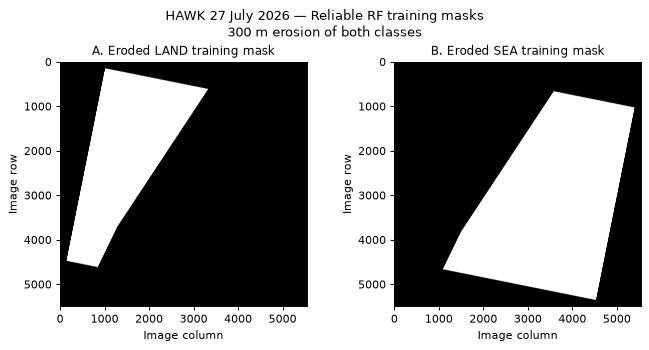


Saved:
C:\Users\faiza\Downloads\Metaponto_Coastline_Project\HAWK_2026_RF\Figure_Eroded_Land_Sea_Training_Masks.png


In [6]:
# ============================================================
# CODE 9B
# FINAL CHECK OF SEPARATE ERODED LAND AND SEA MASKS
#
# This does NOT retrain Random Forest.
# This does NOT change previous results.
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

OUTPUT_DIR = (
    Path.home()
    / "Downloads"
    / "Metaponto_Coastline_Project"
    / "HAWK_2026_RF"
)

GT_PATH = (
    OUTPUT_DIR
    / "GT_raw_NaturalEarth_HAWK_20260727.npy"
)

GT_raw = np.load(GT_PATH)

# ------------------------------------------------------------
# 1. ORIGINAL SEPARATE MASKS
# ------------------------------------------------------------

land_mask = (GT_raw == 1)
sea_mask  = (GT_raw == 0)

print("Original LAND pixels:", f"{land_mask.sum():,}")
print("Original SEA pixels: ", f"{sea_mask.sum():,}")


# ------------------------------------------------------------
# 2. EROSION
#
# 300 m / 2.5 m = 120 pixels
# Same training-buffer principle used in CODE 7.
# ------------------------------------------------------------

EROSION_DISTANCE_M = 300
PIXEL_SIZE_M = 2.5

erosion_pixels = int(
    round(
        EROSION_DISTANCE_M
        /
        PIXEL_SIZE_M
    )
)

print("\nErosion distance:", EROSION_DISTANCE_M, "m")
print("Erosion radius:", erosion_pixels, "pixels")


# Euclidean-distance erosion:
# retain pixels whose distance from the opposite/background
# is greater than the selected erosion distance.

land_distance = ndimage.distance_transform_edt(
    land_mask
)

sea_distance = ndimage.distance_transform_edt(
    sea_mask
)

land_eroded = (
    land_mask
    &
    (land_distance > erosion_pixels)
)

sea_eroded = (
    sea_mask
    &
    (sea_distance > erosion_pixels)
)


# ------------------------------------------------------------
# 3. OVERLAP CHECK
# ------------------------------------------------------------

overlap = (
    land_eroded
    &
    sea_eroded
)

n_overlap = int(
    overlap.sum()
)


print("\n" + "=" * 60)
print("ERODED TRAINING MASKS")
print("=" * 60)

print(
    "Reliable LAND pixels:",
    f"{land_eroded.sum():,}"
)

print(
    "Reliable SEA pixels: ",
    f"{sea_eroded.sum():,}"
)

print(
    "LAND/SEA overlap:",
    f"{n_overlap:,}",
    "pixels"
)


if n_overlap == 0:

    print(
        "\nCHECK PASSED: "
        "eroded LAND and SEA masks do not overlap."
    )

else:

    print(
        "\nWARNING: overlap detected."
    )


# ------------------------------------------------------------
# 4. FIGURE — TWO SEPARATE MASKS
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8, 4)
)

axes[0].imshow(
    land_eroded,
    cmap="gray",
    origin="upper"
)

axes[0].set_title(
    "A. Eroded LAND training mask"
)

axes[1].imshow(
    sea_eroded,
    cmap="gray",
    origin="upper"
)

axes[1].set_title(
    "B. Eroded SEA training mask"
)

for ax in axes:
    ax.set_xlabel("Image column")
    ax.set_ylabel("Image row")

fig.suptitle(
    "HAWK 27 July 2026 — Reliable RF training masks\n"
    "300 m erosion of both classes"
)

fig.tight_layout()

MASK_FIGURE = (
    OUTPUT_DIR
    / "Figure_Eroded_Land_Sea_Training_Masks.png"
)

fig.savefig(
    MASK_FIGURE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(MASK_FIGURE)

Found 3 files; SIGN_FACTOR=+1; verify baseline orientation


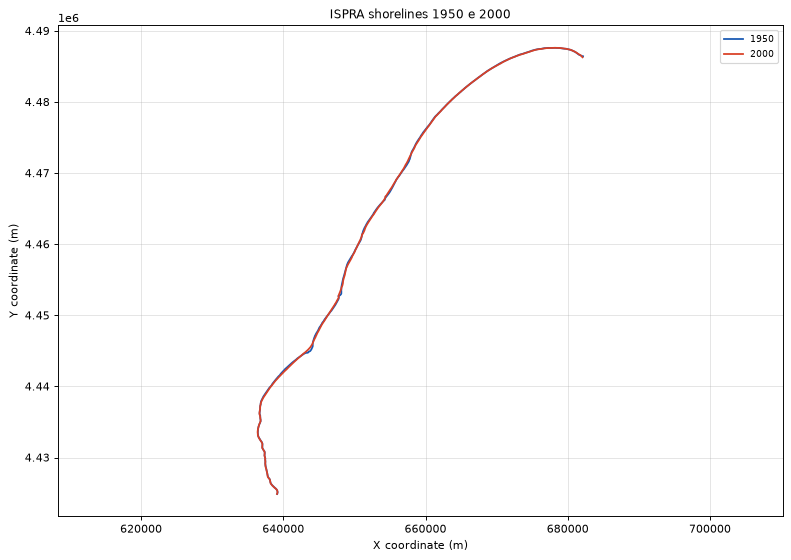

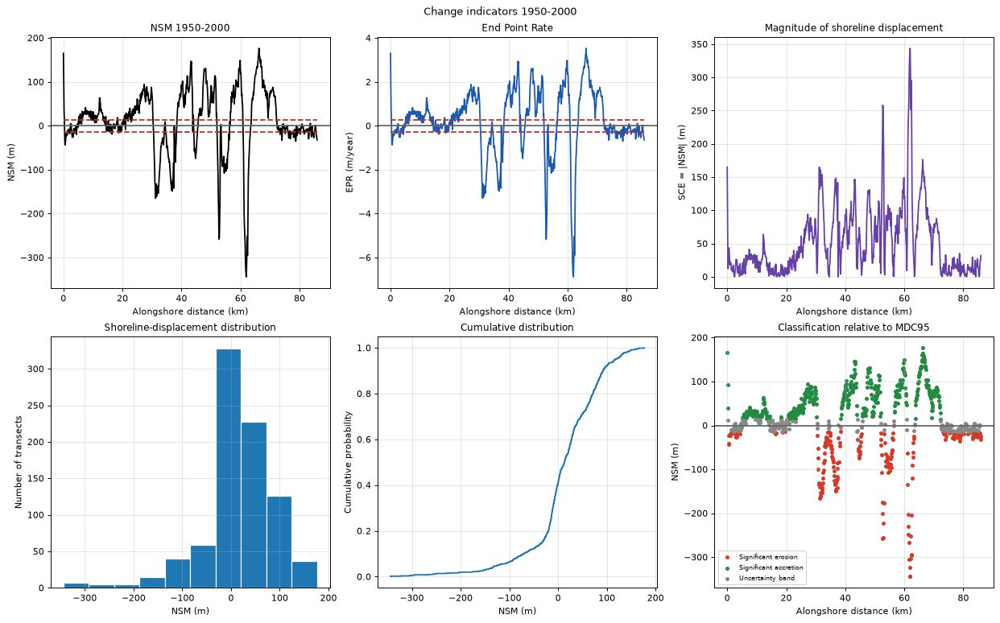

TRANS_17_intersect_1950_2000.xlsx: 850 transects; mean NSM=12.083 m; mean EPR=0.2417 m/year


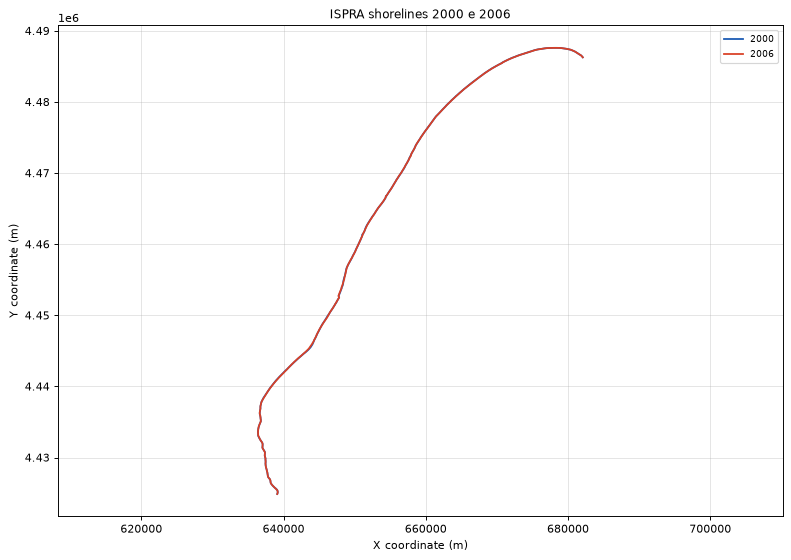

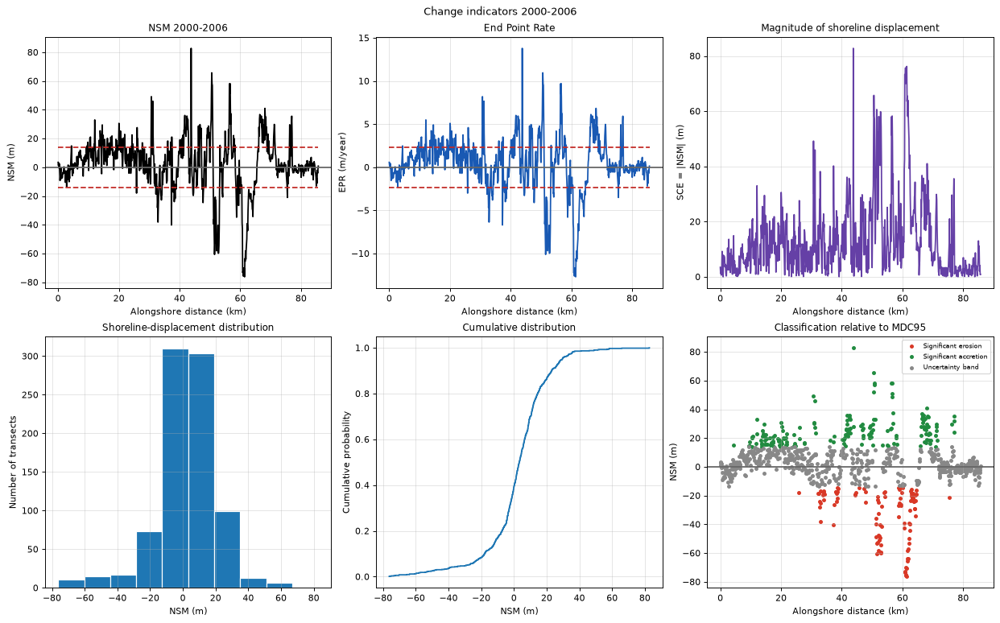

TRANS_17_intersect_2000_2006.xlsx: 850 transects; mean NSM=2.388 m; mean EPR=0.3980 m/year


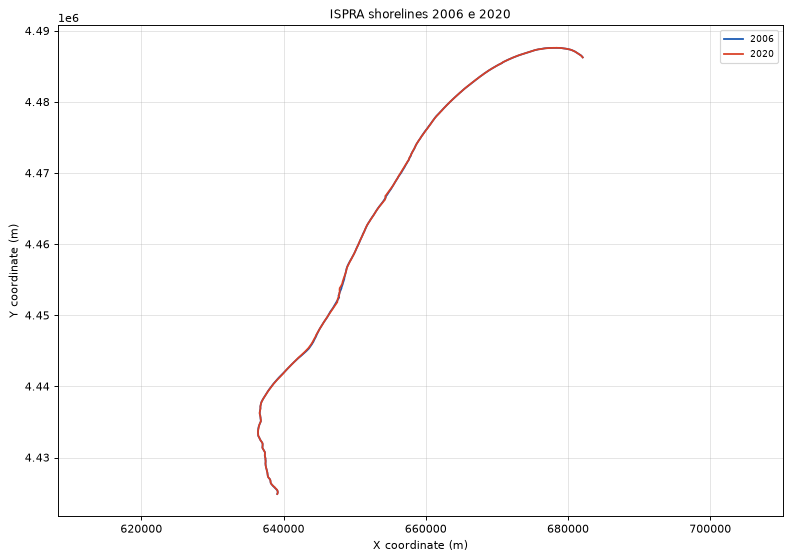

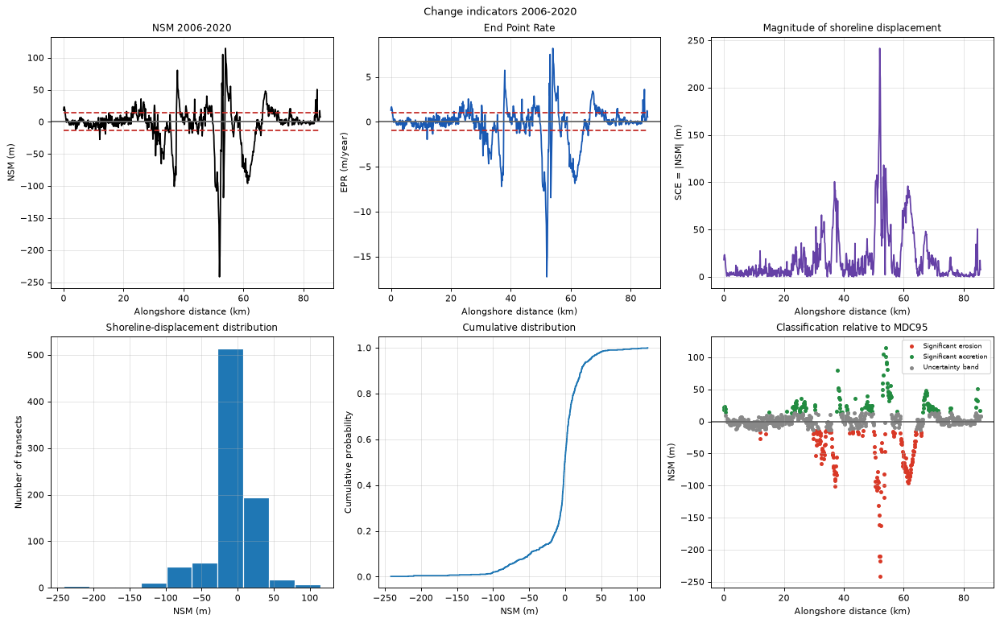

TRANS_17_intersect_2006_2020.xlsx: 850 transects; mean NSM=-5.360 m; mean EPR=-0.3829 m/year


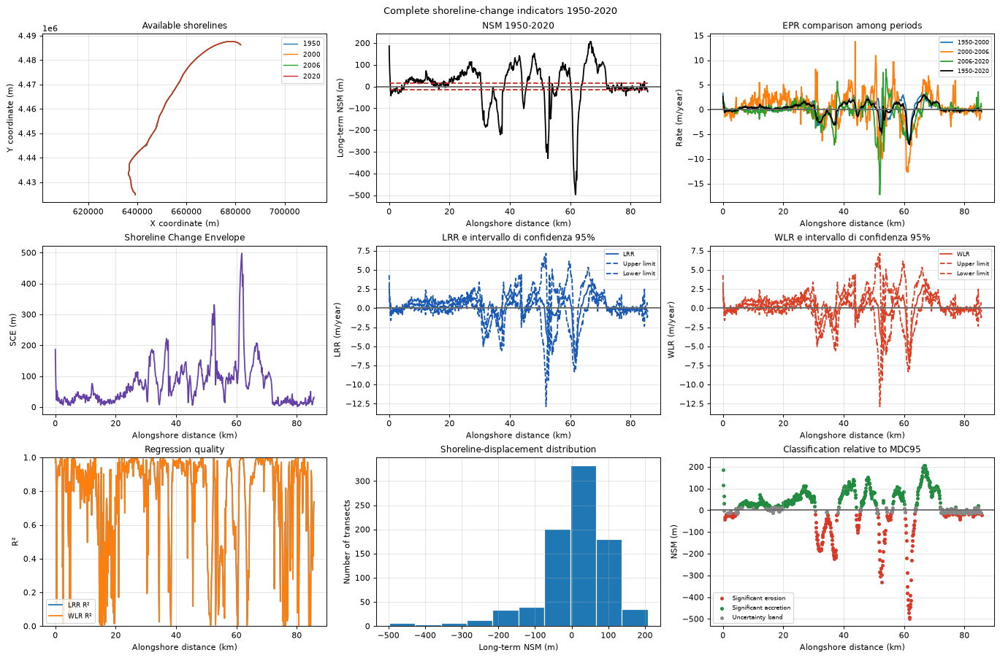

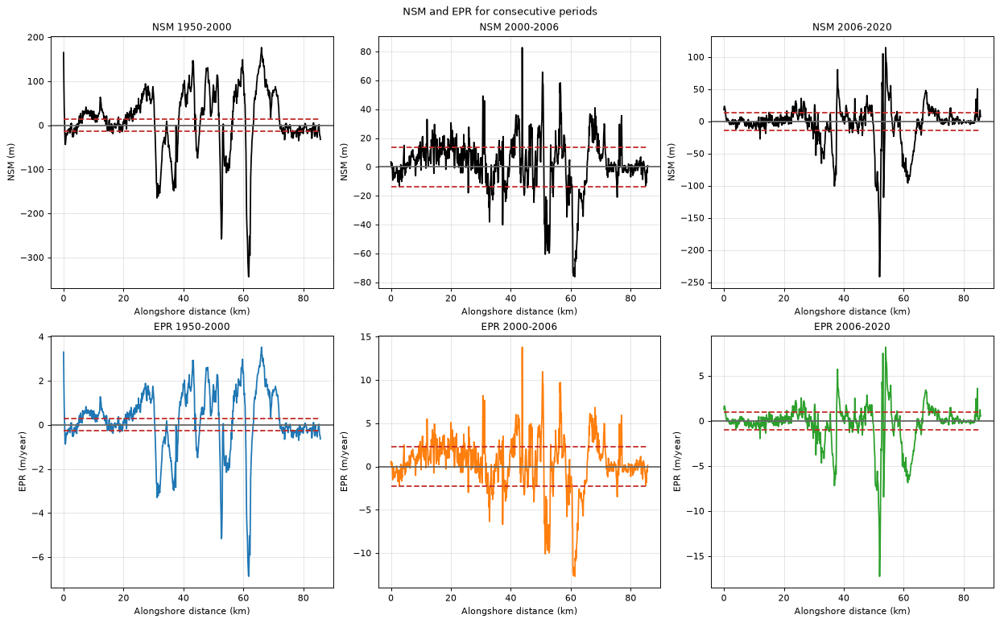

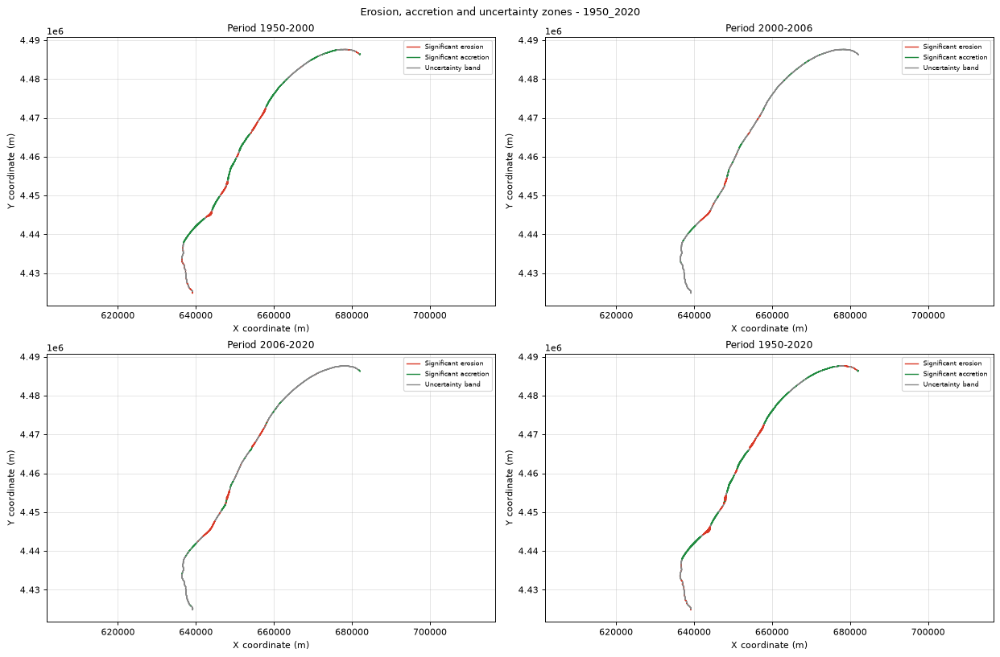

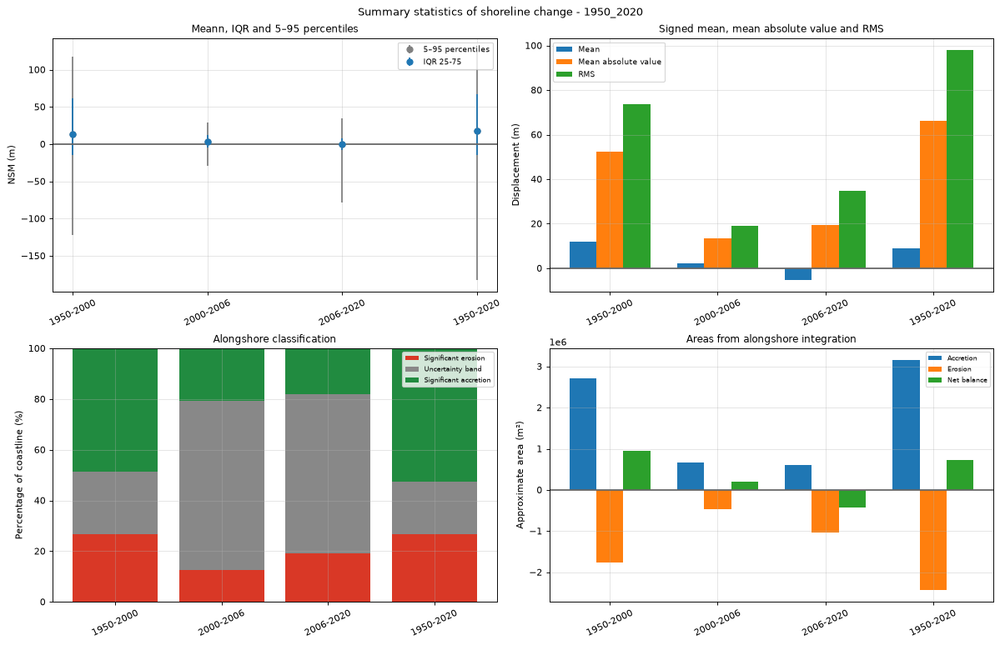

Combined analysis: years [1950, 2000, 2006, 2020], 850 common transects
Analysis completed. Results: C:\Users\faiza\Downloads\Risultati_linee_riva

27 JULY 2026 SHORELINE COMPARISON EXTENSION
RF 2026 shoreline points: 4,242
Photo-interpreted 2026 points: 15
Historical ISPRA years loaded: [1950, 2000, 2006, 2020]


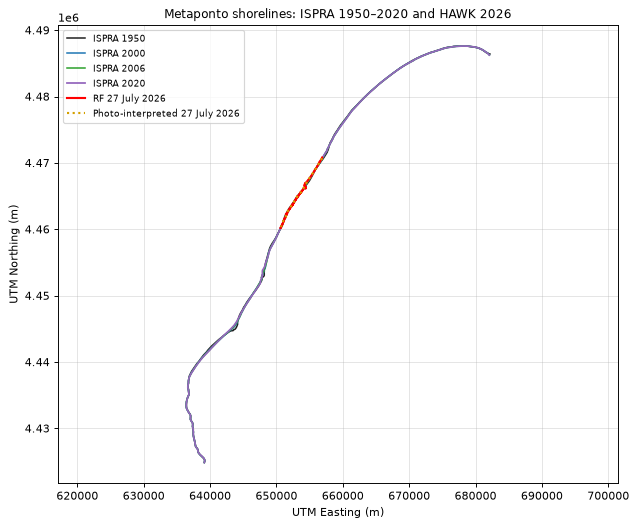

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


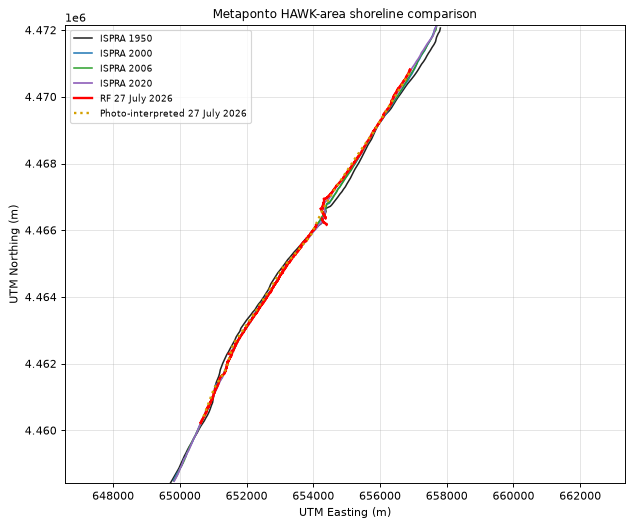

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


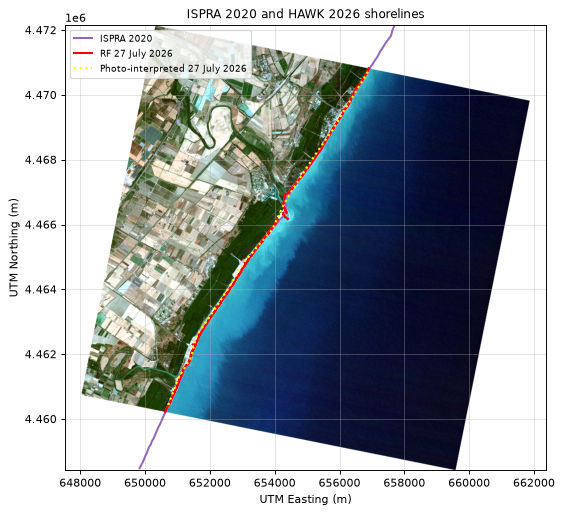


Final 2026 comparison products saved in:
C:\Users\faiza\Downloads\Risultati_linee_riva\Comparison_with_27July2026

Created:
 - Final_all_shorelines_1950_2026.png
 - Final_HAWK_area_shorelines_1950_2026.png
 - Final_2020_vs_2026_over_HAWK.png
 - Final_shoreline_comparison_1950_2026.xlsx
 - Methodological_note_2026_extension.txt

IMPORTANT: the original historical change calculations have not been altered.
The 2026 lines are added for validation and georeferenced comparison only.


In [7]:
"""English-label version of the professor\'s Python conversion of analisi_linee_riva.m for Jupyter / Python 3.

Processes all TRANS_*_intersect_*.xls* files; creates Risultati_linee_riva/

with pair and combined Excel results and PNG figures.

"""



from pathlib import Path

import warnings

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import t as student_t





# ============================================================

# CONFIGURATION

# ============================================================



INPUT_FOLDER = Path(r"C:\Users\faiza\Downloads")



FILE_PATTERN = 'TRANS_*_intersect_*.xls*'



SIGN_FACTOR = +1  # Verify baseline orientation before interpreting erosion/accretion



USE_EXACT_DATES = False



UNCERTAINTY_YEARS = [1950, 2000, 2006, 2020]



# Assumed positional uncertainty of +/- 5 m for each shoreline year,

# following the professor's suggestion (not an official ISPRA accuracy).



UNCERTAINTY_VALUES = [5.0, 5.0, 5.0, 5.0]



UNCERTAINTY_LEVEL = 'standard'   # 'standard' or '95'



COORDINATE_TOLERANCE_M = 0.05



SHOW_FIGURES = True



SAVE_FIGURES = True



ZERO_TOLERANCE_M = 1e-9



OUTPUT_FOLDER = INPUT_FOLDER / 'Risultati_linee_riva'



COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']





# ============================================================

# UNCERTAINTY FUNCTIONS

# ============================================================



def lookup_uncertainty(years):



    mapping = dict(zip(UNCERTAINTY_YEARS, UNCERTAINTY_VALUES))



    return np.array(

        [mapping.get(int(y), np.nan) for y in np.atleast_1d(years)],

        float

    )





def combined_uncertainty95(u1, u2, delta_t):



    base = np.hypot(u1, u2)



    if UNCERTAINTY_LEVEL == 'standard':



        mdc = 1.96 * base



    elif UNCERTAINTY_LEVEL == '95':



        mdc = base



    else:



        raise ValueError("UNCERTAINTY_LEVEL must be 'standard' or '95'")



    return mdc, mdc / delta_t





# ============================================================

# DISTANCE AND STATISTICS

# ============================================================



def cumulative_distance(x, y):



    return np.r_[0., np.cumsum(np.hypot(np.diff(x), np.diff(y)))]





def representative_weights(s):



    if len(s) == 1:



        return np.array([np.nan])



    d = np.diff(s)



    weights = np.empty(len(s))



    weights[0], weights[-1] = d[0] / 2, d[-1] / 2



    if len(s) > 2:



        weights[1:-1] = (d[:-1] + d[1:]) / 2



    return weights





def summary_stats(values):



    x = np.asarray(values, float)



    x = x[np.isfinite(x)]



    names = [

        'Mean', 'Meann', 'StandardDeviation',

        'Minimum', 'Maximum',

        'Percentile05', 'Percentile25',

        'Percentile75', 'Percentile95',

        'InterquartileRange',

        'MeanAbsoluteValue', 'RMS',

        'Skewness', 'ExcessKurtosis'

    ]



    if not len(x):



        return dict(zip(names, [np.nan] * len(names)))



    p = np.percentile(x, [5, 25, 75, 95], method='linear')



    mu = x.mean()



    sigma = np.sqrt(np.mean((x-x.mean())**2))



    skew = np.mean(((x-mu)/sigma)**3) if sigma else 0.



    kurt = np.mean(((x-mu)/sigma)**4)-3 if sigma else 0.



    results = [

        mu,

        np.median(x),

        np.std(x, ddof=1) if len(x)>1 else np.nan,

        x.min(),

        x.max(),

        *p,

        p[2]-p[1],

        np.mean(abs(x)),

        np.sqrt(np.mean(x*x)),

        skew,

        kurt

    ]



    return dict(zip(names, results))





def metric_row(values, indicator, period, unit):



    return {

        'Indicator': indicator,

        'Period': period,

        'Unit': unit,

        'NumberOfValues': int(np.isfinite(values).sum()),

        **summary_stats(values)

    }





# ============================================================

# CLASSIFICATION

# ============================================================



def classify(nsm, mdc):



    nsm, mdc = (

        np.asarray(nsm, float),

        np.broadcast_to(mdc, np.shape(nsm))

    )



    direct = np.full(nsm.shape, 'Zero', dtype=object)



    direct[nsm > ZERO_TOLERANCE_M] = 'Accretion'



    direct[nsm < -ZERO_TOLERANCE_M] = 'Erosion'



    direct[~np.isfinite(nsm)] = 'Not available'



    significance = np.full(

        nsm.shape,

        'Uncertainty unavailable',

        dtype=object

    )



    valid = np.isfinite(nsm) & np.isfinite(mdc)



    significance[valid] = "Indistinguishable from uncertainty"



    significance[valid & (nsm > mdc)] = 'Significant accretion'



    significance[valid & (nsm < -mdc)] = 'Significant erosion'



    return direct, significance





def classification_summary(nsm, mdc, weights, period):



    total = len(nsm)



    valid = np.isfinite(nsm)



    x = np.asarray(nsm)[valid]



    u = np.asarray(mdc)[valid]



    w = np.asarray(weights)[valid]



    n = len(x)



    acc, ero, zero = x>0, x<0, x==0



    known = n > 0 and np.isfinite(u).all()



    sig_acc, sig_ero = x>u, x < -u



    uncertain = ~(sig_acc | sig_ero)



    good_w = n>0 and np.isfinite(w).all() and sum(w)>0



    r = dict(

        Period=period,

        NumberOfTransects=total,

        NumberOfValidValues=n,

        CountAccretion=sum(acc),

        CountErosion=sum(ero),

        CountZero=sum(zero),

        PctAccretion=100*sum(acc)/n if n else np.nan,

        PctErosion=100*sum(ero)/n if n else np.nan,

        PctZero=100*sum(zero)/n if n else np.nan

    )



    for name, mask in [

        ('Accretion', sig_acc),

        ('Erosion', sig_ero),

        ('Uncertain', uncertain)

    ]:



        r['Count'+('Significant' if name!='Uncertain' else '')+name] = (

            int(sum(mask)) if known else np.nan

        )



        r['Pct'+('Significant' if name!='Uncertain' else '')+name] = (

            100*sum(mask)/n if known else np.nan

        )



    for name, mask in [

        ('Accretion',acc),

        ('Erosion',ero),

        ('Zero',zero),

        ('SignificantAccretion',sig_acc),

        ('SignificantErosion',sig_ero),

        ('Uncertain',uncertain)

    ]:



        r['PctCoast'+name] = (

            100*w[mask].sum()/w.sum()

            if good_w and (

                known or

                'Significant' not in name and name!='Uncertain'

            )

            else np.nan

        )



    return r





def area_row(nsm, s, period):



    r = {'Period': period}



    for name, vals in [

        ('ApproxAccretionArea_m2', np.maximum(nsm,0)),

        ('ApproxErosionArea_m2', np.maximum(-nsm,0)),

        ('ApproxNetArea_m2', nsm)

    ]:



        r[name] = np.trapezoid(vals, s) if len(s)>1 else np.nan



    return r





# ============================================================

# PAIR SUMMARY

# ============================================================



def pair_summary(r, coast_weights, old_year, new_year):



    x = r.NSM_m.to_numpy()



    rate = r.EPR_m_per_year.to_numpy()



    q, qr = summary_stats(x), summary_stats(rate)



    known = r.MDC95_m.notna().all()



    n = len(r)



    u = r.MDC95_m.to_numpy()



    sa, se = (x>u).sum(), (x< -u).sum()



    w = coast_weights



    valid_w = n>1 and np.isfinite(w).all() and w.sum()>0



    ret = dict(

        OlderYear=old_year,

        RecentYear=new_year,



        Interval_years=np.median(r.DeltaT_years),



        NumberOfTransects=n,



        MeanNSM_m=q['Mean'],

        MeannNSM_m=q['Meann'],

        StdNSM_m=q['StandardDeviation'],



        MinNSM_m=q['Minimum'],

        MaxNSM_m=q['Maximum'],



        P05_NSM_m=q['Percentile05'],

        P25_NSM_m=q['Percentile25'],

        P75_NSM_m=q['Percentile75'],

        P95_NSM_m=q['Percentile95'],



        IQR_NSM_m=q['InterquartileRange'],



        MeanAbsoluteNSM_m=q['MeanAbsoluteValue'],



        RMS_NSM_m=q['RMS'],



        Skewness_NSM=q['Skewness'],



        ExcessKurtosis_NSM=q['ExcessKurtosis'],



        MeanEPR_m_per_year=qr['Mean'],

        MeannEPR_m_per_year=qr['Meann'],



        StdEPR_m_per_year=qr['StandardDeviation'],



        MinEPR_m_per_year=qr['Minimum'],

        MaxEPR_m_per_year=qr['Maximum'],



        P05_EPR_m_per_year=qr['Percentile05'],

        P25_EPR_m_per_year=qr['Percentile25'],



        P75_EPR_m_per_year=qr['Percentile75'],

        P95_EPR_m_per_year=qr['Percentile95'],



        IQR_EPR_m_per_year=qr['InterquartileRange'],



        MeanAbsoluteEPR_m_per_year=qr['MeanAbsoluteValue'],



        RMS_EPR_m_per_year=qr['RMS'],



        Skewness_EPR=qr['Skewness'],



        ExcessKurtosis_EPR=qr['ExcessKurtosis'],



        CountAccretion=int(sum(x>0)),

        CountErosion=int(sum(x<0)),



        CountZero=int(sum(x==0)),



        PctAccretion=100*sum(x>0)/n,

        PctErosion=100*sum(x<0)/n,



        PctZero=100*sum(x==0)/n,



        CountSignificantAccretion=int(sa) if known else np.nan,



        CountSignificantErosion=int(se) if known else np.nan,



        CountUncertainStable=int(n-sa-se) if known else np.nan,



        PctSignificantAccretion=100*sa/n if known else np.nan,



        PctSignificantErosion=100*se/n if known else np.nan,



        PctUncertainStable=100*(n-sa-se)/n if known else np.nan,



        ApproxCoastLength_m=r.Alongshore_m.max()-r.Alongshore_m.min()

    )



    for key, vals in [

        ('PctCoastAccretion', x>0),

        ('PctCoastErosion',x<0),

        ('PctCoastZero',x==0)

    ]:



        ret[key] = 100*w[vals].sum()/w.sum() if valid_w else np.nan



    ret.update({

        k:v for k,v in area_row(

            x,

            r.Alongshore_m.to_numpy(),

            'unused'

        ).items()

        if k!='Period'

    })



    return ret





# ============================================================

# FIGURE FUNCTIONS

# ============================================================



def save_fig(fig, name):



    if SAVE_FIGURES:



        fig.savefig(

            OUTPUT_FOLDER/name,

            dpi=300,

            bbox_inches='tight'

        )



    if SHOW_FIGURES:



        plt.show()



    else:



        plt.close(fig)





def setup(ax, xlabel=None, ylabel=None, title=None, equal=False):



    if xlabel:

        ax.set_xlabel(xlabel)



    if ylabel:

        ax.set_ylabel(ylabel)



    if title:

        ax.set_title(title)



    ax.grid(True, alpha=.35)



    if equal:

        ax.set_aspect('equal', adjustable='datalim')





def change_class_plot(ax, s, x, mdc):



    known=np.isfinite(mdc).all()



    threshold=mdc if known else np.zeros_like(x)



    masks=(

        x < -threshold,

        x>threshold,

        (x>=-threshold)&(x<=threshold)

    )



    labels=(

        [

            'Significant erosion',

            'Significant accretion',

            'Uncertainty band'

        ]

        if known

        else [

            'Erosion',

            'Accretion',

            'Zero'

        ]

    )



    for mask,col,label in zip(

        masks,

        ['#d93826','#218b40','#888888'],

        labels

    ):



        ax.scatter(

            s[mask],

            x[mask],

            s=10,

            color=col,

            label=label

        )



    ax.axhline(0,color='0.4')



    ax.legend(fontsize=7)



    setup(

        ax,

        'Alongshore distance (km)',

        'NSM (m)',

        'Classification relative to MDC95'

        if known else 'Directional classification'

    )





# ============================================================

# PAIR FIGURES

# ============================================================



def pair_figures(r, y0, y1, tag):



    fig,ax=plt.subplots(figsize=(11,7.5))



    ax.plot(

        r.XOlder_m,

        r.YOlder_m,

        color='#1959b3',

        lw=1.5,

        label=str(y0)

    )



    ax.plot(

        r.XRecent_m,

        r.YRecent_m,

        color='#d94026',

        lw=1.5,

        label=str(y1)

    )



    setup(

        ax,

        'X coordinate (m)',

        'Y coordinate (m)',

        f'ISPRA shorelines {y0} e {y1}',

        True

    )



    ax.legend()



    save_fig(fig, f'linee_riva_{tag}.png')



    fig, axes=plt.subplots(

        2,3,

        figsize=(14.5,9),

        layout='constrained'

    )



    axs=axes.flat



    s=r.Alongshore_m.to_numpy()/1000



    x=r.NSM_m.to_numpy()



    rate=r.EPR_m_per_year.to_numpy()



    mdc=r.MDC95_m.to_numpy()



    rate_u=r.EPRunc95_m_per_year.to_numpy()



    for ax,v,unc,title,ylabel in [

        (axs[0],x,mdc,f'NSM {y0}-{y1}','NSM (m)'),

        (axs[1],rate,rate_u,'End Point Rate','EPR (m/year)')

    ]:



        ax.plot(

            s,v,

            color='k' if ax==axs[0] else '#1959b3'

        )



        ax.axhline(0,color='.4')



        if np.isfinite(unc).all():



            ax.plot(s,unc,'--',color='#c32a26')



            ax.plot(s,-unc,'--',color='#c32a26')



        setup(

            ax,

            'Alongshore distance (km)',

            ylabel,

            title

        )



    axs[2].plot(s,r.SCE_m,color='#6540a6')



    setup(

        axs[2],

        'Alongshore distance (km)',

        'SCE = |NSM| (m)',

        'Magnitude of shoreline displacement'

    )



    axs[3].hist(x,edgecolor='white')



    setup(

        axs[3],

        'NSM (m)',

        'Number of transects',

        'Shoreline-displacement distribution'

    )



    sx=np.sort(x[np.isfinite(x)])



    axs[4].step(

        sx,

        np.arange(1,len(sx)+1)/len(sx),

        where='post'

    )



    setup(

        axs[4],

        'NSM (m)',

        'Cumulative probability',

        'Cumulative distribution'

    )



    change_class_plot(

        axs[5],

        s,

        x,

        mdc

    )



    fig.suptitle(

        f'Change indicators {y0}-{y1}'

    )



    save_fig(fig,f'indici_{tag}.png')





# ============================================================

# READ EXCEL FILES

# ============================================================



def read_pair(path):



    t=pd.read_excel(path)



    names={

        'TransectId':'TransectId',

        'ShorelineId':'Date',

        'Distance':'Distance_m',

        'IntersectX':'X_m',

        'IntersectY':'Y_m'

    }



    missing=set(names)-set(t.columns)



    if missing:



        raise ValueError(

            f'{path.name}: missing columns {missing}'

        )



    p=t[list(names)].rename(columns=names).copy()



    p['Date']=pd.to_datetime(

        p['Date'],

        dayfirst=True,

        errors='coerce'

    )



    for c in [

        'TransectId',

        'Distance_m',

        'X_m',

        'Y_m'

    ]:



        p[c]=pd.to_numeric(

            p[c],

            errors='coerce'

        )



    incomplete=p.isna().any(axis=1)



    if incomplete.any():



        warnings.warn(

            f'{incomplete.sum()} incomplete rows excluded from {path.name}'

        )



    p=p.loc[~incomplete].sort_values(

        ['TransectId','Date']

    ).reset_index(drop=True)



    counts=p.groupby('TransectId').size()



    if (counts!=2).any():



        raise ValueError(

            f'{path.name}: transect {counts[counts!=2].index[0]} does not contain exactly 2 points'

        )



    old=p.iloc[::2].reset_index(drop=True)



    new=p.iloc[1::2].reset_index(drop=True)



    if (old.Date==new.Date).any():



        raise ValueError(

            'Same date twice on a transect'

        )



    years0=old.Date.dt.year.unique()



    years1=new.Date.dt.year.unique()



    if len(years0)!=1 or len(years1)!=1:



        raise ValueError(

            'Dates not uniform across transects'

        )



    y0,y1=int(years0[0]),int(years1[0])



    ids=old.TransectId.to_numpy()



    dt=(

        (new.Date-old.Date).dt.total_seconds().to_numpy()/86400/365.2425

        if USE_EXACT_DATES

        else (new.Date.dt.year-old.Date.dt.year).to_numpy()

    )



    if np.any(dt<=0):



        raise ValueError(

            'Time interval must be positive'

        )



    d0=old.Distance_m.to_numpy()



    d1=new.Distance_m.to_numpy()



    x0=old.X_m.to_numpy()



    x1=new.X_m.to_numpy()



    z0=old.Y_m.to_numpy()



    z1=new.Y_m.to_numpy()



    delta=d1-d0



    nsm=SIGN_FACTOR*delta



    epr=nsm/dt



    sce=abs(delta)



    geometric=np.hypot(x1-x0,z1-z0)



    discrepancy=np.max(

        abs(geometric-abs(delta))

    )



    if discrepancy>0.01:



        warnings.warn(

            f'{path.name}: geometry vs baseline-distance discrepancy up to {discrepancy:.3f} m'

        )



    alongshore=cumulative_distance(

        (x0+x1)/2,

        (z0+z1)/2

    )



    mdc,unc=combined_uncertainty95(

        lookup_uncertainty([y0])[0],

        lookup_uncertainty([y1])[0],

        dt

    )



    direct,significance=classify(

        nsm,

        mdc

    )



    r=pd.DataFrame(

        dict(

            TransectId=ids,

            Alongshore_m=alongshore,

            DateOlder=old.Date,

            DateRecent=new.Date,

            XOlder_m=x0,

            YOlder_m=z0,

            XRecent_m=x1,

            YRecent_m=z1,

            DistanceOlder_m=d0,

            DistanceRecent_m=d1,

            DeltaT_years=dt,

            NSM_m=nsm,

            AbsNSM_m=abs(nsm),

            EPR_m_per_year=epr,

            SCE_m=sce,

            GeometricLength_m=geometric,

            MDC95_m=mdc,

            EPRunc95_m_per_year=unc,

            Direction=direct,

            SignificanceClass=significance

        )

    )



    obs=p.copy()



    obs['SourceFile']=str(path)



    return r,obs,y0,y1





# ============================================================

# WRITE EXCEL RESULTS

# ============================================================



def write_sheets(path, sheets):



    with pd.ExcelWriter(

        path,

        engine='openpyxl',

        datetime_format='yyyy-mm-dd'

    ) as writer:



        for name,frame in sheets.items():



            frame.to_excel(

                writer,

                sheet_name=name,

                index=False

            )





# ============================================================

# PAIR ANALYSIS

# ============================================================



def analyze_pair(path):



    r,obs,y0,y1=read_pair(path)



    tag=f'{y0:04d}_{y1:04d}'



    period=f'{y0}-{y1}'



    weights=representative_weights(

        r.Alongshore_m.to_numpy()

    )



    summary=pd.DataFrame([

        pair_summary(r,weights,y0,y1)

    ])



    stats=pd.DataFrame([

        metric_row(r.NSM_m,'NSM',period,'m'),

        metric_row(r.EPR_m_per_year,'EPR',period,'m/year'),

        metric_row(r.SCE_m,'SCE',period,'m')

    ])



    classes=pd.DataFrame([

        classification_summary(

            r.NSM_m.to_numpy(),

            r.MDC95_m.to_numpy(),

            weights,

            period

        )

    ])



    areas=pd.DataFrame([

        area_row(

            r.NSM_m.to_numpy(),

            r.Alongshore_m.to_numpy(),

            period

        )

    ])



    write_sheets(

        OUTPUT_FOLDER/f'risultati_{tag}.xlsx',

        dict(

            Summary=summary,

            Transects=r,

            Statistics=stats,

            ClassSummary=classes,

            AreaSummary=areas

        )

    )



    pair_figures(r,y0,y1,tag)



    print(

        f'{path.name}: {len(r)} transects; '

        f'mean NSM={r.NSM_m.mean():.3f} m; '

        f'mean EPR={r.EPR_m_per_year.mean():.4f} m/year'

    )



    return obs





# ============================================================

# LINEAR REGRESSION

# ============================================================



def rates(t, D, sigma=None):



    t=np.asarray(t,float)



    D=np.asarray(D,float)



    if sigma is None:



        w=np.ones(len(t))



    else:



        w=1/np.asarray(sigma,float)**2



    mt=np.dot(w,t)/w.sum()



    xx=t-mt



    den=np.dot(w,xx**2)



    mu=D@w/w.sum()



    slope=D@(w*xx)/den



    residual=D-(mu[:,None]+slope[:,None]*xx[None,:])



    sse=(residual**2)@w



    sst=((D-mu[:,None])**2)@w



    df=len(t)-2



    se=(

        np.sqrt(np.maximum((sse/df)/den,0))

        if df>0

        else np.full(len(D),np.nan)

    )



    ci=(

        student_t.ppf(.975,df)*se

        if df>0

        else se.copy()

    )



    r2=np.divide(

        sse,

        sst,

        out=np.full(len(D),np.nan),

        where=sst>0

    )



    r2=np.where(

        sst>0,

        1-r2,

        np.nan

    )



    return slope,se,ci,r2





# ============================================================

# EROSION / ACCRETION MAP PANELS

# ============================================================



def map_panel(ax,x0,y0,x1,y1,nsm,mdc,label):



    ax.plot(x0,y0,color='.55',lw=.8)



    ax.plot(x1,y1,color='.1',lw=.8)



    known=np.isfinite(mdc).all()



    threshold=mdc if known else np.zeros_like(nsm)



    selection=[

        nsm < -threshold,

        nsm > threshold,

        abs(nsm)<=threshold

    ]



    labels=(

        [

            'Significant erosion',

            'Significant accretion',

            'Uncertainty band'

        ]

        if known

        else [

            'Erosion',

            'Accretion',

            'Zero'

        ]

    )



    for mask,col,name in zip(

        selection,

        ['#d93826','#218b40','#888888'],

        labels

    ):



        sx=np.stack(

            [

                x0[mask],

                x1[mask],

                np.full(mask.sum(),np.nan)

            ],

            axis=1

        ).ravel()



        sy=np.stack(

            [

                y0[mask],

                y1[mask],

                np.full(mask.sum(),np.nan)

            ],

            axis=1

        ).ravel()



        ax.plot(

            sx,

            sy,

            color=col,

            lw=1.2,

            label=name

        )



    setup(

        ax,

        'X coordinate (m)',

        'Y coordinate (m)',

        f'Period {label}',

        True

    )



    ax.legend(fontsize=7)





# ============================================================

# COMBINED FIGURES

# ============================================================



def combined_figures(

    r,X,Y,years,nsm_int,epr_int,

    mdc_int,tag,stats,classes,areas

):



    ny=len(years)



    s=r.Alongshore_m.to_numpy()/1000



    fig,ax=plt.subplots(

        3,3,

        figsize=(16,10.5),

        layout='constrained'

    )



    a=ax.flat



    for j,yr in enumerate(years):



        a[0].plot(

            X[:,j],

            Y[:,j],

            lw=1.2,

            label=str(yr),

            color=COLORS[j%len(COLORS)]

        )



    setup(

        a[0],

        'X coordinate (m)',

        'Y coordinate (m)',

        'Available shorelines',

        True

    )



    a[0].legend()



    a[1].plot(

        s,

        r.NSM_long_m,

        color='k'

    )



    a[1].axhline(0,color='.4')



    if r.MDC95_long_m.notna().all():



        a[1].plot(

            s,

            r.MDC95_long_m,

            '--',

            color='#c32a26'

        )



        a[1].plot(

            s,

            -r.MDC95_long_m,

            '--',

            color='#c32a26'

        )



    setup(

        a[1],

        'Alongshore distance (km)',

        'Long-term NSM (m)',

        f'NSM {years[0]}-{years[-1]}'

    )



    for j in range(ny-1):



        a[2].plot(

            s,

            epr_int[:,j],

            label=f'{years[j]}-{years[j+1]}'

        )



    a[2].plot(

        s,

        r.EPR_long_m_per_year,

        color='k',

        label=f'{years[0]}-{years[-1]}'

    )



    a[2].axhline(0,color='.4')



    a[2].legend(fontsize=7)



    setup(

        a[2],

        'Alongshore distance (km)',

        'Rate (m/year)',

        'EPR comparison among periods'

    )



    a[3].plot(

        s,

        r.SCE_m,

        color='#6540a6'

    )



    setup(

        a[3],

        'Alongshore distance (km)',

        'SCE (m)',

        'Shoreline Change Envelope'

    )



    for idx,name,col in [

        (4,'LRR','#1959b3'),

        (5,'WLR','#d94026')

    ]:



        val=r[f'{name}_m_per_year'].to_numpy()



        ci=r[f'{name}_CI95_m_per_year'].to_numpy()



        if np.isfinite(val).any():



            a[idx].plot(

                s,

                val,

                color=col,

                label=name

            )



            a[idx].plot(

                s,

                val+ci,

                '--',

                color=col,

                label='Upper limit'

            )



            a[idx].plot(

                s,

                val-ci,

                '--',

                color=col,

                label='Lower limit'

            )



            a[idx].legend(fontsize=7)



        else:



            a[idx].text(

                .5,.5,

                'WLR unavailable: enter documented uncertainties',

                ha='center',

                transform=a[idx].transAxes

            )



        a[idx].axhline(0,color='.4')



        setup(

            a[idx],

            'Alongshore distance (km)',

            f'{name} (m/year)',

            f'{name} e intervallo di confidenza 95%'

        )



    a[6].plot(

        s,

        r.LRR_R2,

        label='LRR R²'

    )



    if np.isfinite(r.WLR_R2).any():



        a[6].plot(

            s,

            r.WLR_R2,

            label='WLR R²'

        )



    a[6].set_ylim(0,1)



    a[6].legend()



    setup(

        a[6],

        'Alongshore distance (km)',

        'R²',

        'Regression quality'

    )



    a[7].hist(

        r.NSM_long_m,

        edgecolor='white'

    )



    setup(

        a[7],

        'Long-term NSM (m)',

        'Number of transects',

        'Shoreline-displacement distribution'

    )



    change_class_plot(

        a[8],

        s,

        r.NSM_long_m.to_numpy(),

        r.MDC95_long_m.to_numpy()

    )



    fig.suptitle(

        f'Complete shoreline-change indicators {years[0]}-{years[-1]}'

    )



    save_fig(

        fig,

        f'serie_completa_{tag}.png'

    )



    fig,ax=plt.subplots(

        2,ny-1,

        figsize=(14.5,9),

        layout='constrained'

    )



    ax=np.asarray(ax).reshape(2,ny-1)



    for j in range(ny-1):



        for row,values,unc,ylabel,name in [

            (

                0,

                nsm_int[:,j],

                mdc_int[:,j],

                'NSM (m)',

                'NSM'

            ),

            (

                1,

                epr_int[:,j],

                mdc_int[:,j]/(years[j+1]-years[j]),

                'EPR (m/year)',

                'EPR'

            )

        ]:



            q=ax[row,j]



            q.plot(

                s,

                values,

                color='k' if row==0 else COLORS[j]

            )



            q.axhline(0,color='.4')



            if np.isfinite(unc).all():



                q.plot(

                    s,

                    unc,

                    '--',

                    color='#c32a26'

                )



                q.plot(

                    s,

                    -unc,

                    '--',

                    color='#c32a26'

                )



            setup(

                q,

                'Alongshore distance (km)',

                ylabel,

                f'{name} {years[j]}-{years[j+1]}'

            )



    fig.suptitle(

        'NSM and EPR for consecutive periods'

    )



    save_fig(

        fig,

        f'confronto_periodi_{tag}.png'

    )



    fig,ax=plt.subplots(

        2,2,

        figsize=(14.5,9.5),

        layout='constrained'

    )



    panels=[

        (

            j,j+1,

            nsm_int[:,j],

            mdc_int[:,j],

            f'{years[j]}-{years[j+1]}'

        )

        for j in range(ny-1)

    ]



    panels.append(

        (

            0,-1,

            r.NSM_long_m.to_numpy(),

            r.MDC95_long_m.to_numpy(),

            f'{years[0]}-{years[-1]}'

        )

    )



    for q,(j,k,vals,unc,label) in zip(

        ax.flat,

        panels

    ):



        map_panel(

            q,

            X[:,j],

            Y[:,j],

            X[:,k],

            Y[:,k],

            vals,

            unc,

            label

        )



    fig.suptitle(

        f'Erosion, accretion and uncertainty zones - {tag}'

    )



    save_fig(

        fig,

        f'zone_erosione_accrescimento_{tag}.png'

    )



    nsm_stats=stats[

        stats.Indicator=='NSM'

    ]



    periods=nsm_stats.Period.tolist()



    pos=np.arange(len(periods))



    fig,ax=plt.subplots(

        2,2,

        figsize=(14,9),

        layout='constrained'

    )



    med=nsm_stats.Meann.to_numpy()



    ax[0,0].errorbar(

        pos,

        med,

        yerr=[

            med-nsm_stats.Percentile05.to_numpy(),

            nsm_stats.Percentile95.to_numpy()-med

        ],

        fmt='o',

        label='5–95 percentiles',

        color='.5'

    )



    ax[0,0].errorbar(

        pos,

        med,

        yerr=[

            med-nsm_stats.Percentile25.to_numpy(),

            nsm_stats.Percentile75.to_numpy()-med

        ],

        fmt='o',

        label='IQR 25-75'

    )



    ax[0,0].legend()



    setup(

        ax[0,0],

        ylabel='NSM (m)',

        title='Meann, IQR and 5–95 percentiles'

    )



    for j,key in enumerate([

        'Mean',

        'MeanAbsoluteValue',

        'RMS'

    ]):



        ax[0,1].bar(

            pos+(j-1)*.25,

            nsm_stats[key],

            width=.25,

            label=[

                'Mean',

                'Mean absolute value',

                'RMS'

            ][j]

        )



    ax[0,1].legend()



    setup(

        ax[0,1],

        ylabel='Displacement (m)',

        title='Signed mean, mean absolute value and RMS'

    )



    changes=classes[

        ~classes.Period.str.startswith(('LRR','WLR'))

    ].reset_index(drop=True)



    known=np.isfinite(

        changes.PctCoastSignificantAccretion

    ).all()



    fields=(

        [

            'PctCoastSignificantErosion',

            'PctCoastUncertain',

            'PctCoastSignificantAccretion'

        ]

        if known

        else [

            'PctCoastErosion',

            'PctCoastZero',

            'PctCoastAccretion'

        ]

    )



    labels=(

        [

            'Significant erosion',

            'Uncertainty band',

            'Significant accretion'

        ]

        if known

        else [

            'Erosion',

            'Zero',

            'Accretion'

        ]

    )



    bottom=np.zeros(len(changes))



    for field,label,col in zip(

        fields,

        labels,

        ['#d93826','#888888','#218b40']

    ):



        vals=changes[field].fillna(0).to_numpy()



        ax[1,0].bar(

            np.arange(len(changes)),

            vals,

            bottom=bottom,

            label=label,

            color=col

        )



        bottom+=vals



    ax[1,0].set_ylim(0,100)



    ax[1,0].legend(fontsize=7)



    ax[1,0].set_xticks(

        np.arange(len(changes)),

        changes.Period,

        rotation=25

    )



    setup(

        ax[1,0],

        ylabel='Percentage of coastline (%)',

        title='Alongshore classification'

    )



    for j,(key,label) in enumerate([

        ('ApproxAccretionArea_m2','Accretion'),

        ('ApproxErosionArea_m2','Erosion'),

        ('ApproxNetArea_m2','Net balance')

    ]):



        vals=areas[key].to_numpy() * (

            -1 if j==1 else 1

        )



        ax[1,1].bar(

            np.arange(len(areas))+(j-1)*.25,

            vals,

            width=.25,

            label=label

        )



    ax[1,1].set_xticks(

        np.arange(len(areas)),

        areas.Period,

        rotation=25

    )



    ax[1,1].legend(fontsize=7)



    setup(

        ax[1,1],

        ylabel='Approximate area (m²)',

        title='Areas from alongshore integration'

    )



    for q in [ax[0,0],ax[0,1]]:



        q.set_xticks(

            pos,

            periods,

            rotation=25

        )



        q.axhline(0,color='.4')



    ax[1,1].axhline(0,color='.4')



    fig.suptitle(

        f'Summary statistics of shoreline change - {tag}'

    )



    save_fig(

        fig,

        f'statistiche_sintesi_{tag}.png'

    )





# ============================================================

# COMBINED FOUR-YEAR ANALYSIS

# ============================================================



def analyze_combined(obs):



    m=pd.concat(

        obs,

        ignore_index=True

    )



    m['Year']=m.Date.dt.year



    years=np.sort(m.Year.unique())



    ny=len(years)



    if ny<3:

        return



    keys=[

        'TransectId',

        'Year'

    ]



    group=m.groupby(

        keys,

        sort=True

    )



    a=group[

        ['Distance_m','X_m','Y_m']

    ].mean()



    spread=group.apply(

        lambda q: pd.Series({

            'CoordinateSpread_m':np.hypot(

                q.X_m-q.X_m.mean(),

                q.Y_m-q.Y_m.mean()

            ).max(),



            'DistanceSpread_m':abs(

                q.Distance_m-q.Distance_m.mean()

            ).max()

        }),

        include_groups=False

    )



    a=a.join(spread).reset_index()



    complete=a.groupby(

        'TransectId'

    ).Year.nunique()



    ids=np.sort(

        complete[complete==ny].index.to_numpy()

    )



    if len(ids)==0:



        raise ValueError(

            'No transect appears in all four epochs'

        )



    a=a[

        a.TransectId.isin(ids)

    ].sort_values(keys).reset_index(drop=True)



    discrepancy=a[

        (a.CoordinateSpread_m>COORDINATE_TOLERANCE_M) |

        (a.DistanceSpread_m>COORDINATE_TOLERANCE_M)

    ]



    if len(discrepancy):



        first=discrepancy.iloc[0]



        raise ValueError(

            f"Year {first.Year}, transect {first.TransectId}: "

            "repeated shoreline coordinates differ; common transect network needed"

        )



    if len(complete)!=len(ids):



        warnings.warn(

            f'{len(complete)-len(ids)} non-common transects excluded'

        )



    D=a.Distance_m.to_numpy().reshape(-1,ny)



    X=a.X_m.to_numpy().reshape(-1,ny)



    Y=a.Y_m.to_numpy().reshape(-1,ny)



    intervals=np.diff(years)



    nsm_int=SIGN_FACTOR*np.diff(D,axis=1)



    epr_int=nsm_int/intervals



    nsm_long=SIGN_FACTOR*(D[:,-1]-D[:,0])



    span=years[-1]-years[0]



    sce=D.max(axis=1)-D.min(axis=1)



    lrr,lrr_se,lrr_ci,lrr_r2=rates(

        years,D

    )



    lrr*=SIGN_FACTOR



    u=lookup_uncertainty(years)



    u_std=(

        u/1.96

        if UNCERTAINTY_LEVEL=='95'

        else u

    )



    if np.isfinite(u_std).all() and (u_std>0).all():



        wlr,wlr_se,wlr_ci,wlr_r2=rates(

            years,D,u_std

        )



        wlr*=SIGN_FACTOR



    else:



        wlr=wlr_se=wlr_ci=wlr_r2=np.full(

            len(ids),

            np.nan

        )



    s=cumulative_distance(

        X.mean(axis=1),

        Y.mean(axis=1)

    )



    weights=representative_weights(s)



    mdc_int=np.column_stack([

        combined_uncertainty95(

            u[j],

            u[j+1],

            intervals[j]

        )[0]*np.ones(len(ids))

        for j in range(ny-1)

    ])



    epr_u_int=mdc_int/intervals



    mdc_long,epr_u_long=combined_uncertainty95(

        u[0],

        u[-1],

        span

    )



    mdc_long=np.full(

        len(ids),

        mdc_long

    )



    epr_u_long=np.full(

        len(ids),

        epr_u_long

    )



    r=pd.DataFrame(

        dict(

            TransectId=ids,

            Alongshore_m=s

        )

    )



    for j,yr in enumerate(years):



        r[f'Distance_{yr}_m']=D[:,j]



    stats=[]

    classes=[]

    areas=[]



    for j in range(ny-1):



        p=f'{years[j]}-{years[j+1]}'



        suffix=f'{years[j]}_{years[j+1]}'



        r[f'NSM_{suffix}_m']=nsm_int[:,j]



        r[f'EPR_{suffix}_m_per_year']=epr_int[:,j]



        r[f'MDC95_{suffix}_m']=mdc_int[:,j]



        r[f'EPRunc95_{suffix}_m_per_year']=epr_u_int[:,j]



        r[f'Direction_{suffix}'],r[f'Class_{suffix}']=classify(

            nsm_int[:,j],

            mdc_int[:,j]

        )



        stats.extend([

            metric_row(nsm_int[:,j],'NSM',p,'m'),

            metric_row(epr_int[:,j],'EPR',p,'m/year')

        ])



        classes.append(

            classification_summary(

                nsm_int[:,j],

                mdc_int[:,j],

                weights,

                p

            )

        )



        areas.append(

            area_row(

                nsm_int[:,j],

                s,

                p

            )

        )



    r['NSM_long_m']=nsm_long



    r['EPR_long_m_per_year']=nsm_long/span



    r['SCE_m']=sce



    for stem,val,ci,se,r2 in [

        ('LRR',lrr,lrr_ci,lrr_se,lrr_r2),

        ('WLR',wlr,wlr_ci,wlr_se,wlr_r2)

    ]:



        r[f'{stem}_m_per_year']=val



        r[f'{stem}_CI95_m_per_year']=ci



        r[f'{stem}_SE_m_per_year']=se



        r[f'{stem}_R2']=r2



        r[f'{stem}_Direction'],r[f'{stem}_SignificanceClass']=classify(

            val,ci

        )



    r['MDC95_long_m']=mdc_long



    r['EPRunc95_long_m_per_year']=epr_u_long



    r['Direction'],r['SignificanceClass']=classify(

        nsm_long,

        mdc_long

    )



    suffix=f'{years[0]}_{years[-1]}'



    for stem,v in [

        ('NSM',nsm_long),

        ('EPR',nsm_long/span),

        ('MDC95',mdc_long),

        ('EPRunc95',epr_u_long)

    ]:



        r[

            f'{stem}_{suffix}_' +

            ('m_per_year' if stem in ('EPR','EPRunc95') else 'm')

        ]=v



    r[f'Direction_{suffix}']=r.Direction



    r[f'Class_{suffix}']=r.SignificanceClass



    tmp=pd.DataFrame(

        dict(

            Alongshore_m=s,

            DeltaT_years=span,

            NSM_m=nsm_long,

            EPR_m_per_year=nsm_long/span,

            MDC95_m=mdc_long

        )

    )



    summary=pair_summary(

        tmp,

        weights,

        int(years[0]),

        int(years[-1])

    )



    summary.update(

        MeanSCE_m=np.mean(sce),



        MeannSCE_m=np.median(sce),



        MeanLRR_m_per_year=np.mean(lrr),



        MeannLRR_m_per_year=np.median(lrr),



        MeanLRR_R2=np.nanmean(lrr_r2),



        MeanWLR_m_per_year=(

            np.nan

            if not np.isfinite(wlr).any()

            else np.nanmean(wlr)

        ),



        MeannWLR_m_per_year=(

            np.nan

            if not np.isfinite(wlr).any()

            else np.nanmedian(wlr)

        ),



        MeanWLR_R2=(

            np.nan

            if not np.isfinite(wlr_r2).any()

            else np.nanmean(wlr_r2)

        ),



        NumberOfEpochs=ny

    )



    label=f'{years[0]}-{years[-1]}'



    stats += [

        metric_row(nsm_long,'NSM',label,'m'),



        metric_row(nsm_long/span,'EPR',label,'m/year'),



        metric_row(sce,'SCE','Complete series','m'),



        metric_row(lrr,'LRR','Complete series','m/year'),



        metric_row(wlr,'WLR','Complete series','m/year')

    ]



    classes += [

        classification_summary(

            nsm_long,

            mdc_long,

            weights,

            label

        ),



        classification_summary(

            lrr,

            lrr_ci,

            weights,

            'LRR complete series'

        ),



        classification_summary(

            wlr,

            wlr_ci,

            weights,

            'WLR complete series'

        )

    ]



    areas.append(

        area_row(

            nsm_long,

            s,

            label

        )

    )



    stats,classes,areas=map(

        pd.DataFrame,

        [stats,classes,areas]

    )



    position=pd.DataFrame({

        'TransectId':ids

    })



    for j,yr in enumerate(years):



        position[f'X_{yr}_m']=X[:,j]



    for j,yr in enumerate(years):



        position[f'Y_{yr}_m']=Y[:,j]



    tag=f'{years[0]:04d}_{years[-1]:04d}'



    write_sheets(

        OUTPUT_FOLDER/f'risultati_serie_completa_{tag}.xlsx',

        dict(

            Summary=pd.DataFrame([summary]),

            Transects=r,

            Statistics=stats,

            ClassSummary=classes,

            AreaSummary=areas,

            Coordinates=position

        )

    )



    combined_figures(

        r,

        X,

        Y,

        years,

        nsm_int,

        epr_int,

        mdc_int,

        tag,

        stats,

        classes,

        areas

    )



    print(

        f'Combined analysis: years {years.tolist()}, '

        f'{len(ids)} common transects'

    )



    if not np.isfinite(u_std).all():



        print(

            'WLR unavailable: enter documented uncertainties in UNCERTAINTY_VALUES'

        )





# ============================================================

# MAIN FUNCTION

# ============================================================



def main():



    OUTPUT_FOLDER.mkdir(

        parents=True,

        exist_ok=True

    )



    paths=sorted(

        p for p in INPUT_FOLDER.glob(FILE_PATTERN)

        if p.is_file()

    )



    if not paths:



        raise FileNotFoundError(

            f'No {FILE_PATTERN} files in {INPUT_FOLDER}; '

            'set INPUT_FOLDER to the folder containing the Excel files'

        )



    print(

        f'Found {len(paths)} files; '

        f'SIGN_FACTOR={SIGN_FACTOR:+d}; '

        'verify baseline orientation'

    )



    observations=[

        analyze_pair(p)

        for p in paths

    ]



    if len(

        pd.concat(observations).Date.dt.year.unique()

    )>=3:



        try:



            analyze_combined(observations)



        except Exception as error:



            warnings.warn(

                f'Pair analyses completed but combined analysis failed: {error}'

            )



    print(

        f'Analysis completed. Results: {OUTPUT_FOLDER}'

    )





# ============================================================

# RUN COMPLETE ANALYSIS

# ============================================================



main()



# ============================================================
# 27 JULY 2026 EXTENSION — ADDED AFTER THE ORIGINAL ANALYSIS
# ============================================================
#
# IMPORTANT:
# - The professor's original pair and four-epoch calculations above are unchanged.
# - This extension adds the validated 27 July 2026 RF shoreline and the
#   manually photo-interpreted 2026 reference shoreline for comparison plots.
# - It does NOT force the 2026 shoreline into the original NSM/EPR/LRR/WLR
#   calculations, because that would require 2026 intersections on the same
#   ISPRA transect/baseline network and a documented 2026 positional uncertainty.
# ============================================================

from PIL import Image
from matplotlib.ticker import MaxNLocator, FuncFormatter

CURRENT_2026_FOLDER = (
    INPUT_FOLDER
    / 'Metaponto_Coastline_Project'
    / 'HAWK_2026_RF'
)

RF_2026_CSV = (
    CURRENT_2026_FOLDER
    / 'RF_principal_coastline_20260727_EPSG32633.csv'
)

PHOTO_2026_CSV = (
    CURRENT_2026_FOLDER
    / 'PhotoInterpreted_shoreline_20260727_EPSG32633.csv'
)

RF_PHOTO_DISTANCE_CSV = (
    CURRENT_2026_FOLDER
    / 'PhotoInterpretation_vs_RF_distances_20260727.csv'
)

HAWK_2026_FOLDER = (
    INPUT_FOLDER
    / 'HAWK DATASET 27.7.26 METAPONTO'
)

FINAL_2026_OUTPUT = (
    OUTPUT_FOLDER
    / 'Comparison_with_27July2026'
)

FINAL_2026_OUTPUT.mkdir(
    parents=True,
    exist_ok=True
)


def _load_2026_line(path):
    """Read one of the 2026 shoreline CSV files without changing coordinates."""

    table = pd.read_csv(path)

    # CODE 8 and CODE 9 use these standard column names.
    if {
        'easting_m',
        'northing_m'
    }.issubset(table.columns):

        x = pd.to_numeric(
            table['easting_m'],
            errors='coerce'
        ).to_numpy(float)

        y = pd.to_numeric(
            table['northing_m'],
            errors='coerce'
        ).to_numpy(float)

    else:

        raise ValueError(
            f'{path.name}: expected easting_m and northing_m columns'
        )

    good = np.isfinite(x) & np.isfinite(y)

    return x[good], y[good]


def _plot_segmented_line(
    ax,
    x,
    y,
    *,
    gap_threshold_m=25.0,
    label=None,
    **plot_kwargs
):
    """
    Plot a shoreline but do not draw artificial straight lines across
    large point-to-point gaps.
    """

    if len(x) < 2:
        return

    step = np.hypot(
        np.diff(x),
        np.diff(y)
    )

    split_at = np.where(
        step > gap_threshold_m
    )[0] + 1

    xs = np.split(
        x,
        split_at
    )

    ys = np.split(
        y,
        split_at
    )

    first = True

    for xx, yy in zip(xs, ys):

        if len(xx) < 2:
            continue

        ax.plot(
            xx,
            yy,
            label=label if first else None,
            **plot_kwargs
        )

        first = False


def _historical_shorelines_from_original_files():
    """
    Re-use the professor's original read_pair() function.

    Repeated 2000 and 2006 observations from adjacent pair files are averaged
    only after the original code has already checked common-network coordinate
    consistency in its normal combined analysis.
    """

    paths = sorted(
        p for p in INPUT_FOLDER.glob(FILE_PATTERN)
        if p.is_file()
    )

    if not paths:

        raise FileNotFoundError(
            f'No {FILE_PATTERN} files found in {INPUT_FOLDER}'
        )

    all_obs = []

    for path in paths:

        _, obs, _, _ = read_pair(
            path
        )

        all_obs.append(
            obs
        )

    history = pd.concat(
        all_obs,
        ignore_index=True
    )

    history['Year'] = (
        history.Date.dt.year
    )

    # De-duplicate years repeated in consecutive pair files.
    history = (
        history
        .groupby(
            ['TransectId', 'Year'],
            as_index=False
        )[
            ['X_m', 'Y_m']
        ]
        .mean()
    )

    shorelines = {}

    for year in sorted(
        history.Year.unique()
    ):

        q = (
            history[
                history.Year == year
            ]
            .sort_values(
                'TransectId'
            )
        )

        shorelines[int(year)] = (
            q.X_m.to_numpy(float),
            q.Y_m.to_numpy(float)
        )

    return shorelines


def _load_hawk_rgb():
    """
    Load the original 27 July HAWK true-colour image only for the
    current-shoreline comparison panel.
    """

    arrays = {}

    for band in [
        'B01',
        'B02',
        'B03'
    ]:

        matches = list(
            HAWK_2026_FOLDER.glob(
                f'*.{band}.tif'
            )
        )

        if len(matches) != 1:

            raise FileNotFoundError(
                f'Expected one {band} TIFF in {HAWK_2026_FOLDER}; '
                f'found {len(matches)}'
            )

        with Image.open(
            matches[0]
        ) as image:

            arrays[band] = np.asarray(
                image
            )[::4, ::4].copy()

    rgb = np.stack(
        [
            arrays['B03'],
            arrays['B02'],
            arrays['B01']
        ],
        axis=-1
    ).astype(
        np.float32
    )

    display = np.zeros_like(
        rgb,
        dtype=np.float32
    )

    for channel in range(3):

        data = rgb[:, :, channel]

        positive = data[
            data > 0
        ]

        low, high = np.percentile(
            positive,
            [2, 98]
        )

        display[:, :, channel] = np.clip(
            (data - low)
            /
            max(
                high - low,
                1
            ),
            0,
            1
        )

    display[
        np.all(
            rgb == 0,
            axis=2
        )
    ] = 1.0

    return display


def compare_with_27july2026():
    """
    Add 27 July 2026 comparison products while preserving the professor's
    original shoreline-change calculations.
    """

    print(
        '\n'
        + '=' * 72
    )

    print(
        '27 JULY 2026 SHORELINE COMPARISON EXTENSION'
    )

    print(
        '=' * 72
    )

    # --------------------------------------------------------
    # 1. Check the new 2026 outputs
    # --------------------------------------------------------

    for required in [
        RF_2026_CSV,
        PHOTO_2026_CSV
    ]:

        if not required.exists():

            raise FileNotFoundError(
                f'Required 2026 result not found: {required}'
            )

    rf_x, rf_y = _load_2026_line(
        RF_2026_CSV
    )

    photo_x, photo_y = _load_2026_line(
        PHOTO_2026_CSV
    )

    print(
        f'RF 2026 shoreline points: {len(rf_x):,}'
    )

    print(
        f'Photo-interpreted 2026 points: {len(photo_x):,}'
    )

    # --------------------------------------------------------
    # 2. Load the four historical ISPRA shorelines using the
    #    original read_pair() function
    # --------------------------------------------------------

    historical = (
        _historical_shorelines_from_original_files()
    )

    expected_years = [
        1950,
        2000,
        2006,
        2020
    ]

    missing_years = [
        year
        for year in expected_years
        if year not in historical
    ]

    if missing_years:

        raise ValueError(
            'Historical shoreline years missing from the professor files: '
            f'{missing_years}'
        )

    print(
        'Historical ISPRA years loaded:',
        expected_years
    )

    # --------------------------------------------------------
    # 3. HAWK 27 July geographic extent
    # --------------------------------------------------------

    left = 648023.75
    top = 4472148.75
    hawk_width = 5541
    hawk_height = 5493
    hawk_pixel_size = 2.5

    right = (
        left
        +
        hawk_width
        *
        hawk_pixel_size
    )

    bottom = (
        top
        -
        hawk_height
        *
        hawk_pixel_size
    )

    def inside_hawk_box(
        x,
        y
    ):

        return (
            (x >= left)
            &
            (x <= right)
            &
            (y >= bottom)
            &
            (y <= top)
        )

    # --------------------------------------------------------
    # 4. FINAL FIGURE A
    #    Full historical ISPRA series + current 2026 results
    # --------------------------------------------------------

    historical_styles = {
        1950: dict(
            color='#222222',
            linewidth=1.3
        ),
        2000: dict(
            color='#1f77b4',
            linewidth=1.3
        ),
        2006: dict(
            color='#2ca02c',
            linewidth=1.3
        ),
        2020: dict(
            color='#9467bd',
            linewidth=1.5
        )
    }

    fig, ax = plt.subplots(
        figsize=(8.5, 7)
    )

    for year in expected_years:

        x, y = historical[
            year
        ]

        ax.plot(
            x,
            y,
            label=f'ISPRA {year}',
            **historical_styles[
                year
            ]
        )

    _plot_segmented_line(
        ax,
        rf_x,
        rf_y,
        gap_threshold_m=25.0,
        color='red',
        linewidth=1.8,
        label='RF 27 July 2026'
    )

    ax.plot(
        photo_x,
        photo_y,
        color='#d4a000',
        linewidth=1.8,
        linestyle=':',
        label='Photo-interpreted 27 July 2026'
    )

    setup(
        ax,
        'UTM Easting (m)',
        'UTM Northing (m)',
        'Metaponto shorelines: ISPRA 1950–2020 and HAWK 2026',
        True
    )

    ax.legend(
        fontsize=8
    )

    final_all_path = (
        FINAL_2026_OUTPUT
        / 'Final_all_shorelines_1950_2026.png'
    )

    fig.savefig(
        final_all_path,
        dpi=300,
        bbox_inches='tight'
    )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

    # --------------------------------------------------------
    # 5. FINAL FIGURE B
    #    HAWK-area close-up of all historical/current lines
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(8.5, 7)
    )

    for year in expected_years:

        x, y = historical[
            year
        ]

        mask = inside_hawk_box(
            x,
            y
        )

        if mask.sum() >= 2:

            ax.plot(
                x[mask],
                y[mask],
                label=f'ISPRA {year}',
                **historical_styles[
                    year
                ]
            )

    _plot_segmented_line(
        ax,
        rf_x,
        rf_y,
        gap_threshold_m=25.0,
        color='red',
        linewidth=2.0,
        label='RF 27 July 2026'
    )

    ax.plot(
        photo_x,
        photo_y,
        color='#d4a000',
        linewidth=2.0,
        linestyle=':',
        label='Photo-interpreted 27 July 2026'
    )

    ax.set_xlim(
        left,
        right
    )

    ax.set_ylim(
        bottom,
        top
    )

    setup(
        ax,
        'UTM Easting (m)',
        'UTM Northing (m)',
        'Metaponto HAWK-area shoreline comparison',
        True
    )

    ax.legend(
        fontsize=8
    )

    close_path = (
        FINAL_2026_OUTPUT
        / 'Final_HAWK_area_shorelines_1950_2026.png'
    )

    fig.savefig(
        close_path,
        dpi=300,
        bbox_inches='tight'
    )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

    # --------------------------------------------------------
    # 6. FINAL FIGURE C
    #    Current 2020 ISPRA vs RF and manual 2026 over HAWK
    # --------------------------------------------------------

    rgb_display = (
        _load_hawk_rgb()
    )

    fig, ax = plt.subplots(
        figsize=(7.3, 6.8)
    )

    ax.imshow(
        rgb_display,
        extent=[
            left,
            right,
            bottom,
            top
        ],
        origin='upper'
    )

    x20, y20 = historical[
        2020
    ]

    mask20 = inside_hawk_box(
        x20,
        y20
    )

    if mask20.sum() >= 2:

        ax.plot(
            x20[mask20],
            y20[mask20],
            color='#9467bd',
            linewidth=1.7,
            label='ISPRA 2020'
        )

    _plot_segmented_line(
        ax,
        rf_x,
        rf_y,
        gap_threshold_m=25.0,
        color='red',
        linewidth=1.7,
        label='RF 27 July 2026'
    )

    ax.plot(
        photo_x,
        photo_y,
        color='yellow',
        linewidth=1.8,
        linestyle=':',
        label='Photo-interpreted 27 July 2026'
    )

    ax.set_xlim(
        left,
        right
    )

    ax.set_ylim(
        bottom,
        top
    )

    setup(
        ax,
        'UTM Easting (m)',
        'UTM Northing (m)',
        'ISPRA 2020 and HAWK 2026 shorelines',
        True
    )

    ax.legend(
        fontsize=8
    )

    current_path = (
        FINAL_2026_OUTPUT
        / 'Final_2020_vs_2026_over_HAWK.png'
    )

    fig.savefig(
        current_path,
        dpi=300,
        bbox_inches='tight'
    )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

    # --------------------------------------------------------
    # 7. 2026 RF validation summary
    #    These are validation results, not historical NSM.
    # --------------------------------------------------------

    validation_summary = pd.DataFrame()

    if RF_PHOTO_DISTANCE_CSV.exists():

        distance_table = pd.read_csv(
            RF_PHOTO_DISTANCE_CSV
        )

        if 'nearest_RF_distance_m' in distance_table.columns:

            d = pd.to_numeric(
                distance_table[
                    'nearest_RF_distance_m'
                ],
                errors='coerce'
            ).to_numpy(float)

            d = d[
                np.isfinite(d)
            ]

            validation_summary = pd.DataFrame(
                [
                    {
                        'Comparison': (
                            'RF 27 July 2026 vs '
                            'photo-interpreted 27 July 2026'
                        ),
                        'NumberOfDistanceSamples': len(d),
                        'MeanDistance_m': (
                            np.mean(d)
                            if len(d)
                            else np.nan
                        ),
                        'MedianDistance_m': (
                            np.median(d)
                            if len(d)
                            else np.nan
                        ),
                        'RMSE_m': (
                            np.sqrt(
                                np.mean(
                                    d ** 2
                                )
                            )
                            if len(d)
                            else np.nan
                        ),
                        'P90_m': (
                            np.percentile(
                                d,
                                90
                            )
                            if len(d)
                            else np.nan
                        ),
                        'P95_m': (
                            np.percentile(
                                d,
                                95
                            )
                            if len(d)
                            else np.nan
                        ),
                        'MaximumDistance_m': (
                            np.max(d)
                            if len(d)
                            else np.nan
                        )
                    }
                ]
            )

    if validation_summary.empty:

        validation_summary = pd.DataFrame(
            [
                {
                    'Comparison': (
                        'RF 27 July 2026 vs '
                        'photo-interpreted 27 July 2026'
                    ),
                    'NumberOfDistanceSamples': np.nan,
                    'MeanDistance_m': np.nan,
                    'MedianDistance_m': np.nan,
                    'RMSE_m': np.nan,
                    'P90_m': np.nan,
                    'P95_m': np.nan,
                    'MaximumDistance_m': np.nan
                }
            ]
        )

    # --------------------------------------------------------
    # 8. Save current shoreline coordinates and metadata
    # --------------------------------------------------------

    rf_table = pd.DataFrame(
        {
            'Easting_m': rf_x,
            'Northing_m': rf_y
        }
    )

    photo_table = pd.DataFrame(
        {
            'Easting_m': photo_x,
            'Northing_m': photo_y
        }
    )

    history_rows = []

    for year in expected_years:

        x, y = historical[
            year
        ]

        for xx, yy in zip(
            x,
            y
        ):

            history_rows.append(
                {
                    'Year': year,
                    'Easting_m': xx,
                    'Northing_m': yy
                }
            )

    historical_table = pd.DataFrame(
        history_rows
    )

    comparison_xlsx = (
        FINAL_2026_OUTPUT
        / 'Final_shoreline_comparison_1950_2026.xlsx'
    )

    with pd.ExcelWriter(
        comparison_xlsx,
        engine='openpyxl'
    ) as writer:

        historical_table.to_excel(
            writer,
            sheet_name='ISPRA_1950_2020',
            index=False
        )

        rf_table.to_excel(
            writer,
            sheet_name='RF_2026',
            index=False
        )

        photo_table.to_excel(
            writer,
            sheet_name='PhotoReference_2026',
            index=False
        )

        validation_summary.to_excel(
            writer,
            sheet_name='RF_Validation_2026',
            index=False
        )

    # --------------------------------------------------------
    # 9. Explicit methodological note
    # --------------------------------------------------------

    methodology_note = (
        "The professor's original ISPRA pair and four-epoch "
        'NSM/EPR/SCE/LRR/WLR calculations were preserved unchanged.\\n'
        'The 27 July 2026 RF shoreline and independently photo-interpreted '
        'reference shoreline were added as georeferenced comparison layers.\\n'
        'No 2020–2026 NSM, EPR, LRR or WLR value is calculated in this '
        'extension because the 2026 shoreline has not been intersected '
        'with the original ISPRA transect/baseline network and no official '
        '2026 positional uncertainty has been assigned.\\n'
        'The photo-interpreted 2026 shoreline is used to validate the RF '
        'shoreline, not as an ISPRA historical epoch.\\n'
    )

    note_path = (
        FINAL_2026_OUTPUT
        / 'Methodological_note_2026_extension.txt'
    )

    note_path.write_text(
        methodology_note,
        encoding='utf-8'
    )

    print(
        '\nFinal 2026 comparison products saved in:'
    )

    print(
        FINAL_2026_OUTPUT
    )

    print(
        '\nCreated:'
    )

    for product in [
        final_all_path,
        close_path,
        current_path,
        comparison_xlsx,
        note_path
    ]:

        print(
            ' -',
            product.name
        )

    print(
        '\nIMPORTANT: the original historical change '
        'calculations have not been altered.'
    )

    print(
        'The 2026 lines are added for validation and '
        'georeferenced comparison only.'
    )


# Run the added 27 July 2026 comparison after the original analysis.
compare_with_27july2026()


CODE 10 — COMMON-TRANSECT ISPRA + HAWK 2026 ANALYSIS

SIGN_FACTOR: 1
Interpret positive/negative shoreline movement only after confirming the professor's baseline orientation.

2026 WLR/significance thresholds will NOT be calculated because no documented 2026 positional uncertainty is available.

Maximum repeated historical-coordinate/distance spread: 0.000000 m
Historical common transects: 850

RF shoreline points: 4,242
Manual/photo-interpreted vertices: 15
Usable RF segments: 4,224
RF segments removed as gaps > 25 m: 17

COMMON HAWK TRANSECTS
Historical transects considered: 850
Rejected by transect-geometry QC: 0
No valid RF intersection: 729
Common HAWK/ISPRA transects retained: 121
Transects also intersecting manual reference: 118


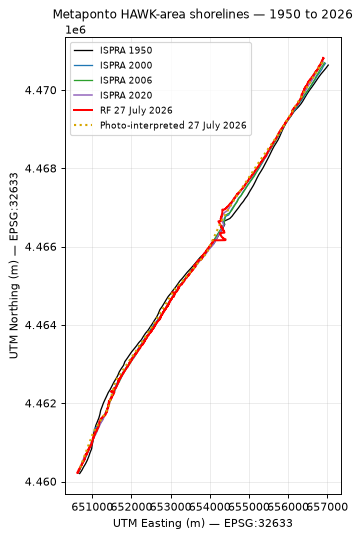

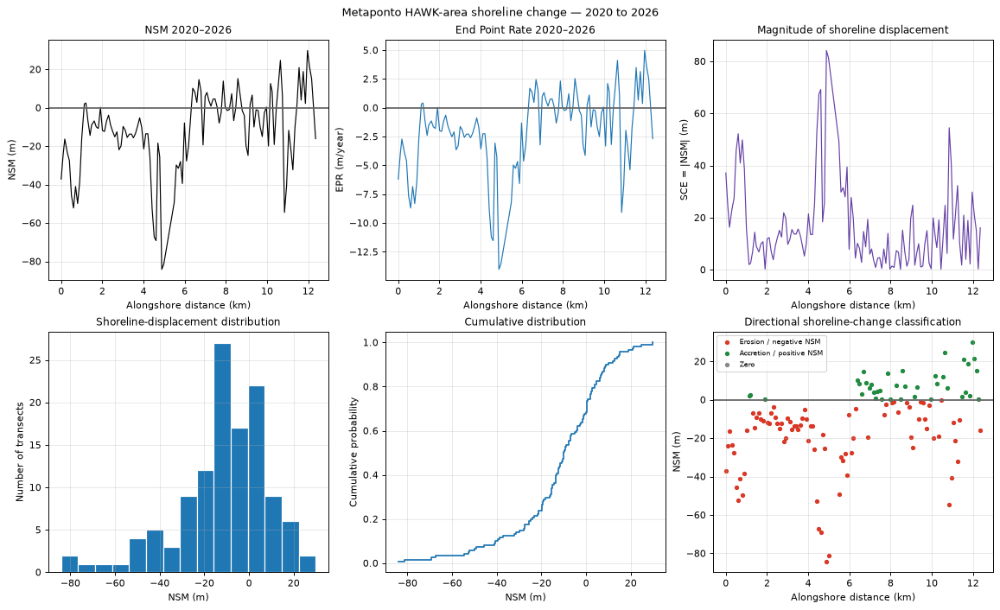

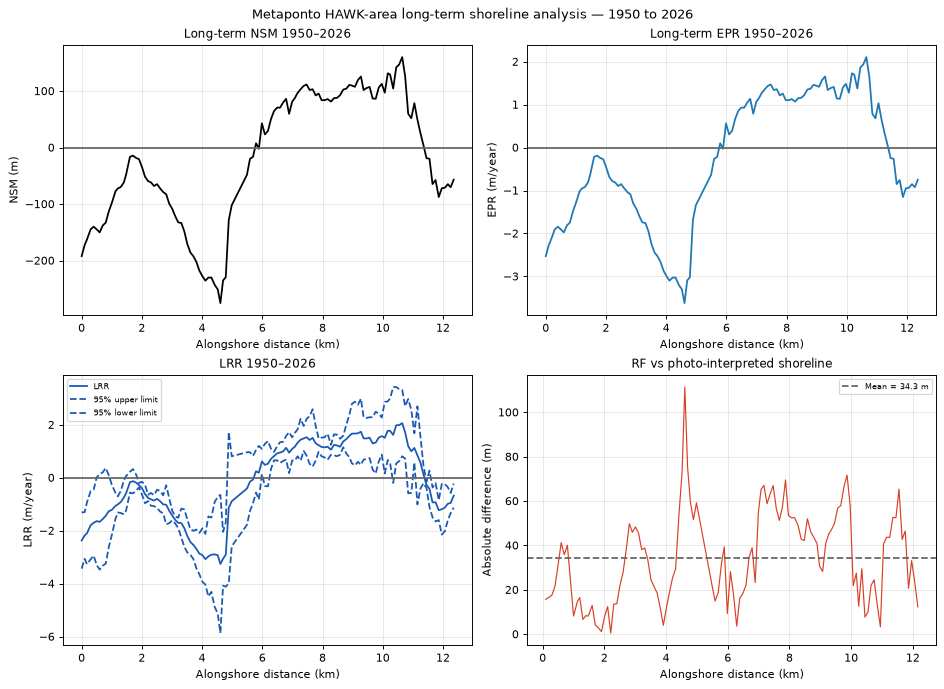

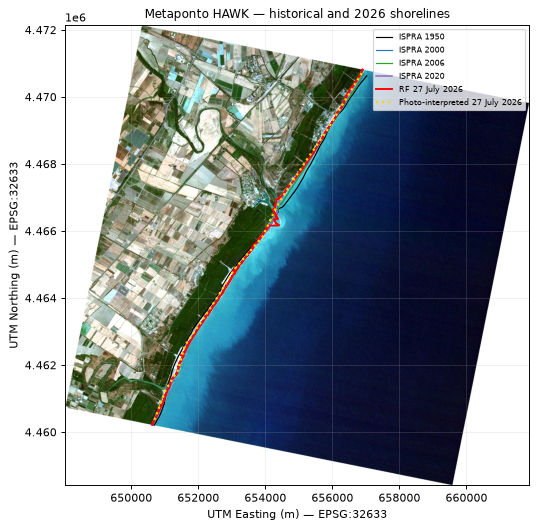


FINAL COMMON-TRANSECT RESULTS

HAWK-area common ISPRA/RF transects: 121
Common transects with manual 2026 reference: 118

2020–2026 RF NSM:
  Mean:   -11.82 m
  Median: -9.94 m
  P05:    -52.20 m
  P95:    15.19 m

2020–2026 RF EPR:
  Mean:   -1.969 m/year
  Median: -1.656 m/year

1950–2026 RF-based long-term LRR:
  Mean:   -0.172 m/year
  Median: -0.168 m/year

RF 2026 vs photo-interpreted 2026 (common-transect comparison):
  Mean absolute difference:   34.26 m
  Median absolute difference: 32.24 m
  95th percentile:            67.01 m
  Maximum:                    111.41 m

Percentage of common transects within tolerance:
  <= 10 m : 11.9%
  <= 25 m : 41.5%
  <= 50 m : 74.6%
  <= 75 m : 98.3%

Approximate 2020–2026 integrated areas:
  Positive/accretion area: 30,576 m²
  Negative/erosion area: 196,655 m²
  Net area: -166,079 m²

FILES SAVED
C:\Users\faiza\Downloads\Risultati_linee_riva\Comparison_with_27July2026\CommonTransect_1950_2026\Figure10A_Common_HAWK_shorelines_1950_2026.png

In [8]:
# ============================================================
# METAPONTO — FINAL CODE 10
#
# COMMON-TRANSECT HISTORICAL COMPARISON
#
# ISPRA: 1950, 2000, 2006, 2020
# HAWK RF shoreline: 27 July 2026
# HAWK photo-interpreted reference: 27 July 2026
#
# PURPOSE
# ------------------------------------------------------------
# 1. Reconstruct the existing ISPRA transect direction.
# 2. Intersect the 2026 RF shoreline with the SAME transects.
# 3. Intersect the manual/photo-interpreted 2026 line too.
# 4. Keep only transects falling in the HAWK coastline area.
# 5. Calculate:
#       - 2020–2026 NSM
#       - 2020–2026 EPR
#       - 2020–2026 SCE
#       - 1950–2026 long-term NSM/EPR
#       - 1950–2026 LRR + 95% CI
#       - RF vs manual difference on common transects
#       - percentages within 10 / 25 / 50 / 75 m
# 6. Produce final paper figures and Excel tables.
#
# IMPORTANT
# ------------------------------------------------------------
# - Professor's original historical calculations are NOT changed.
# - SIGN_FACTOR remains +1.
# - WLR is NOT extended to 2026 because no documented
#   2026 uncertainty has been supplied.
# ============================================================

from pathlib import Path
import warnings
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from scipy.stats import t as student_t


# ============================================================
# 1. CONFIGURATION
# ============================================================

DOWNLOADS = Path.home() / "Downloads"

HISTORICAL_FILES = [
    DOWNLOADS / "TRANS_17_intersect_1950_2000.xlsx",
    DOWNLOADS / "TRANS_17_intersect_2000_2006.xlsx",
    DOWNLOADS / "TRANS_17_intersect_2006_2020.xlsx",
]

RF_CSV = (
    DOWNLOADS
    / "Metaponto_Coastline_Project"
    / "HAWK_2026_RF"
    / "RF_principal_coastline_20260727_EPSG32633.csv"
)

MANUAL_CSV = (
    DOWNLOADS
    / "Metaponto_Coastline_Project"
    / "HAWK_2026_RF"
    / "PhotoInterpreted_shoreline_20260727_EPSG32633.csv"
)

HAWK_DIR = (
    DOWNLOADS
    / "HAWK DATASET 27.7.26 METAPONTO"
)

FINAL_DIR = (
    DOWNLOADS
    / "Risultati_linee_riva"
    / "Comparison_with_27July2026"
    / "CommonTransect_1950_2026"
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SIGN_FACTOR = +1

HISTORICAL_YEARS = [
    1950,
    2000,
    2006,
    2020
]

ALL_RF_YEARS = [
    1950,
    2000,
    2006,
    2020,
    2026
]

# Do NOT bridge known RF gaps.
MAX_RF_SEGMENT_M = 25.0

# Reject geometrically implausible intersections that occur
# very far from the historical 2020 shoreline point.
MAX_DISTANCE_FROM_2020_M = 1000.0

# Transect reconstruction QC.
MIN_DISTANCE_RANGE_M = 0.25
MAX_TRANSECT_SCALE_ERROR = 0.50
MAX_HISTORICAL_LINE_RESIDUAL_M = 20.0


print("=" * 78)
print("CODE 10 — COMMON-TRANSECT ISPRA + HAWK 2026 ANALYSIS")
print("=" * 78)

print("\nSIGN_FACTOR:", SIGN_FACTOR)
print(
    "Interpret positive/negative shoreline movement only after "
    "confirming the professor's baseline orientation."
)

print(
    "\n2026 WLR/significance thresholds will NOT be calculated "
    "because no documented 2026 positional uncertainty is available."
)


# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def cumulative_distance(x, y):

    x = np.asarray(x, float)
    y = np.asarray(y, float)

    return np.r_[
        0.0,
        np.cumsum(
            np.hypot(
                np.diff(x),
                np.diff(y)
            )
        )
    ]


def cross2(a, b):
    """
    2-D cross product.
    """

    return (
        a[..., 0] * b[..., 1]
        -
        a[..., 1] * b[..., 0]
    )


def prepare_polyline_segments(
    x,
    y,
    maximum_length=None
):
    """
    Convert a polyline to line segments.

    For the RF shoreline, long segments are removed so that
    known RF gaps are not artificially bridged.
    """

    p = np.column_stack([
        np.asarray(x, float),
        np.asarray(y, float)
    ])

    q0 = p[:-1]
    q1 = p[1:]

    s = q1 - q0

    lengths = np.linalg.norm(
        s,
        axis=1
    )

    valid = (
        np.isfinite(q0).all(axis=1)
        &
        np.isfinite(q1).all(axis=1)
        &
        (lengths > 0)
    )

    if maximum_length is not None:

        valid &= (
            lengths <= maximum_length
        )

    return (
        q0[valid],
        s[valid],
        lengths[valid]
    )


def intersect_infinite_transect_with_polyline(
    anchor,
    direction,
    segment_starts,
    segment_vectors,
    reference_point=None,
    maximum_reference_distance=None
):
    """
    Intersect an infinite transect with a shoreline polyline.

    If multiple intersections exist, select the intersection
    nearest to the historical 2020 shoreline point.
    """

    anchor = np.asarray(
        anchor,
        float
    )

    direction = np.asarray(
        direction,
        float
    )

    den = cross2(
        np.broadcast_to(
            direction,
            segment_vectors.shape
        ),
        segment_vectors
    )

    non_parallel = (
        np.abs(den) > 1e-12
    )

    if not np.any(non_parallel):
        return None

    q0 = segment_starts[
        non_parallel
    ]

    seg = segment_vectors[
        non_parallel
    ]

    den = den[
        non_parallel
    ]

    w = (
        q0
        -
        anchor
    )

    # Segment parameter.
    u_segment = (
        cross2(
            w,
            np.broadcast_to(
                direction,
                w.shape
            )
        )
        /
        den
    )

    valid = (
        (u_segment >= -1e-10)
        &
        (u_segment <= 1 + 1e-10)
    )

    if not np.any(valid):
        return None

    intersections = (
        q0[valid]
        +
        u_segment[valid, None]
        *
        seg[valid]
    )

    if reference_point is None:

        return intersections[0]

    reference_point = np.asarray(
        reference_point,
        float
    )

    distances = np.linalg.norm(
        intersections
        -
        reference_point,
        axis=1
    )

    best = int(
        np.argmin(
            distances
        )
    )

    if (
        maximum_reference_distance is not None
        and
        distances[best] > maximum_reference_distance
    ):

        return None

    return intersections[best]


def professor_style_rates(
    years,
    distances
):
    """
    Same unweighted linear-regression structure used in the
    professor's original rates() function.

    Returns:
      slope, standard error, 95% CI half-width, R²
    """

    t = np.asarray(
        years,
        float
    )

    D = np.asarray(
        distances,
        float
    )

    w = np.ones(
        len(t)
    )

    mt = np.dot(
        w,
        t
    ) / w.sum()

    xx = (
        t
        -
        mt
    )

    den = np.dot(
        w,
        xx**2
    )

    mu = (
        D @ w
        /
        w.sum()
    )

    slope = (
        D
        @
        (
            w * xx
        )
        /
        den
    )

    residual = (
        D
        -
        (
            mu[:, None]
            +
            slope[:, None]
            *
            xx[None, :]
        )
    )

    sse = (
        residual**2
    ) @ w

    sst = (
        (
            D
            -
            mu[:, None]
        )**2
    ) @ w

    df = (
        len(t)
        -
        2
    )

    if df > 0:

        se = np.sqrt(
            np.maximum(
                (sse / df)
                /
                den,
                0
            )
        )

        ci = (
            student_t.ppf(
                0.975,
                df
            )
            *
            se
        )

    else:

        se = np.full(
            len(D),
            np.nan
        )

        ci = se.copy()

    r2 = np.divide(
        sse,
        sst,
        out=np.full(
            len(D),
            np.nan
        ),
        where=sst > 0
    )

    r2 = np.where(
        sst > 0,
        1 - r2,
        np.nan
    )

    return (
        slope,
        se,
        ci,
        r2
    )


def basic_stats(values):

    x = np.asarray(
        values,
        float
    )

    x = x[
        np.isfinite(x)
    ]

    if len(x) == 0:

        return {
            "N": 0,
            "Mean": np.nan,
            "Median": np.nan,
            "Std": np.nan,
            "Min": np.nan,
            "Max": np.nan,
            "P05": np.nan,
            "P25": np.nan,
            "P75": np.nan,
            "P95": np.nan,
            "RMS": np.nan,
        }

    return {
        "N": len(x),
        "Mean": np.mean(x),
        "Median": np.median(x),
        "Std": np.std(
            x,
            ddof=1
        )
        if len(x) > 1
        else np.nan,
        "Min": np.min(x),
        "Max": np.max(x),
        "P05": np.percentile(x, 5),
        "P25": np.percentile(x, 25),
        "P75": np.percentile(x, 75),
        "P95": np.percentile(x, 95),
        "RMS": np.sqrt(
            np.mean(
                x**2
            )
        ),
    }


# ============================================================
# 3. LOAD HISTORICAL ISPRA OBSERVATIONS
# ============================================================

historical_frames = []

for path in HISTORICAL_FILES:

    if not path.exists():

        raise FileNotFoundError(
            path
        )

    table = pd.read_excel(
        path
    )

    required = {
        "TransectId",
        "ShorelineId",
        "Distance",
        "IntersectX",
        "IntersectY",
    }

    missing = (
        required
        -
        set(
            table.columns
        )
    )

    if missing:

        raise ValueError(
            f"{path.name}: missing columns {missing}"
        )

    p = table[
        [
            "TransectId",
            "ShorelineId",
            "Distance",
            "IntersectX",
            "IntersectY",
        ]
    ].copy()

    p["Date"] = pd.to_datetime(
        p["ShorelineId"],
        dayfirst=True,
        errors="coerce"
    )

    p["Year"] = (
        p["Date"]
        .dt
        .year
    )

    p["TransectId"] = pd.to_numeric(
        p["TransectId"],
        errors="coerce"
    )

    p["Distance_m"] = pd.to_numeric(
        p["Distance"],
        errors="coerce"
    )

    p["X_m"] = pd.to_numeric(
        p["IntersectX"],
        errors="coerce"
    )

    p["Y_m"] = pd.to_numeric(
        p["IntersectY"],
        errors="coerce"
    )

    p = p[
        [
            "TransectId",
            "Year",
            "Distance_m",
            "X_m",
            "Y_m",
        ]
    ].dropna()

    p["SourceFile"] = (
        path.name
    )

    historical_frames.append(
        p
    )


historical_raw = pd.concat(
    historical_frames,
    ignore_index=True
)


# ------------------------------------------------------------
# Check repeated 2000 / 2006 observations.
# ------------------------------------------------------------

duplicate_spread = (
    historical_raw
    .groupby(
        [
            "TransectId",
            "Year"
        ]
    )
    .agg(
        XSpread_m=(
            "X_m",
            lambda z: (
                z.max()
                -
                z.min()
            )
        ),
        YSpread_m=(
            "Y_m",
            lambda z: (
                z.max()
                -
                z.min()
            )
        ),
        DSpread_m=(
            "Distance_m",
            lambda z: (
                z.max()
                -
                z.min()
            )
        )
    )
    .reset_index()
)


max_duplicate_spread = float(
    np.nanmax(
        duplicate_spread[
            [
                "XSpread_m",
                "YSpread_m",
                "DSpread_m"
            ]
        ].to_numpy()
    )
)


print(
    "\nMaximum repeated historical-coordinate/distance spread:",
    f"{max_duplicate_spread:.6f} m"
)


historical = (
    historical_raw
    .groupby(
        [
            "TransectId",
            "Year"
        ],
        as_index=False
    )
    [
        [
            "Distance_m",
            "X_m",
            "Y_m"
        ]
    ]
    .mean()
)


# Keep transects containing all four historical epochs.

year_count = (
    historical[
        historical.Year.isin(
            HISTORICAL_YEARS
        )
    ]
    .groupby(
        "TransectId"
    )
    .Year
    .nunique()
)


complete_ids = np.sort(
    year_count[
        year_count
        ==
        len(
            HISTORICAL_YEARS
        )
    ]
    .index
    .to_numpy()
)


historical = historical[
    historical.TransectId.isin(
        complete_ids
    )
].copy()


print(
    "Historical common transects:",
    len(
        complete_ids
    )
)


# ============================================================
# 4. LOAD RF AND MANUAL 2026 SHORELINES
# ============================================================

if not RF_CSV.exists():

    raise FileNotFoundError(
        RF_CSV
    )

if not MANUAL_CSV.exists():

    raise FileNotFoundError(
        MANUAL_CSV
    )


rf = pd.read_csv(
    RF_CSV
)

manual = pd.read_csv(
    MANUAL_CSV
)


rf_x = pd.to_numeric(
    rf["easting_m"],
    errors="coerce"
).to_numpy()

rf_y = pd.to_numeric(
    rf["northing_m"],
    errors="coerce"
).to_numpy()


manual_x = pd.to_numeric(
    manual["easting_m"],
    errors="coerce"
).to_numpy()

manual_y = pd.to_numeric(
    manual["northing_m"],
    errors="coerce"
).to_numpy()


rf_valid = (
    np.isfinite(rf_x)
    &
    np.isfinite(rf_y)
)

manual_valid = (
    np.isfinite(manual_x)
    &
    np.isfinite(manual_y)
)


rf_x = rf_x[
    rf_valid
]

rf_y = rf_y[
    rf_valid
]

manual_x = manual_x[
    manual_valid
]

manual_y = manual_y[
    manual_valid
]


print(
    "\nRF shoreline points:",
    f"{len(rf_x):,}"
)

print(
    "Manual/photo-interpreted vertices:",
    f"{len(manual_x):,}"
)


# RF polyline:
# discard segments longer than 25 m so a known gap
# cannot become a false straight shoreline.

rf_q0, rf_seg, rf_seg_length = (
    prepare_polyline_segments(
        rf_x,
        rf_y,
        maximum_length=MAX_RF_SEGMENT_M
    )
)


manual_q0, manual_seg, manual_seg_length = (
    prepare_polyline_segments(
        manual_x,
        manual_y,
        maximum_length=None
    )
)


print(
    "Usable RF segments:",
    f"{len(rf_q0):,}"
)

print(
    "RF segments removed as gaps > "
    f"{MAX_RF_SEGMENT_M:.0f} m:",
    f"{len(rf_x)-1-len(rf_q0):,}"
)


# ============================================================
# 5. RECONSTRUCT EACH ISPRA TRANSECT
#
# The historical data give:
#
# X = a_x * Distance + b_x
# Y = a_y * Distance + b_y
#
# Therefore the existing professor Distance coordinate can
# be recovered for a new 2026 shoreline intersection.
# ============================================================

results = []

failed_geometry = 0
failed_rf_intersection = 0


for transect_id in complete_ids:

    h = (
        historical[
            historical.TransectId
            ==
            transect_id
        ]
        .sort_values(
            "Year"
        )
        .copy()
    )

    if not all(
        year in set(
            h.Year
        )
        for year in HISTORICAL_YEARS
    ):

        continue


    D = np.asarray(
        [
            float(
                h.loc[
                    h.Year == year,
                    "Distance_m"
                ].iloc[0]
            )
            for year in HISTORICAL_YEARS
        ]
    )


    X = np.asarray(
        [
            float(
                h.loc[
                    h.Year == year,
                    "X_m"
                ].iloc[0]
            )
            for year in HISTORICAL_YEARS
        ]
    )


    Y = np.asarray(
        [
            float(
                h.loc[
                    h.Year == year,
                    "Y_m"
                ].iloc[0]
            )
            for year in HISTORICAL_YEARS
        ]
    )


    if np.ptp(
        D
    ) < MIN_DISTANCE_RANGE_M:

        failed_geometry += 1
        continue


    # --------------------------------------------------------
    # Fit existing transect geometry to professor Distance_m.
    # --------------------------------------------------------

    ax, bx = np.polyfit(
        D,
        X,
        1
    )

    ay, by = np.polyfit(
        D,
        Y,
        1
    )


    vector = np.array(
        [
            ax,
            ay
        ],
        dtype=float
    )


    vector_norm = float(
        np.linalg.norm(
            vector
        )
    )


    if (
        vector_norm < (
            1
            -
            MAX_TRANSECT_SCALE_ERROR
        )
        or
        vector_norm > (
            1
            +
            MAX_TRANSECT_SCALE_ERROR
        )
    ):

        failed_geometry += 1
        continue


    baseline_point = np.array(
        [
            bx,
            by
        ],
        dtype=float
    )


    predicted_hist_xy = (
        baseline_point[None, :]
        +
        D[:, None]
        *
        vector[None, :]
    )


    historical_residual = np.linalg.norm(
        predicted_hist_xy
        -
        np.column_stack(
            [
                X,
                Y
            ]
        ),
        axis=1
    )


    max_residual = float(
        np.max(
            historical_residual
        )
    )


    if (
        max_residual
        >
        MAX_HISTORICAL_LINE_RESIDUAL_M
    ):

        failed_geometry += 1
        continue


    direction = (
        vector
        /
        vector_norm
    )


    # 2020 reference point used to select the correct
    # intersection if a polyline crosses the infinite
    # transect more than once.

    index_2020 = HISTORICAL_YEARS.index(
        2020
    )

    point_2020 = np.array(
        [
            X[index_2020],
            Y[index_2020]
        ],
        float
    )


    # --------------------------------------------------------
    # Intersect RF 2026.
    # --------------------------------------------------------

    point_rf = (
        intersect_infinite_transect_with_polyline(
            anchor=point_2020,
            direction=direction,
            segment_starts=rf_q0,
            segment_vectors=rf_seg,
            reference_point=point_2020,
            maximum_reference_distance=(
                MAX_DISTANCE_FROM_2020_M
            )
        )
    )


    if point_rf is None:

        failed_rf_intersection += 1
        continue


    # Recover the professor's Distance_m coordinate:
    #
    # P = baseline_point + D * vector
    #
    # => D = dot(P-baseline, vector) / dot(vector,vector)

    distance_rf_2026 = float(
        np.dot(
            point_rf
            -
            baseline_point,
            vector
        )
        /
        np.dot(
            vector,
            vector
        )
    )


    # --------------------------------------------------------
    # Intersect manual/photo-interpreted reference.
    # --------------------------------------------------------

    point_manual = (
        intersect_infinite_transect_with_polyline(
            anchor=point_2020,
            direction=direction,
            segment_starts=manual_q0,
            segment_vectors=manual_seg,
            reference_point=point_2020,
            maximum_reference_distance=(
                MAX_DISTANCE_FROM_2020_M
            )
        )
    )


    if point_manual is not None:

        distance_manual_2026 = float(
            np.dot(
                point_manual
                -
                baseline_point,
                vector
            )
            /
            np.dot(
                vector,
                vector
            )
        )

        manual_e = float(
            point_manual[0]
        )

        manual_n = float(
            point_manual[1]
        )

    else:

        distance_manual_2026 = np.nan
        manual_e = np.nan
        manual_n = np.nan


    row = {
        "TransectId": transect_id,

        "TransectScale_XY_per_m":
            vector_norm,

        "HistoricalTransectFitMaxResidual_m":
            max_residual,

        "X_RF_2026_m":
            float(
                point_rf[0]
            ),

        "Y_RF_2026_m":
            float(
                point_rf[1]
            ),

        "Distance_RF_2026_m":
            distance_rf_2026,

        "X_Manual_2026_m":
            manual_e,

        "Y_Manual_2026_m":
            manual_n,

        "Distance_Manual_2026_m":
            distance_manual_2026,
    }


    for year, d, x, y in zip(
        HISTORICAL_YEARS,
        D,
        X,
        Y
    ):

        row[
            f"Distance_{year}_m"
        ] = d

        row[
            f"X_{year}_m"
        ] = x

        row[
            f"Y_{year}_m"
        ] = y


    results.append(
        row
    )


common = pd.DataFrame(
    results
)


if len(common) == 0:

    raise RuntimeError(
        "No valid common HAWK/ISPRA transects were produced."
    )


common = (
    common
    .sort_values(
        "TransectId"
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 78)
print("COMMON HAWK TRANSECTS")
print("=" * 78)

print(
    "Historical transects considered:",
    len(
        complete_ids
    )
)

print(
    "Rejected by transect-geometry QC:",
    failed_geometry
)

print(
    "No valid RF intersection:",
    failed_rf_intersection
)

print(
    "Common HAWK/ISPRA transects retained:",
    len(common)
)

print(
    "Transects also intersecting manual reference:",
    common.Distance_Manual_2026_m.notna().sum()
)


# ============================================================
# 6. ALONGSHORE DISTANCE
#
# Same concept as professor code:
# cumulative distance between mean shoreline positions.
# ============================================================

mid_x = (
    common.X_2020_m.to_numpy()
    +
    common.X_RF_2026_m.to_numpy()
) / 2

mid_y = (
    common.Y_2020_m.to_numpy()
    +
    common.Y_RF_2026_m.to_numpy()
) / 2


common[
    "Alongshore_m"
] = cumulative_distance(
    mid_x,
    mid_y
)


alongshore = (
    common.Alongshore_m.to_numpy()
)


alongshore_km = (
    alongshore
    /
    1000
)


# ============================================================
# 7. 2020–2026 RF SHORELINE CHANGE
# ============================================================

delta_t = 6.0


common[
    "NSM_2020_2026_RF_m"
] = (
    SIGN_FACTOR
    *
    (
        common.Distance_RF_2026_m
        -
        common.Distance_2020_m
    )
)


common[
    "EPR_2020_2026_RF_m_per_year"
] = (
    common.NSM_2020_2026_RF_m
    /
    delta_t
)


common[
    "SCE_2020_2026_RF_m"
] = np.abs(
    common.NSM_2020_2026_RF_m
)


# Manual alternative where available.

common[
    "NSM_2020_2026_Manual_m"
] = (
    SIGN_FACTOR
    *
    (
        common.Distance_Manual_2026_m
        -
        common.Distance_2020_m
    )
)


common[
    "EPR_2020_2026_Manual_m_per_year"
] = (
    common.NSM_2020_2026_Manual_m
    /
    delta_t
)


# ============================================================
# 8. RF vs MANUAL ON THE SAME TRANSECTS
# ============================================================

common[
    "RF_minus_Manual_signed_m"
] = (
    SIGN_FACTOR
    *
    (
        common.Distance_RF_2026_m
        -
        common.Distance_Manual_2026_m
    )
)


common[
    "RF_Manual_absolute_difference_m"
] = np.abs(
    common.RF_minus_Manual_signed_m
)


validation = common[
    common.Distance_Manual_2026_m.notna()
].copy()


absolute_validation = (
    validation
    .RF_Manual_absolute_difference_m
    .to_numpy()
)


# Percentage-style agreement requested by supervisor-type criterion.

threshold_rows = []

for threshold in [
    10,
    25,
    50,
    75
]:

    pct = (
        100
        *
        np.mean(
            absolute_validation
            <=
            threshold
        )
        if len(
            absolute_validation
        )
        else np.nan
    )

    threshold_rows.append({
        "Tolerance_m": threshold,
        "NumberWithinTolerance": int(
            np.sum(
                absolute_validation
                <=
                threshold
            )
        )
        if len(
            absolute_validation
        )
        else 0,
        "NumberCompared": len(
            absolute_validation
        ),
        "PercentageWithinTolerance":
            pct
    })


threshold_table = pd.DataFrame(
    threshold_rows
)


# ============================================================
# 9. LONG-TERM 1950–2026 USING RF AS 2026 EPOCH
# ============================================================

distance_matrix = np.column_stack([
    common.Distance_1950_m,
    common.Distance_2000_m,
    common.Distance_2006_m,
    common.Distance_2020_m,
    common.Distance_RF_2026_m,
])


nsm_long = (
    SIGN_FACTOR
    *
    (
        common.Distance_RF_2026_m.to_numpy()
        -
        common.Distance_1950_m.to_numpy()
    )
)


epr_long = (
    nsm_long
    /
    (
        2026
        -
        1950
    )
)


sce_long = (
    distance_matrix.max(
        axis=1
    )
    -
    distance_matrix.min(
        axis=1
    )
)


lrr, lrr_se, lrr_ci, lrr_r2 = (
    professor_style_rates(
        ALL_RF_YEARS,
        distance_matrix
    )
)


lrr = (
    SIGN_FACTOR
    *
    lrr
)


common[
    "NSM_1950_2026_RF_m"
] = nsm_long

common[
    "EPR_1950_2026_RF_m_per_year"
] = epr_long

common[
    "SCE_1950_2026_RF_m"
] = sce_long

common[
    "LRR_1950_2026_RF_m_per_year"
] = lrr

common[
    "LRR_CI95_1950_2026_RF_m_per_year"
] = lrr_ci

common[
    "LRR_SE_1950_2026_RF_m_per_year"
] = lrr_se

common[
    "LRR_R2_1950_2026_RF"
] = lrr_r2


# ============================================================
# 10. APPROXIMATE 2020–2026 AREA CHANGE
#
# Same integration idea used in the professor's area_row().
# ============================================================

nsm_20_26 = (
    common
    .NSM_2020_2026_RF_m
    .to_numpy()
)


if len(common) > 1:

    approximate_accretion_area = float(
        np.trapezoid(
            np.maximum(
                nsm_20_26,
                0
            ),
            alongshore
        )
    )

    approximate_erosion_area = float(
        np.trapezoid(
            np.maximum(
                -nsm_20_26,
                0
            ),
            alongshore
        )
    )

    approximate_net_area = float(
        np.trapezoid(
            nsm_20_26,
            alongshore
        )
    )

else:

    approximate_accretion_area = np.nan
    approximate_erosion_area = np.nan
    approximate_net_area = np.nan


# ============================================================
# 11. SUMMARY TABLES
# ============================================================

stats_2020_2026 = pd.DataFrame([
    {
        "Metric":
            "NSM 2020-2026 RF",
        **basic_stats(
            common.NSM_2020_2026_RF_m
        )
    },
    {
        "Metric":
            "EPR 2020-2026 RF",
        **basic_stats(
            common.EPR_2020_2026_RF_m_per_year
        )
    },
    {
        "Metric":
            "SCE 2020-2026 RF",
        **basic_stats(
            common.SCE_2020_2026_RF_m
        )
    }
])


stats_longterm = pd.DataFrame([
    {
        "Metric":
            "NSM 1950-2026 RF",
        **basic_stats(
            common.NSM_1950_2026_RF_m
        )
    },
    {
        "Metric":
            "EPR 1950-2026 RF",
        **basic_stats(
            common.EPR_1950_2026_RF_m_per_year
        )
    },
    {
        "Metric":
            "SCE 1950-2026 RF",
        **basic_stats(
            common.SCE_1950_2026_RF_m
        )
    },
    {
        "Metric":
            "LRR 1950-2026 RF",
        **basic_stats(
            common.LRR_1950_2026_RF_m_per_year
        )
    }
])


validation_stats = pd.DataFrame([
    {
        "Metric":
            "RF vs manual absolute difference",
        **basic_stats(
            absolute_validation
        )
    }
])


area_summary = pd.DataFrame([
    {
        "Period":
            "2020-2026",

        "ApproxAccretionArea_m2":
            approximate_accretion_area,

        "ApproxErosionArea_m2":
            approximate_erosion_area,

        "ApproxNetArea_m2":
            approximate_net_area,
    }
])


# ============================================================
# 12. FIGURE A — ALL SHORELINES IN THE COMMON HAWK AREA
# ============================================================

fig, ax = plt.subplots(
    figsize=(7.2, 6.4)
)


shoreline_specs = [
    (
        1950,
        "black",
        1.1
    ),
    (
        2000,
        "#1f77b4",
        1.1
    ),
    (
        2006,
        "#2ca02c",
        1.1
    ),
    (
        2020,
        "#9467bd",
        1.3
    ),
]


for year, colour, width_line in shoreline_specs:

    ax.plot(
        common[
            f"X_{year}_m"
        ],
        common[
            f"Y_{year}_m"
        ],
        color=colour,
        linewidth=width_line,
        label=f"ISPRA {year}"
    )


ax.plot(
    rf_x,
    rf_y,
    color="red",
    linewidth=1.7,
    label="RF 27 July 2026"
)


ax.plot(
    manual_x,
    manual_y,
    color="#d6a500",
    linewidth=1.8,
    linestyle=":",
    label="Photo-interpreted 27 July 2026"
)


ax.set_title(
    "Metaponto HAWK-area shorelines — 1950 to 2026"
)

ax.set_xlabel(
    "UTM Easting (m) — EPSG:32633"
)

ax.set_ylabel(
    "UTM Northing (m) — EPSG:32633"
)

ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.grid(
    True,
    alpha=0.25
)

ax.legend(
    fontsize=8
)

fig.tight_layout()


FIG_A = (
    FINAL_DIR
    /
    "Figure10A_Common_HAWK_shorelines_1950_2026.png"
)

fig.savefig(
    FIG_A,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. FIGURE B — PROFESSOR-STYLE 2020–2026 INDICATORS
#
# No MDC95/significance band because 2026 positional
# uncertainty is not documented.
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(13.5, 8.2),
    layout="constrained"
)


a = axes.flat


# ------------------------------------------------------------
# NSM
# ------------------------------------------------------------

a[0].plot(
    alongshore_km,
    common.NSM_2020_2026_RF_m,
    color="black",
    linewidth=1
)

a[0].axhline(
    0,
    color=".4"
)

a[0].set_title(
    "NSM 2020–2026"
)

a[0].set_xlabel(
    "Alongshore distance (km)"
)

a[0].set_ylabel(
    "NSM (m)"
)

a[0].grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# EPR
# ------------------------------------------------------------

a[1].plot(
    alongshore_km,
    common.EPR_2020_2026_RF_m_per_year,
    color="#1f77b4",
    linewidth=1
)

a[1].axhline(
    0,
    color=".4"
)

a[1].set_title(
    "End Point Rate 2020–2026"
)

a[1].set_xlabel(
    "Alongshore distance (km)"
)

a[1].set_ylabel(
    "EPR (m/year)"
)

a[1].grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# SCE
# ------------------------------------------------------------

a[2].plot(
    alongshore_km,
    common.SCE_2020_2026_RF_m,
    color="#6540a6",
    linewidth=1
)

a[2].set_title(
    "Magnitude of shoreline displacement"
)

a[2].set_xlabel(
    "Alongshore distance (km)"
)

a[2].set_ylabel(
    "SCE = |NSM| (m)"
)

a[2].grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

a[3].hist(
    common.NSM_2020_2026_RF_m,
    bins=15,
    edgecolor="white"
)

a[3].set_title(
    "Shoreline-displacement distribution"
)

a[3].set_xlabel(
    "NSM (m)"
)

a[3].set_ylabel(
    "Number of transects"
)

a[3].grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# Cumulative distribution
# ------------------------------------------------------------

sorted_nsm = np.sort(
    common.NSM_2020_2026_RF_m.to_numpy()
)


a[4].step(
    sorted_nsm,
    np.arange(
        1,
        len(
            sorted_nsm
        )
        +
        1
    )
    /
    len(
        sorted_nsm
    ),
    where="post"
)

a[4].set_title(
    "Cumulative distribution"
)

a[4].set_xlabel(
    "NSM (m)"
)

a[4].set_ylabel(
    "Cumulative probability"
)

a[4].grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# Directional classification
#
# No significance wording because no 2026 MDC95 is known.
# ------------------------------------------------------------

nsm = (
    common.NSM_2020_2026_RF_m.to_numpy()
)


negative = (
    nsm < 0
)

positive = (
    nsm > 0
)

zero = (
    nsm == 0
)


a[5].scatter(
    alongshore_km[
        negative
    ],
    nsm[
        negative
    ],
    s=12,
    color="#d93826",
    label="Erosion / negative NSM"
)

a[5].scatter(
    alongshore_km[
        positive
    ],
    nsm[
        positive
    ],
    s=12,
    color="#218b40",
    label="Accretion / positive NSM"
)

a[5].scatter(
    alongshore_km[
        zero
    ],
    nsm[
        zero
    ],
    s=12,
    color="#888888",
    label="Zero"
)

a[5].axhline(
    0,
    color=".4"
)

a[5].set_title(
    "Directional shoreline-change classification"
)

a[5].set_xlabel(
    "Alongshore distance (km)"
)

a[5].set_ylabel(
    "NSM (m)"
)

a[5].legend(
    fontsize=7
)

a[5].grid(
    True,
    alpha=0.3
)


fig.suptitle(
    "Metaponto HAWK-area shoreline change — 2020 to 2026"
)


FIG_B = (
    FINAL_DIR
    /
    "Figure10B_Indicators_2020_2026_RF.png"
)

fig.savefig(
    FIG_B,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. FIGURE C — LONG-TERM 1950–2026
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
    layout="constrained"
)


# ------------------------------------------------------------
# Long-term NSM
# ------------------------------------------------------------

axes[0, 0].plot(
    alongshore_km,
    common.NSM_1950_2026_RF_m,
    color="black"
)

axes[0, 0].axhline(
    0,
    color=".4"
)

axes[0, 0].set_title(
    "Long-term NSM 1950–2026"
)

axes[0, 0].set_xlabel(
    "Alongshore distance (km)"
)

axes[0, 0].set_ylabel(
    "NSM (m)"
)

axes[0, 0].grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# Long-term EPR
# ------------------------------------------------------------

axes[0, 1].plot(
    alongshore_km,
    common.EPR_1950_2026_RF_m_per_year,
    color="#1f77b4"
)

axes[0, 1].axhline(
    0,
    color=".4"
)

axes[0, 1].set_title(
    "Long-term EPR 1950–2026"
)

axes[0, 1].set_xlabel(
    "Alongshore distance (km)"
)

axes[0, 1].set_ylabel(
    "EPR (m/year)"
)

axes[0, 1].grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# LRR + 95% CI
# ------------------------------------------------------------

lrr_values = (
    common.LRR_1950_2026_RF_m_per_year.to_numpy()
)

lrr_ci_values = (
    common.LRR_CI95_1950_2026_RF_m_per_year.to_numpy()
)


axes[1, 0].plot(
    alongshore_km,
    lrr_values,
    color="#1959b3",
    label="LRR"
)

axes[1, 0].plot(
    alongshore_km,
    lrr_values
    +
    lrr_ci_values,
    "--",
    color="#1959b3",
    label="95% upper limit"
)

axes[1, 0].plot(
    alongshore_km,
    lrr_values
    -
    lrr_ci_values,
    "--",
    color="#1959b3",
    label="95% lower limit"
)

axes[1, 0].axhline(
    0,
    color=".4"
)

axes[1, 0].set_title(
    "LRR 1950–2026"
)

axes[1, 0].set_xlabel(
    "Alongshore distance (km)"
)

axes[1, 0].set_ylabel(
    "LRR (m/year)"
)

axes[1, 0].legend(
    fontsize=7
)

axes[1, 0].grid(
    True,
    alpha=0.3
)


# ------------------------------------------------------------
# RF vs manual validation on common transects
# ------------------------------------------------------------

if len(
    validation
):

    manual_alongshore = (
        validation.Alongshore_m.to_numpy()
        /
        1000
    )

    axes[1, 1].plot(
        manual_alongshore,
        validation.RF_Manual_absolute_difference_m,
        color="#d94026",
        linewidth=1
    )

    axes[1, 1].axhline(
        validation.RF_Manual_absolute_difference_m.mean(),
        linestyle="--",
        color=".4",
        label=(
            "Mean = "
            f"{validation.RF_Manual_absolute_difference_m.mean():.1f} m"
        )
    )

    axes[1, 1].legend(
        fontsize=7
    )


axes[1, 1].set_title(
    "RF vs photo-interpreted shoreline"
)

axes[1, 1].set_xlabel(
    "Alongshore distance (km)"
)

axes[1, 1].set_ylabel(
    "Absolute difference (m)"
)

axes[1, 1].grid(
    True,
    alpha=0.3
)


fig.suptitle(
    "Metaponto HAWK-area long-term shoreline analysis — 1950 to 2026"
)


FIG_C = (
    FINAL_DIR
    /
    "Figure10C_LongTerm_1950_2026_RF.png"
)

fig.savefig(
    FIG_C,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. FIGURE D — HAWK IMAGE + HISTORICAL / 2026 LINES
# ============================================================

rgb_arrays = {}

for band in [
    "B01",
    "B02",
    "B03"
]:

    files = list(
        HAWK_DIR.glob(
            f"*.{band}.tif"
        )
    )

    if len(files) != 1:

        raise RuntimeError(
            f"Expected one {band} HAWK file; "
            f"found {len(files)}"
        )

    with Image.open(
        files[0]
    ) as img:

        rgb_arrays[
            band
        ] = np.asarray(
            img
        )[::4, ::4].copy()


rgb = np.stack(
    [
        rgb_arrays["B03"],
        rgb_arrays["B02"],
        rgb_arrays["B01"]
    ],
    axis=-1
).astype(
    np.float32
)


rgb_display = np.zeros_like(
    rgb,
    dtype=np.float32
)


for channel in range(3):

    data = rgb[
        :,
        :,
        channel
    ]

    positive_pixels = data[
        data > 0
    ]

    low, high = np.percentile(
        positive_pixels,
        [
            2,
            98
        ]
    )

    rgb_display[
        :,
        :,
        channel
    ] = np.clip(
        (
            data
            -
            low
        )
        /
        max(
            high
            -
            low,
            1
        ),
        0,
        1
    )


rgb_display[
    np.all(
        rgb == 0,
        axis=2
    )
] = 1


left = 648023.75
top = 4472148.75

width = 5541
height = 5493
pixel_size = 2.5

right = (
    left
    +
    width
    *
    pixel_size
)

bottom = (
    top
    -
    height
    *
    pixel_size
)


fig, ax = plt.subplots(
    figsize=(7.2, 6.3)
)


ax.imshow(
    rgb_display,
    extent=[
        left,
        right,
        bottom,
        top
    ],
    origin="upper"
)


ax.plot(
    common.X_1950_m,
    common.Y_1950_m,
    color="black",
    linewidth=1,
    label="ISPRA 1950"
)

ax.plot(
    common.X_2000_m,
    common.Y_2000_m,
    color="#1f77b4",
    linewidth=1,
    label="ISPRA 2000"
)

ax.plot(
    common.X_2006_m,
    common.Y_2006_m,
    color="#2ca02c",
    linewidth=1,
    label="ISPRA 2006"
)

ax.plot(
    common.X_2020_m,
    common.Y_2020_m,
    color="#9467bd",
    linewidth=1.3,
    label="ISPRA 2020"
)

ax.plot(
    rf_x,
    rf_y,
    color="red",
    linewidth=1.6,
    label="RF 27 July 2026"
)

ax.plot(
    manual_x,
    manual_y,
    color="#ffd400",
    linestyle=":",
    linewidth=1.9,
    label="Photo-interpreted 27 July 2026"
)


ax.set_title(
    "Metaponto HAWK — historical and 2026 shorelines"
)

ax.set_xlabel(
    "UTM Easting (m) — EPSG:32633"
)

ax.set_ylabel(
    "UTM Northing (m) — EPSG:32633"
)

ax.set_xlim(
    left,
    right
)

ax.set_ylim(
    bottom,
    top
)

ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.legend(
    fontsize=7
)

ax.grid(
    True,
    alpha=0.2
)

fig.tight_layout()


FIG_D = (
    FINAL_DIR
    /
    "Figure10D_HAWK_Historical_RF_Manual_1950_2026.png"
)

fig.savefig(
    FIG_D,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. SAVE FINAL EXCEL WORKBOOK
# ============================================================

notes = pd.DataFrame({
    "Item": [
        "2026 dataset",
        "2026 RF shoreline",
        "2026 validation reference",
        "Historical years",
        "Historical method",
        "2026 WLR",
        "2026 significance classification",
        "RF gap handling",
        "SIGN_FACTOR note",
    ],

    "Description": [
        "HAWK, 27 July 2026",
        "Random Forest principal coastline",
        "Independent manually photo-interpreted shoreline",
        "1950, 2000, 2006, 2020 ISPRA",
        (
            "2026 intersections were projected onto the existing "
            "ISPRA transect Distance_m coordinate system reconstructed "
            "from historical X/Y and Distance observations."
        ),
        (
            "Not calculated because no documented 2026 positional "
            "uncertainty was supplied."
        ),
        (
            "Only directional positive/negative NSM is reported; "
            "no MDC95 significance class is assigned for 2020-2026."
        ),
        (
            f"RF shoreline segments longer than "
            f"{MAX_RF_SEGMENT_M:.0f} m were not used for intersection."
        ),
        (
            "SIGN_FACTOR=+1 retained from professor code. "
            "Baseline orientation must be confirmed before interpreting "
            "positive as accretion and negative as erosion."
        ),
    ]
})


EXCEL_PATH = (
    FINAL_DIR
    /
    "Metaponto_CommonTransects_1950_2026_Final.xlsx"
)


with pd.ExcelWriter(
    EXCEL_PATH,
    engine="openpyxl"
) as writer:

    common.to_excel(
        writer,
        sheet_name="CommonTransects",
        index=False
    )

    stats_2020_2026.to_excel(
        writer,
        sheet_name="Stats_2020_2026",
        index=False
    )

    stats_longterm.to_excel(
        writer,
        sheet_name="Stats_1950_2026",
        index=False
    )

    validation_stats.to_excel(
        writer,
        sheet_name="RF_Manual_Validation",
        index=False
    )

    threshold_table.to_excel(
        writer,
        sheet_name="ValidationThresholds",
        index=False
    )

    area_summary.to_excel(
        writer,
        sheet_name="Area_2020_2026",
        index=False
    )

    notes.to_excel(
        writer,
        sheet_name="MethodNotes",
        index=False
    )


# Save CSV too.

COMMON_CSV = (
    FINAL_DIR
    /
    "CommonTransects_1950_2026.csv"
)

common.to_csv(
    COMMON_CSV,
    index=False
)


# ============================================================
# 17. FINAL PRINTED SUMMARY
# ============================================================

print("\n" + "=" * 78)
print("FINAL COMMON-TRANSECT RESULTS")
print("=" * 78)


print(
    "\nHAWK-area common ISPRA/RF transects:",
    len(common)
)


print(
    "Common transects with manual 2026 reference:",
    len(validation)
)


print("\n2020–2026 RF NSM:")

nsm_stats = basic_stats(
    common.NSM_2020_2026_RF_m
)

print(
    f"  Mean:   {nsm_stats['Mean']:.2f} m"
)

print(
    f"  Median: {nsm_stats['Median']:.2f} m"
)

print(
    f"  P05:    {nsm_stats['P05']:.2f} m"
)

print(
    f"  P95:    {nsm_stats['P95']:.2f} m"
)


print("\n2020–2026 RF EPR:")

epr_stats = basic_stats(
    common.EPR_2020_2026_RF_m_per_year
)

print(
    f"  Mean:   {epr_stats['Mean']:.3f} m/year"
)

print(
    f"  Median: {epr_stats['Median']:.3f} m/year"
)


print("\n1950–2026 RF-based long-term LRR:")

lrr_stats = basic_stats(
    common.LRR_1950_2026_RF_m_per_year
)

print(
    f"  Mean:   {lrr_stats['Mean']:.3f} m/year"
)

print(
    f"  Median: {lrr_stats['Median']:.3f} m/year"
)


if len(validation):

    vstats = basic_stats(
        absolute_validation
    )

    print(
        "\nRF 2026 vs photo-interpreted 2026 "
        "(common-transect comparison):"
    )

    print(
        f"  Mean absolute difference:   "
        f"{vstats['Mean']:.2f} m"
    )

    print(
        f"  Median absolute difference: "
        f"{vstats['Median']:.2f} m"
    )

    print(
        f"  95th percentile:            "
        f"{vstats['P95']:.2f} m"
    )

    print(
        f"  Maximum:                    "
        f"{vstats['Max']:.2f} m"
    )


    print(
        "\nPercentage of common transects within tolerance:"
    )

    for _, row in threshold_table.iterrows():

        print(
            f"  <= {int(row.Tolerance_m):2d} m : "
            f"{row.PercentageWithinTolerance:.1f}%"
        )


print("\nApproximate 2020–2026 integrated areas:")

print(
    "  Positive/accretion area:",
    f"{approximate_accretion_area:,.0f} m²"
)

print(
    "  Negative/erosion area:",
    f"{approximate_erosion_area:,.0f} m²"
)

print(
    "  Net area:",
    f"{approximate_net_area:,.0f} m²"
)


print("\n" + "=" * 78)
print("FILES SAVED")
print("=" * 78)

print(FIG_A)
print(FIG_B)
print(FIG_C)
print(FIG_D)
print(EXCEL_PATH)
print(COMMON_CSV)

print(
    "\nCODE 10 COMPLETE."
)

print(
    "Historical professor outputs remain unchanged; "
    "this is an additional HAWK-area 2026 extension."
)